In [1]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()

/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: []
Unexpected keys: []


Model(
  (latent_graph): LatentCompositeGraph(
    (q_proj): Linear(in_features=768, out_features=64, bias=True)
    (k_proj): Linear(in_features=768, out_features=64, bias=True)
  )
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_la

In [2]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [3]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





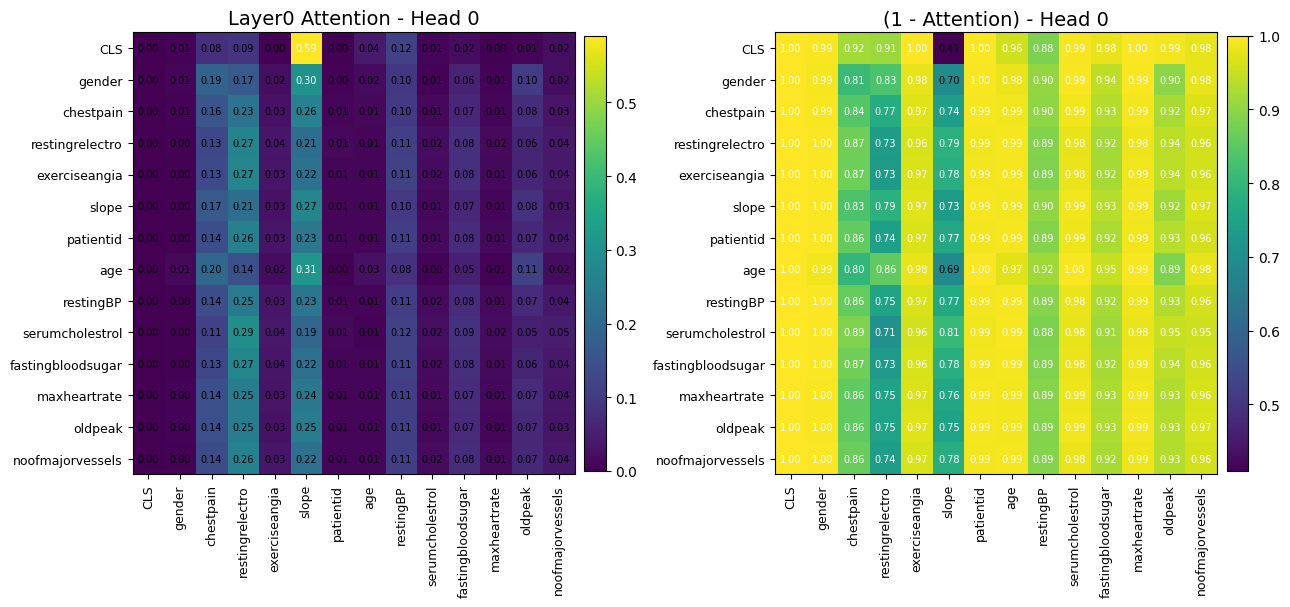

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0285 | std=0.2829
         gender  | mean=0.0140 | std=2.3778
      chestpain  | mean=0.2346 | std=5.5411
restingrelectro  | mean=0.2869 | std=6.4791
  exerciseangia  | mean=0.0254 | std=2.4438
          slope  | mean=0.2223 | std=5.6060
      patientid  | mean=0.2368 | std=6.9917
            age  | mean=-0.0833 | std=2.8170
      restingBP  | mean=0.2392 | std=6.2144
serumcholestrol  | mean=-0.1003 | std=1.4847
fastingbloodsugar  | mean=-0.2075 | std=3.8094
   maxheartrate  | mean=0.1686 | std=4.1450
        oldpeak  | mean=0.1404 | std=4.0140
noofmajorvessels  | mean=0.2141 | std=4.9220

=== Global embedding statistics ===
global mean: 0.0973
global std : 4.5183


In [5]:
src = sources[1]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)




========== Simulating LCG Initialization Strategies ==========
>> 1. Collecting CLS tokens from Vanilla GAT...
   >> Total CLS Collected: 3270
>> Simulating Strategy: [SEQUENTIAL]...
>> Simulating Strategy: [ROUND_ROBIN]...
>> Simulating Strategy: [HIERARCHICAL]...
>> Simulating Strategy: [DENSITY]...


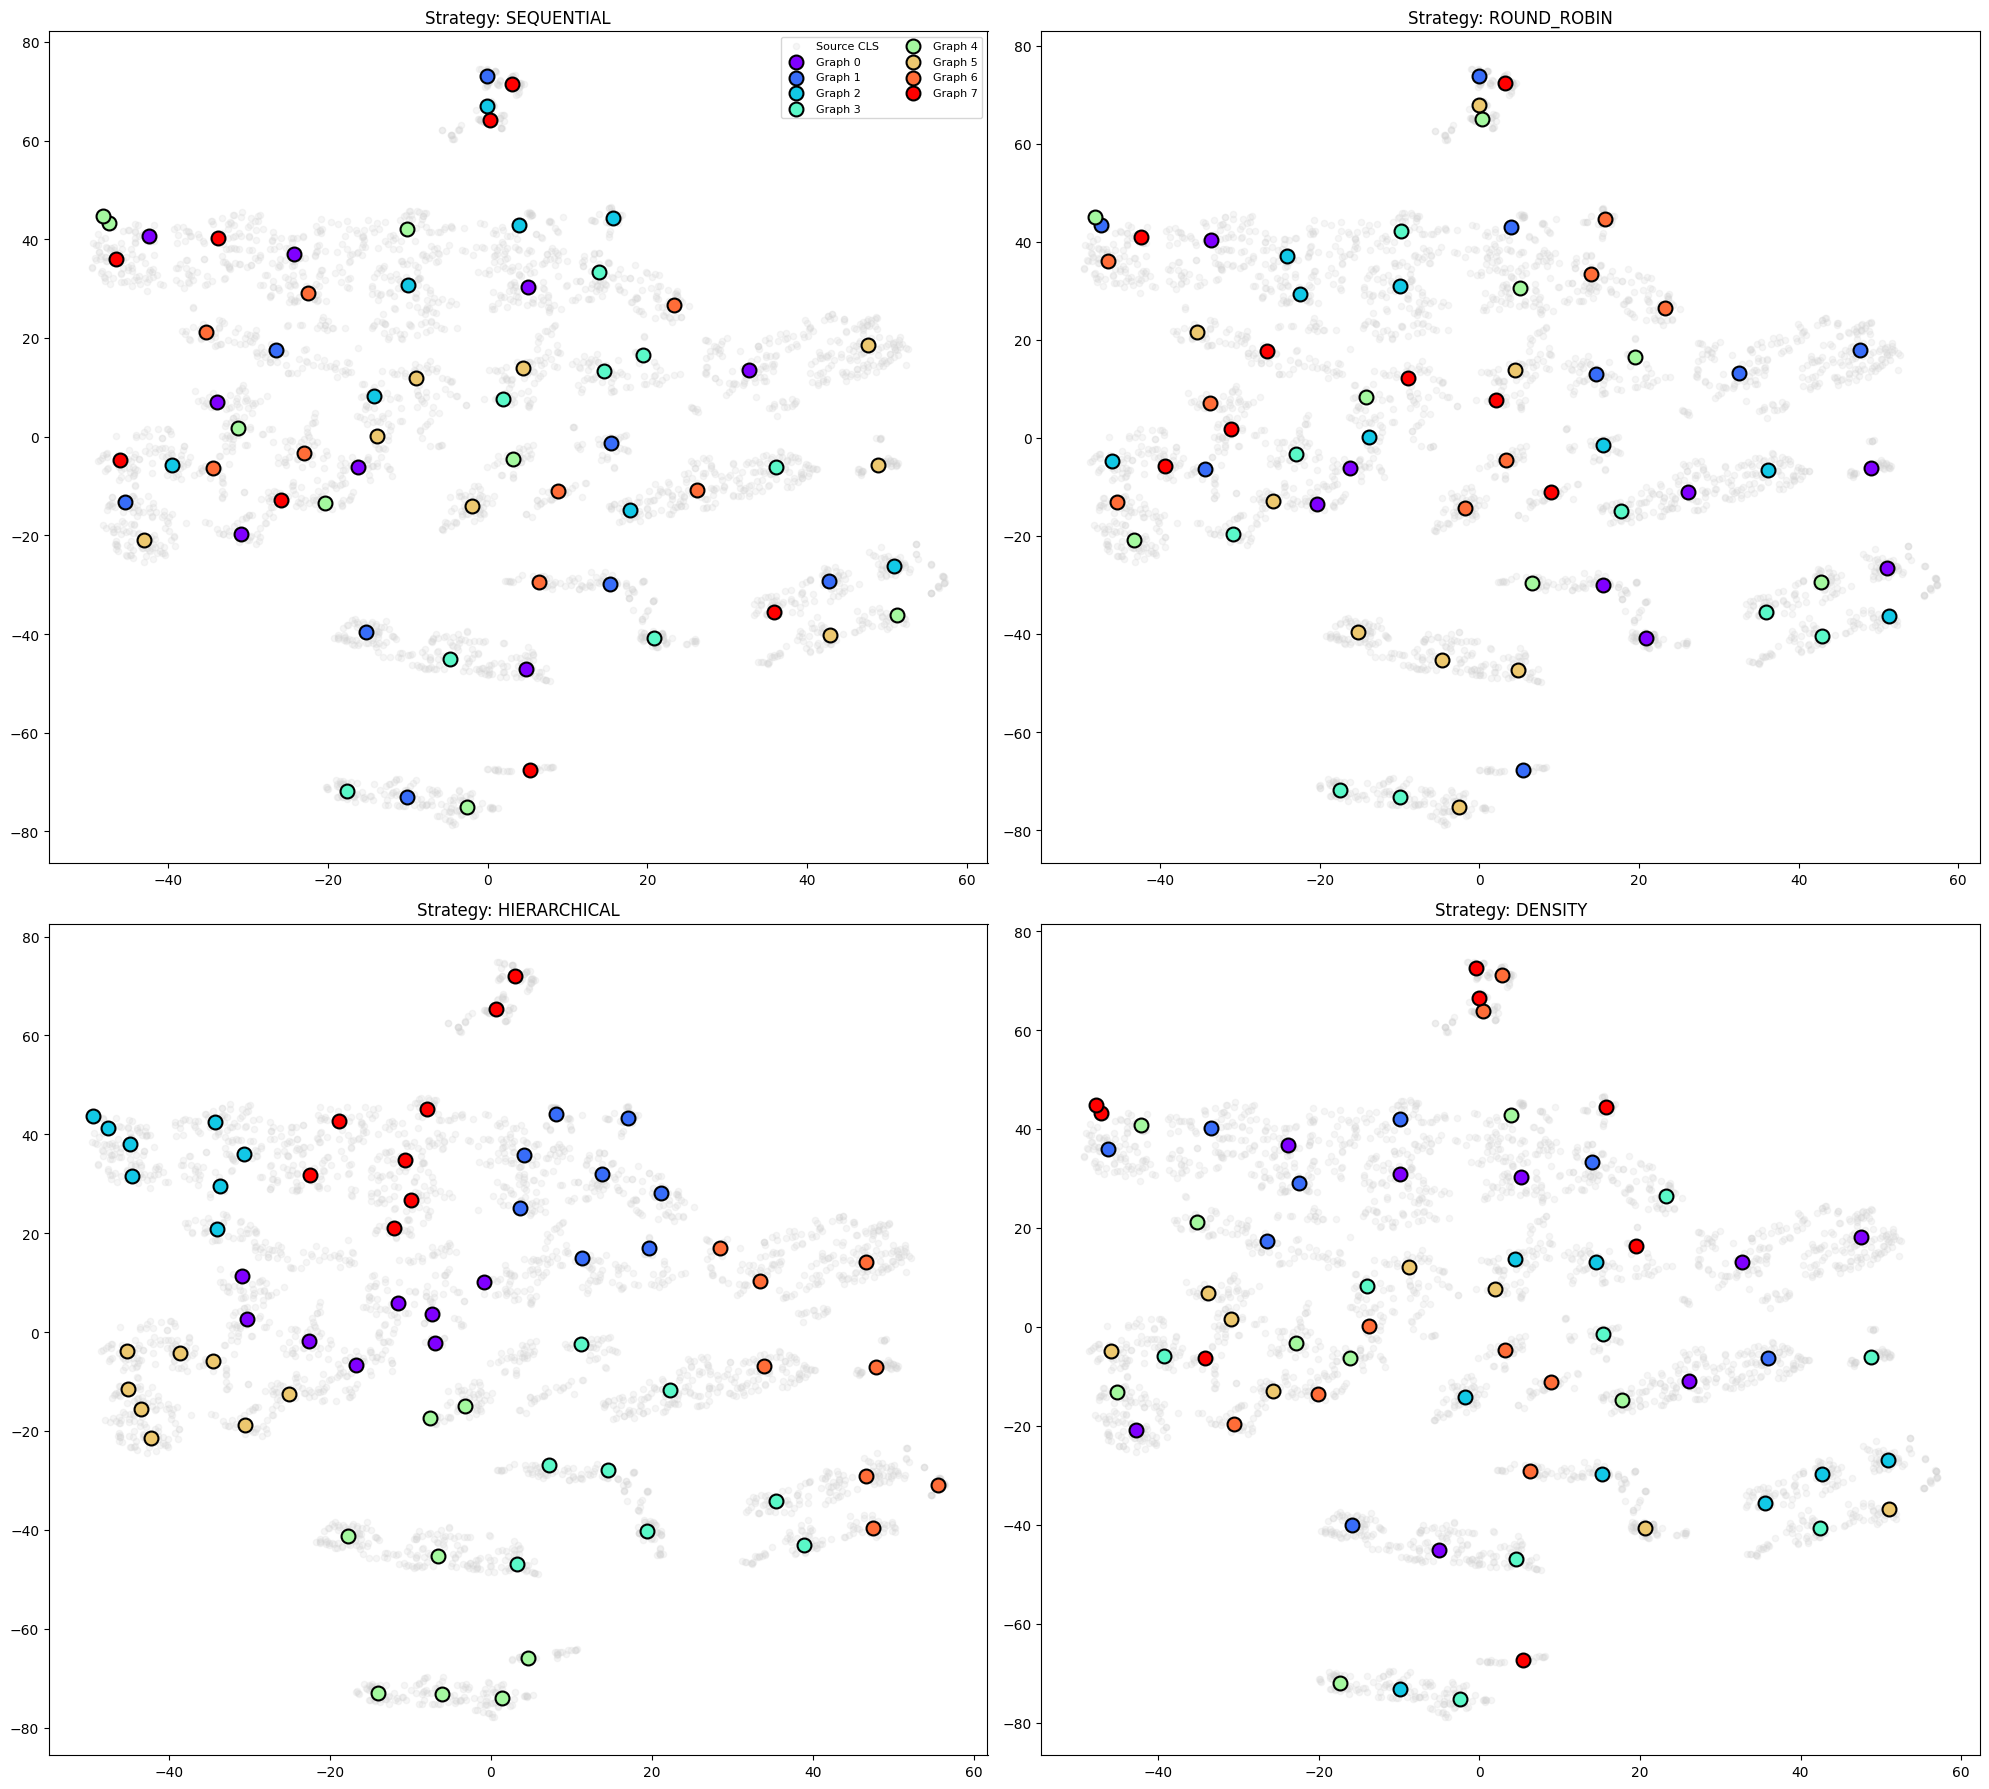

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

def simulate_and_visualize_strategies(model, loaders, device, M=8, K=8, num_vis_samples=3000):
    print(f"\n{'='*10} Simulating LCG Initialization Strategies {'='*10}")
    
    # --- Step 1. Collect Pre-trained CLS Tokens ---
    print(">> 1. Collecting CLS tokens from Vanilla GAT...")
    all_cls = []
    model.eval()
    
    with torch.no_grad():
        for src_name, loader in loaders.items():
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
                # GAT Forward Logic (CLS Extraction)
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                # CLS Token (Index 0)
                cls_token = x_basis[:, 0, :].cpu().numpy()
                all_cls.append(cls_token)
                
                # 너무 많으면 메모리 터지니 2만개 정도만 수집
                if sum([len(x) for x in all_cls]) > 20000: break
    
    pool_cls = np.concatenate(all_cls, axis=0)
    print(f"   >> Total CLS Collected: {pool_cls.shape[0]}")

    # --- Step 2. Define Strategies ---
    strategies = ['sequential', 'round_robin', 'hierarchical', 'density']
    
    # 시각화용 Figure 생성 (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    # t-SNE를 위한 배경 데이터 샘플링 (속도 최적화)
    if pool_cls.shape[0] > num_vis_samples:
        idx = np.random.choice(pool_cls.shape[0], num_vis_samples, replace=False)
        vis_cls = pool_cls[idx]
    else:
        vis_cls = pool_cls

    for i, strategy in enumerate(strategies):
        print(f">> Simulating Strategy: [{strategy.upper()}]...")
        
        # --- Logic per Strategy ---
        centroids = None # Shape: [M, K, D]
        
        if strategy in ['sequential', 'round_robin', 'density']:
            # Global KMeans
            kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_cls)
            centers = kmeans.cluster_centers_
            
            if strategy == 'sequential':
                # [M*K, D] -> [M, K, D]
                centroids = centers.reshape(M, K, -1)
                
            elif strategy == 'round_robin':
                # [M*K, D] -> [K, M, D] -> Transpose -> [M, K, D]
                centroids = centers.reshape(K, M, -1).transpose(1, 0, 2)
                
            elif strategy == 'density':
                # Sort by cluster size
                labels = kmeans.labels_
                counts = np.bincount(labels, minlength=M*K)
                sorted_idx = np.argsort(counts)[::-1] # Descending
                centroids = centers[sorted_idx].reshape(M, K, -1)
                
        elif strategy == 'hierarchical':
            # 2-Step KMeans
            centroids = np.zeros((M, K, pool_cls.shape[1]))
            km_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(pool_cls)
            
            for m in range(M):
                group = pool_cls[km_global.labels_ == m]
                # 데이터 부족 시 보충
                if len(group) < K:
                    supp = pool_cls[np.random.choice(len(pool_cls), K - len(group))]
                    group = np.concatenate([group, supp], axis=0)
                    
                km_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group)
                centroids[m] = km_local.cluster_centers_

        # --- Step 3. t-SNE & Plotting ---
        # [CLS + Centroids]를 합쳐서 t-SNE 수행
        flat_centroids = centroids.reshape(-1, centroids.shape[-1])
        all_data = np.concatenate([vis_cls, flat_centroids], axis=0)
        
        # t-SNE (Perplexity 낮춤 for sparse centroids)
        tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
        embedded = tsne.fit_transform(all_data)
        
        idx_split = vis_cls.shape[0]
        emb_cls = embedded[:idx_split]
        emb_cen = embedded[idx_split:]
        
        # Plot
        ax = axes[i]
        # 배경 (Source CLS)
        ax.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.2, s=20, label='Source CLS')
        
        # Centroids (Color by Graph ID)
        colors = cm.rainbow(np.linspace(0, 1, M))
        for m in range(M):
            start = m * K
            end = (m + 1) * K
            subset = emb_cen[start:end]
            ax.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
                       edgecolor='black', linewidth=1.5, label=f'Graph {m}' if i==0 else "")
            
        ax.set_title(f"Strategy: {strategy.upper()}")
        if i == 0: ax.legend(loc='best', ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

# 실행
simulate_and_visualize_strategies(model, loaders, device, M=8, K=8)

## Gradient Check

Initialize Random Data...

========== STARTING FGW VERIFICATION (Epoch-wise Viz) ==========


[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


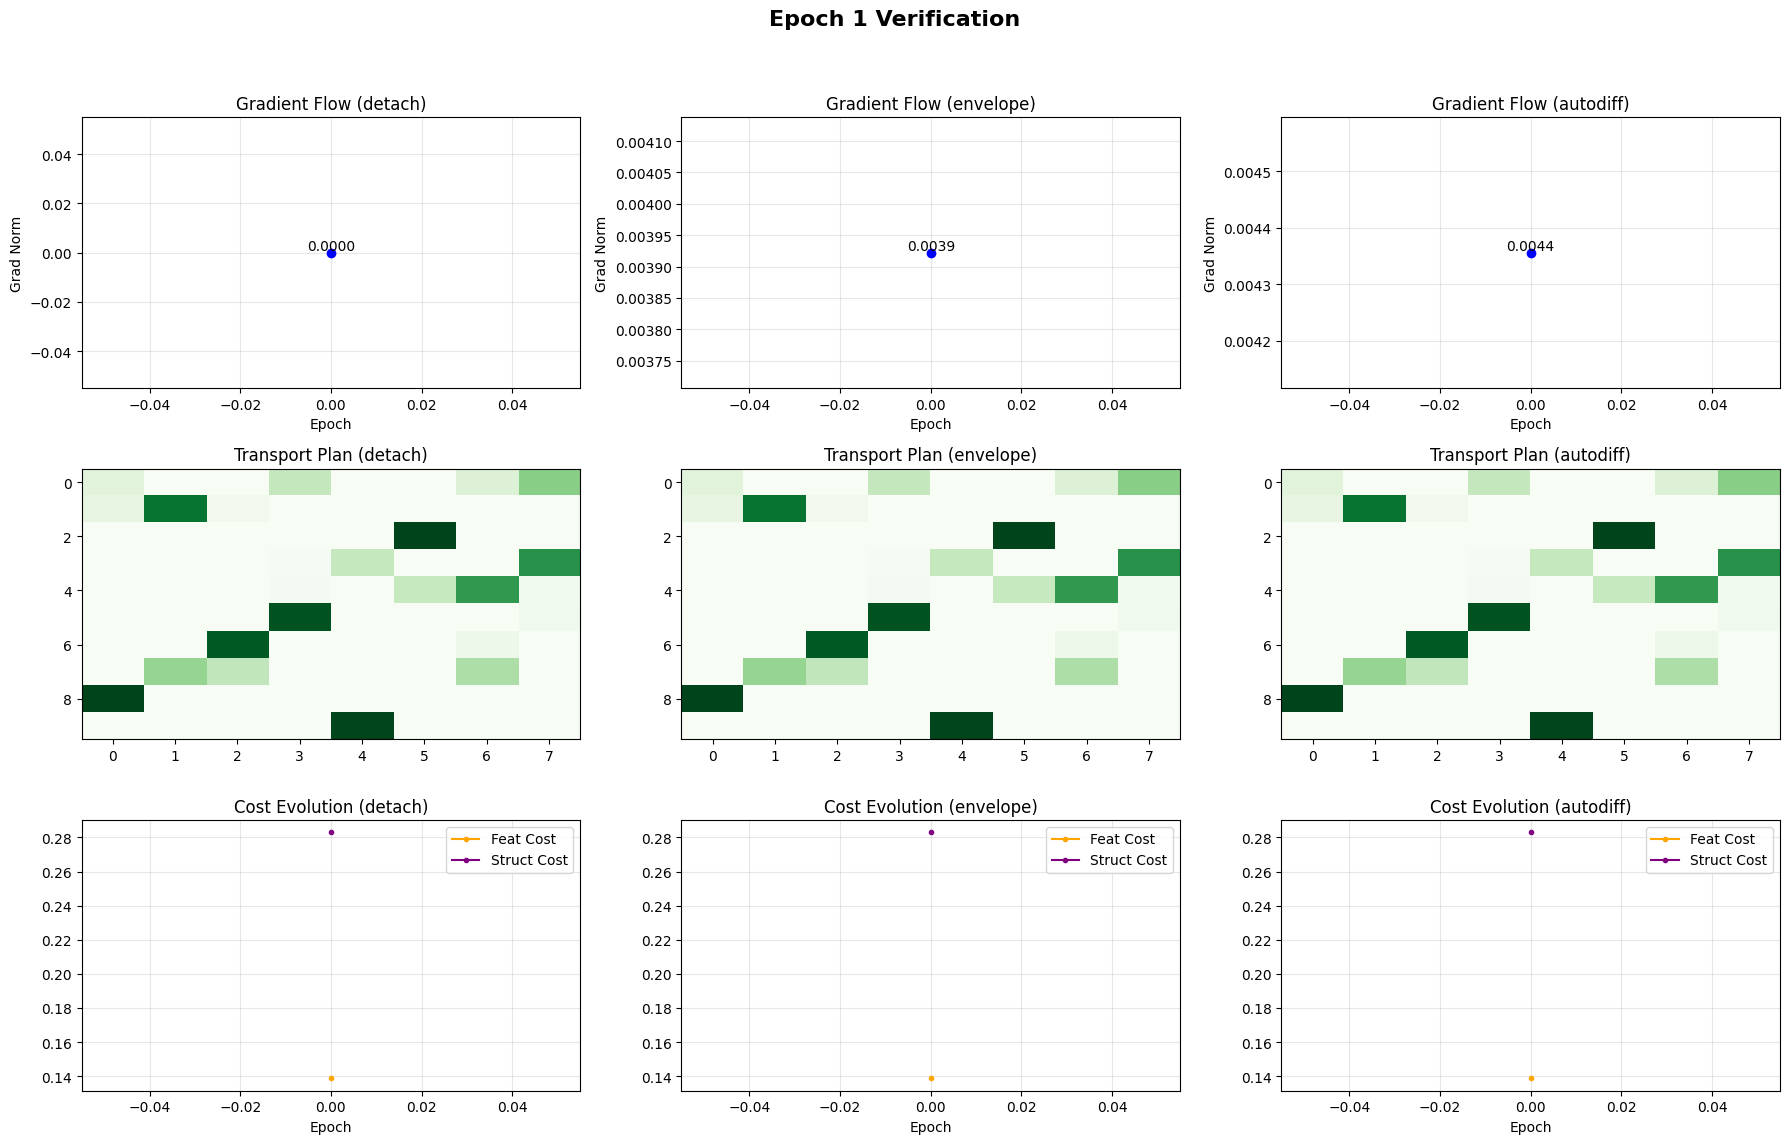

Epoch 1 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


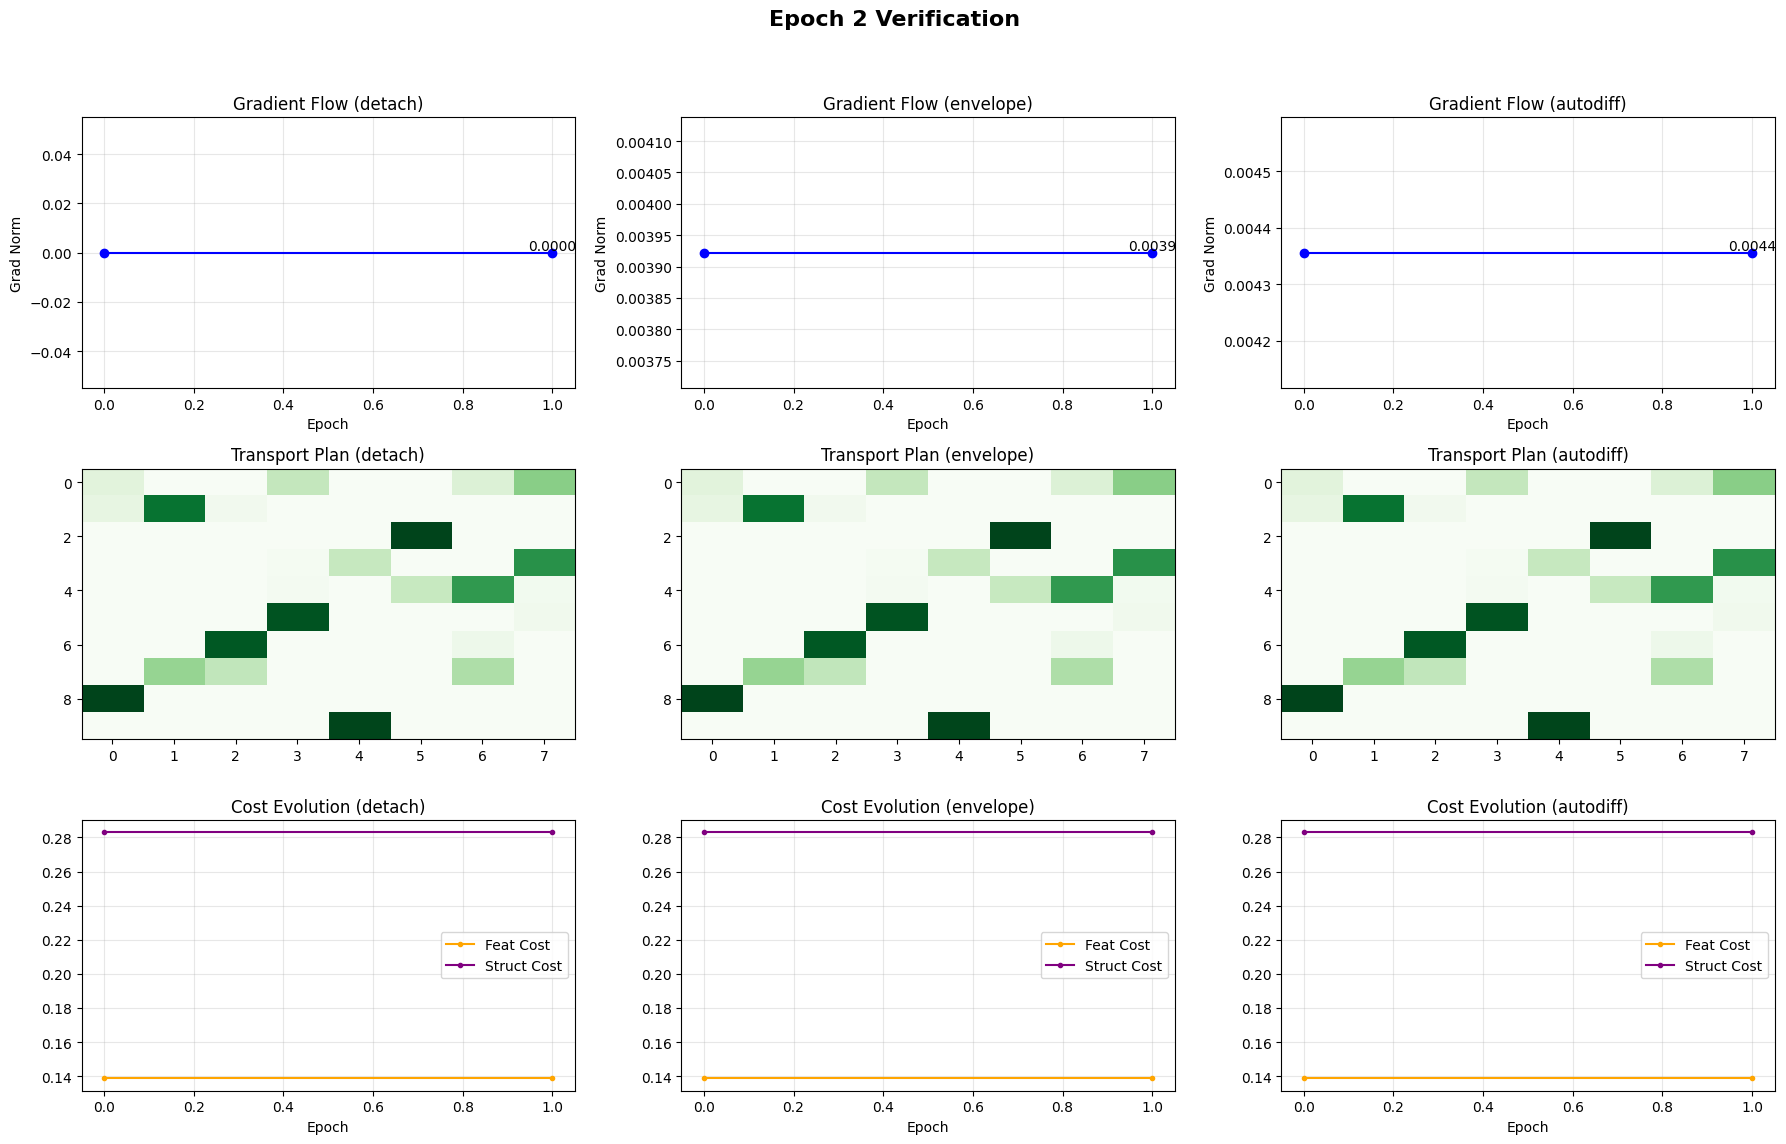

Epoch 2 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


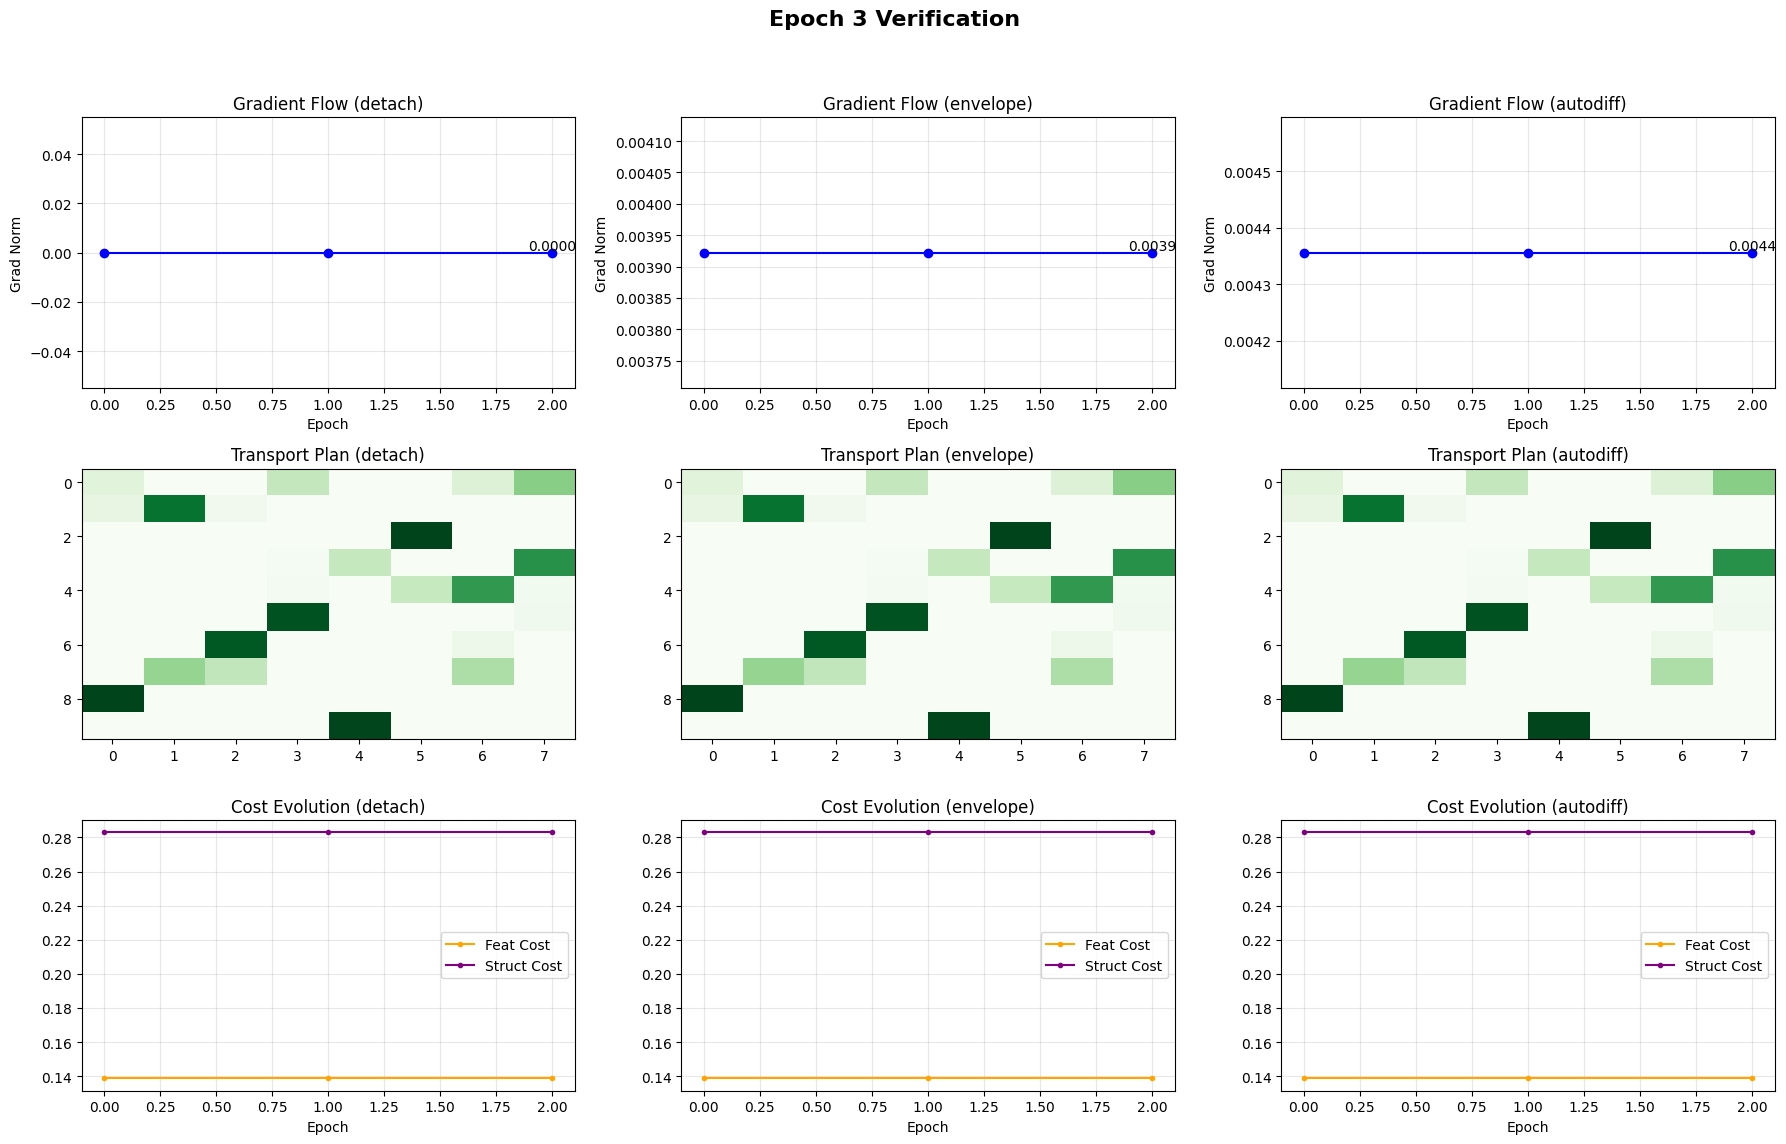

Epoch 3 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


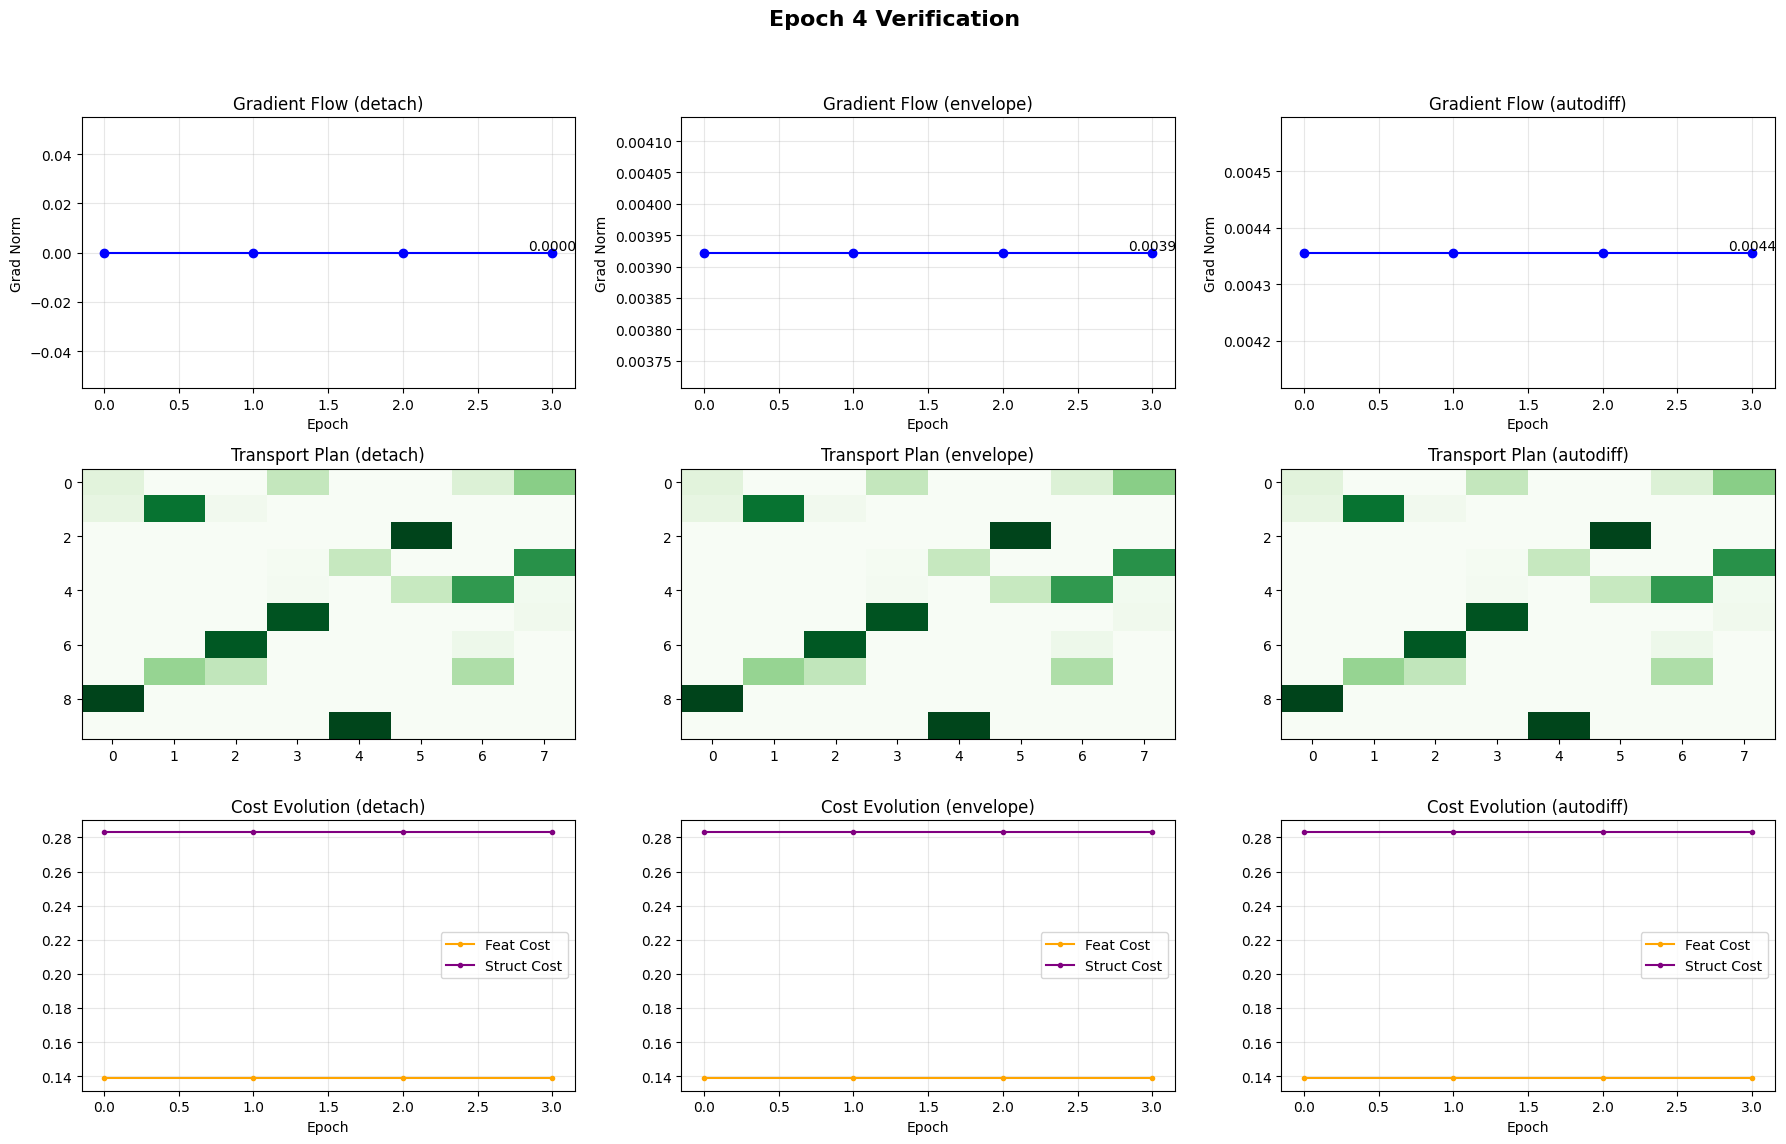

Epoch 4 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


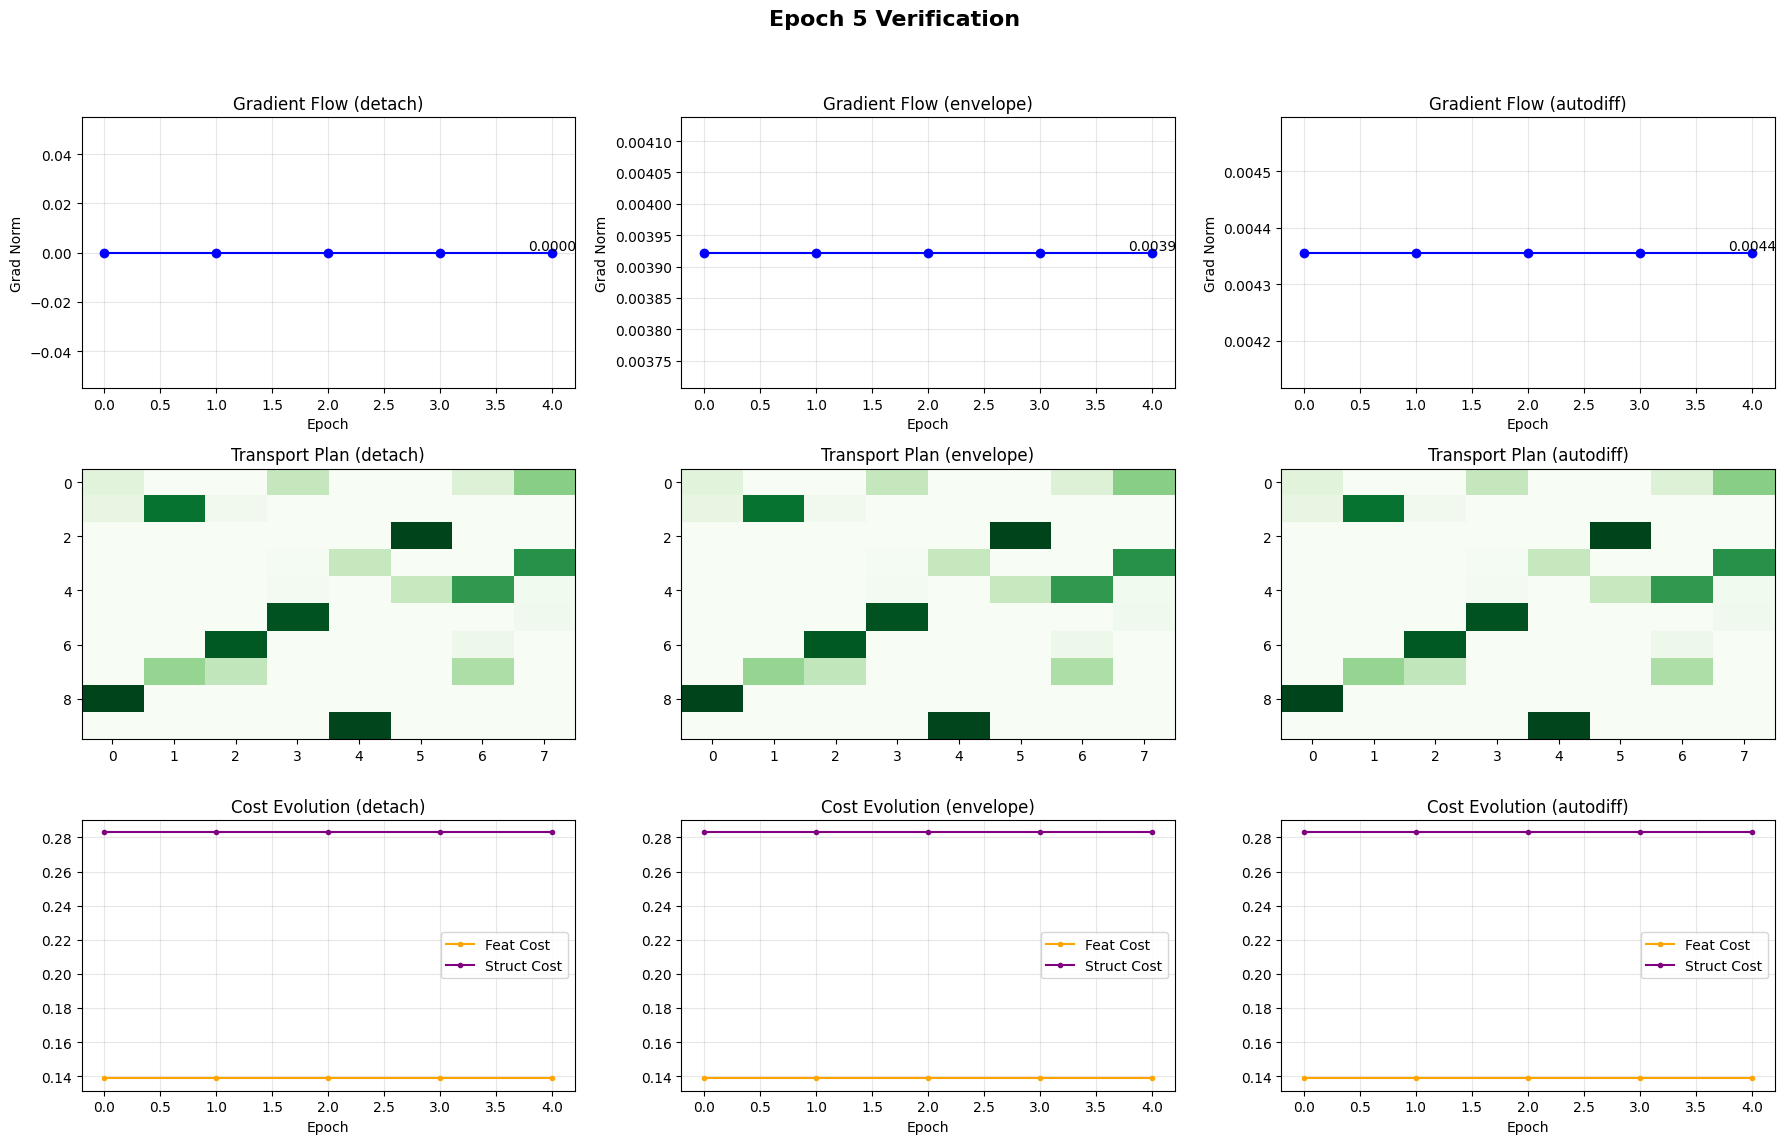

Epoch 5 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


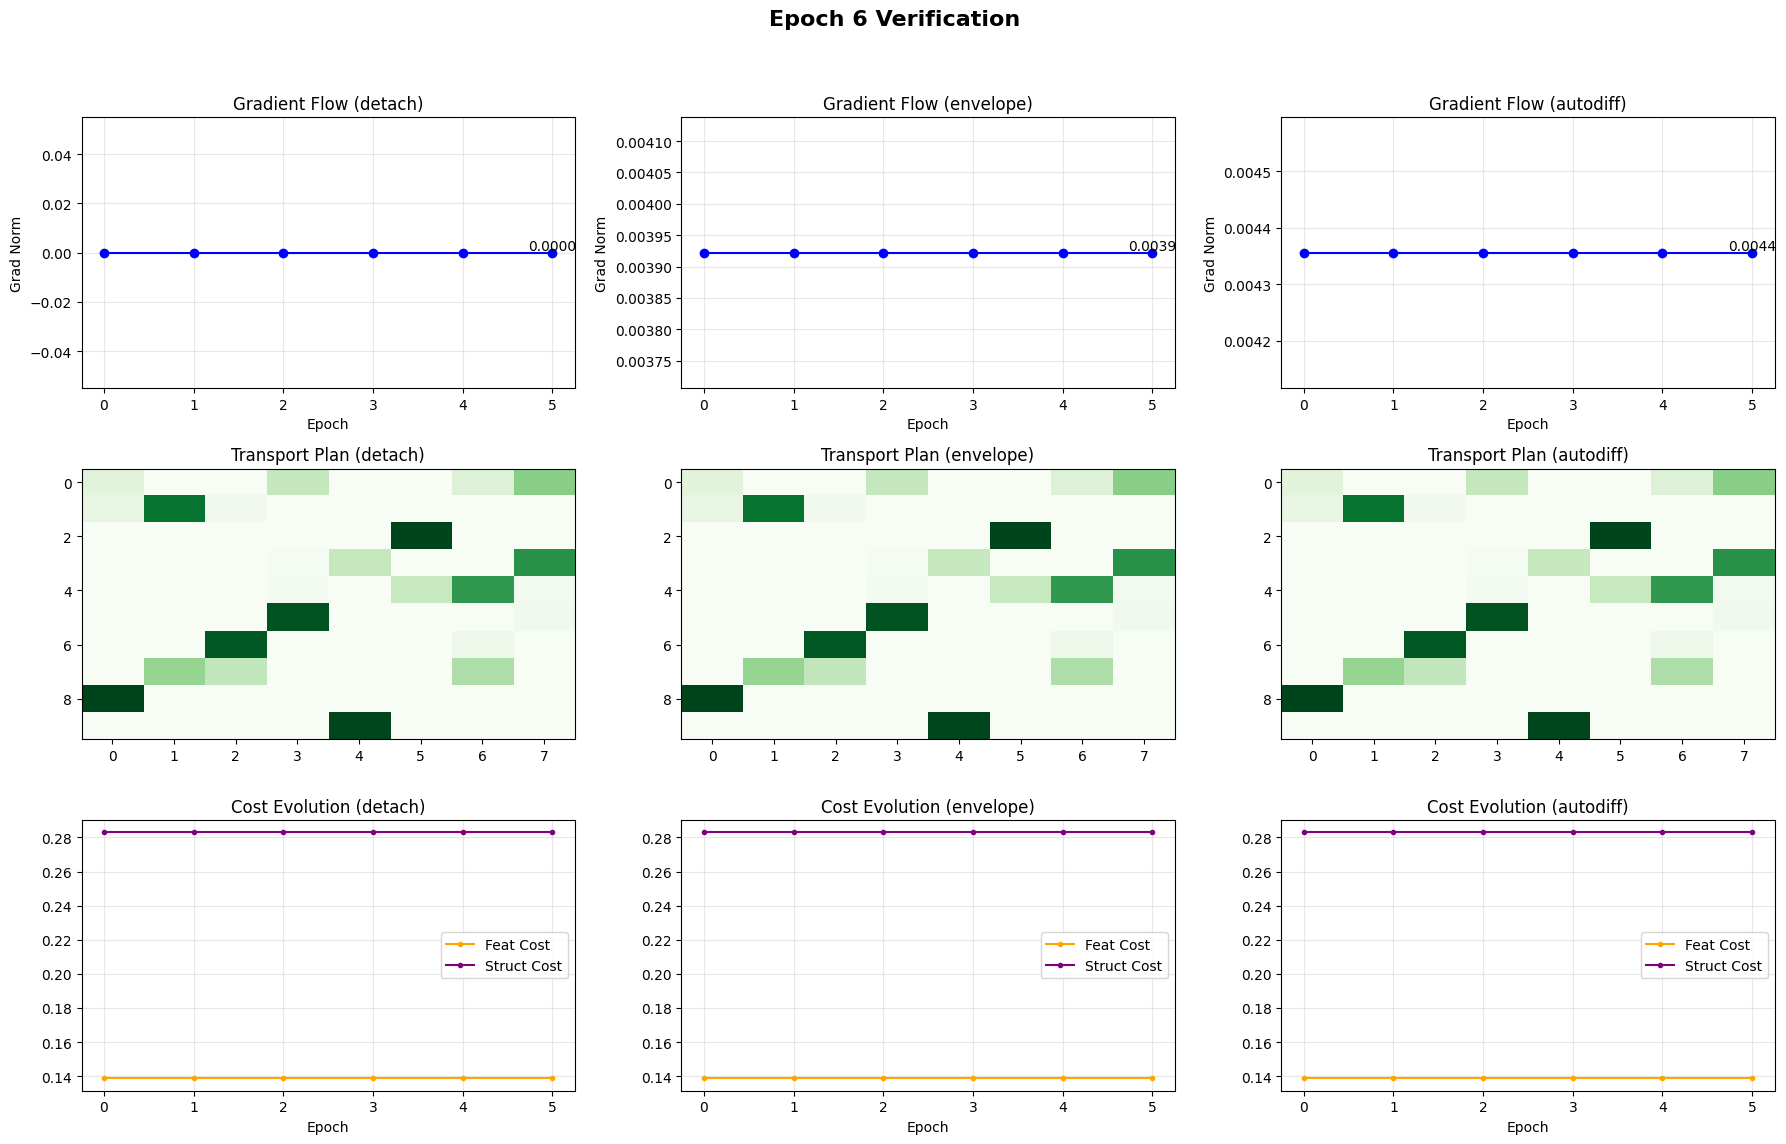

Epoch 6 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


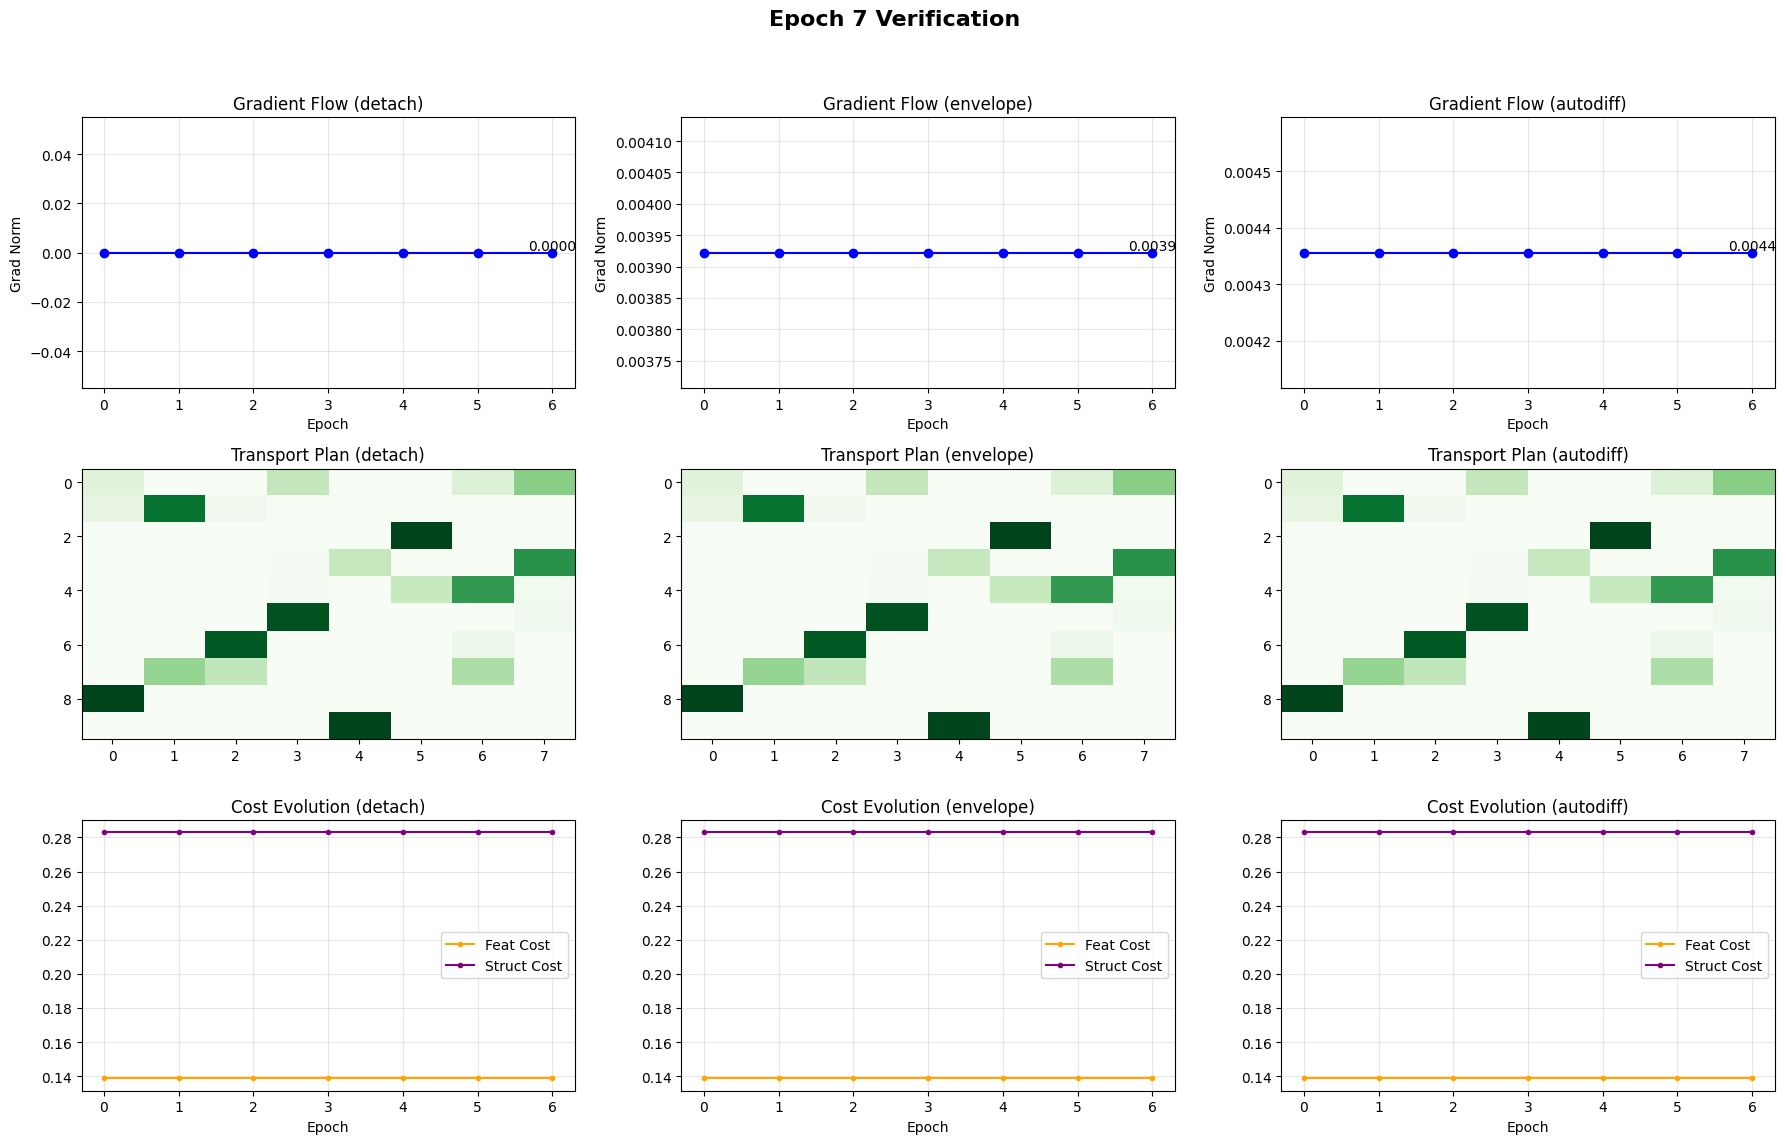

Epoch 7 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


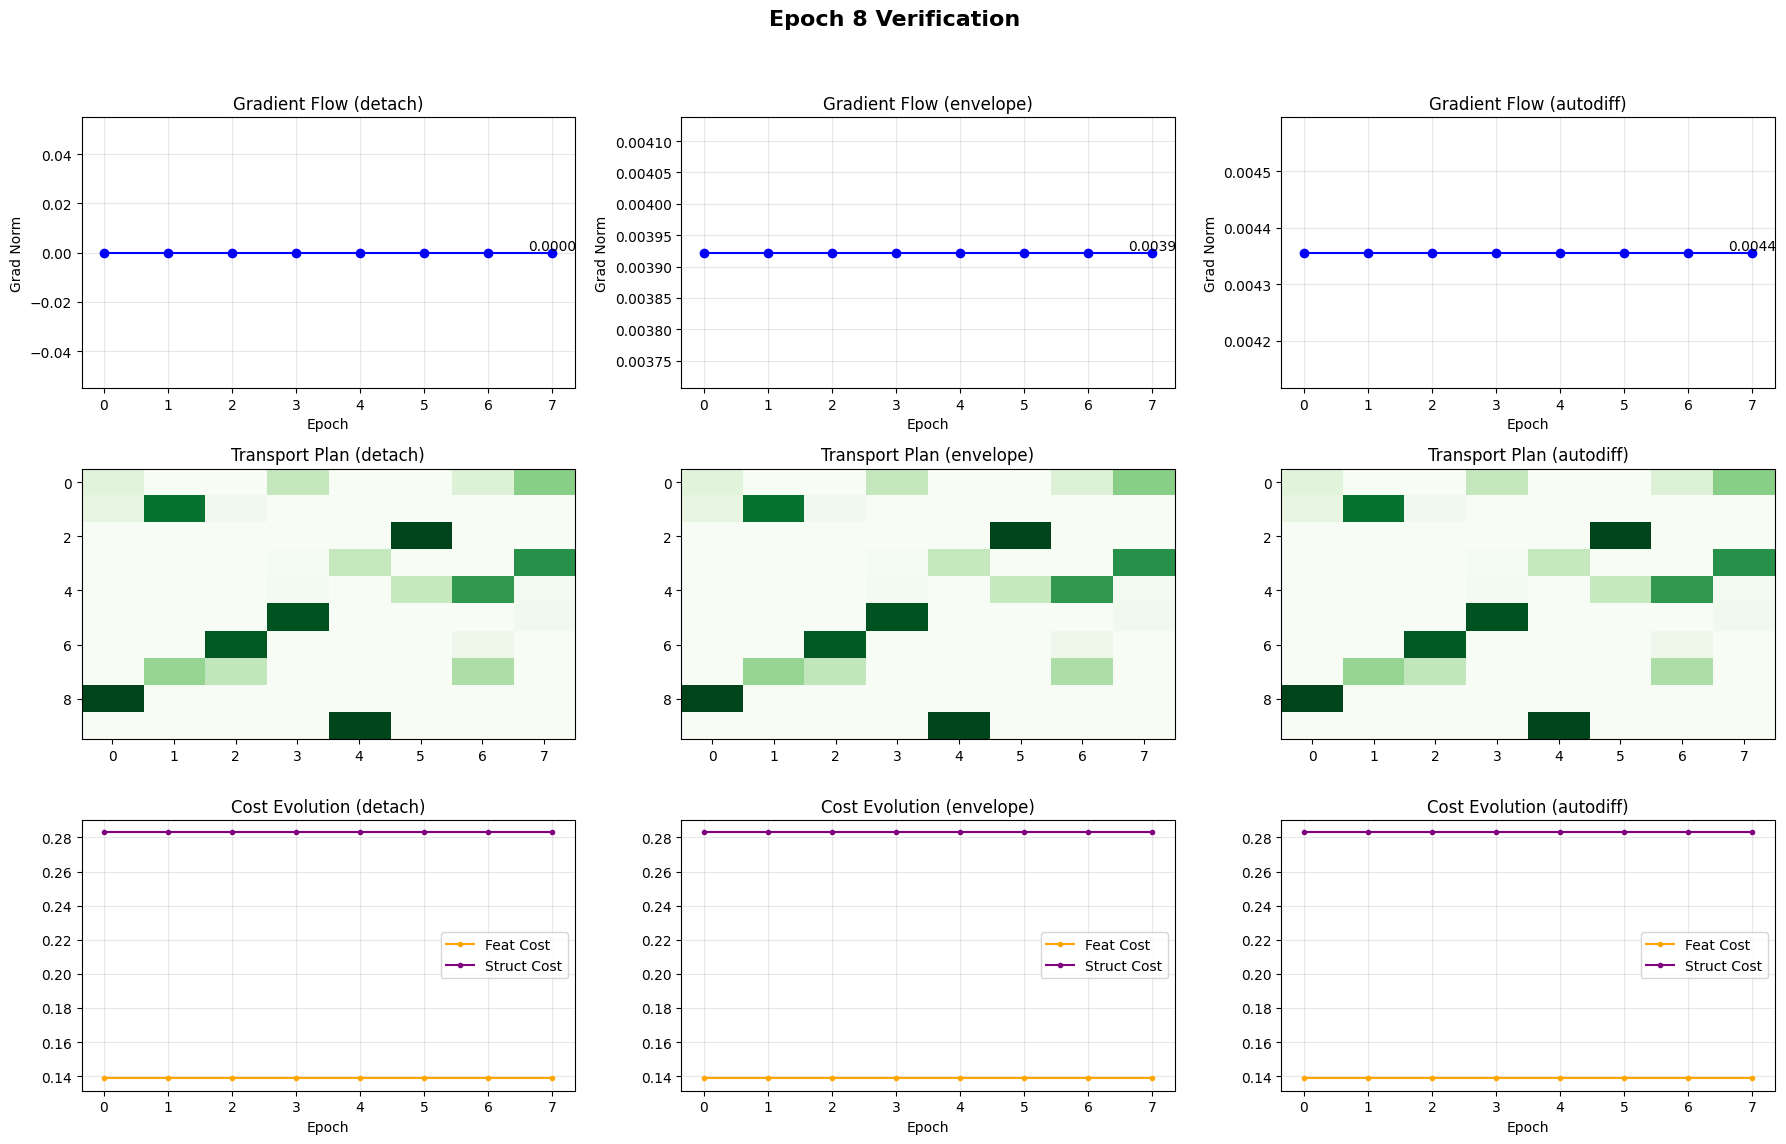

Epoch 8 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


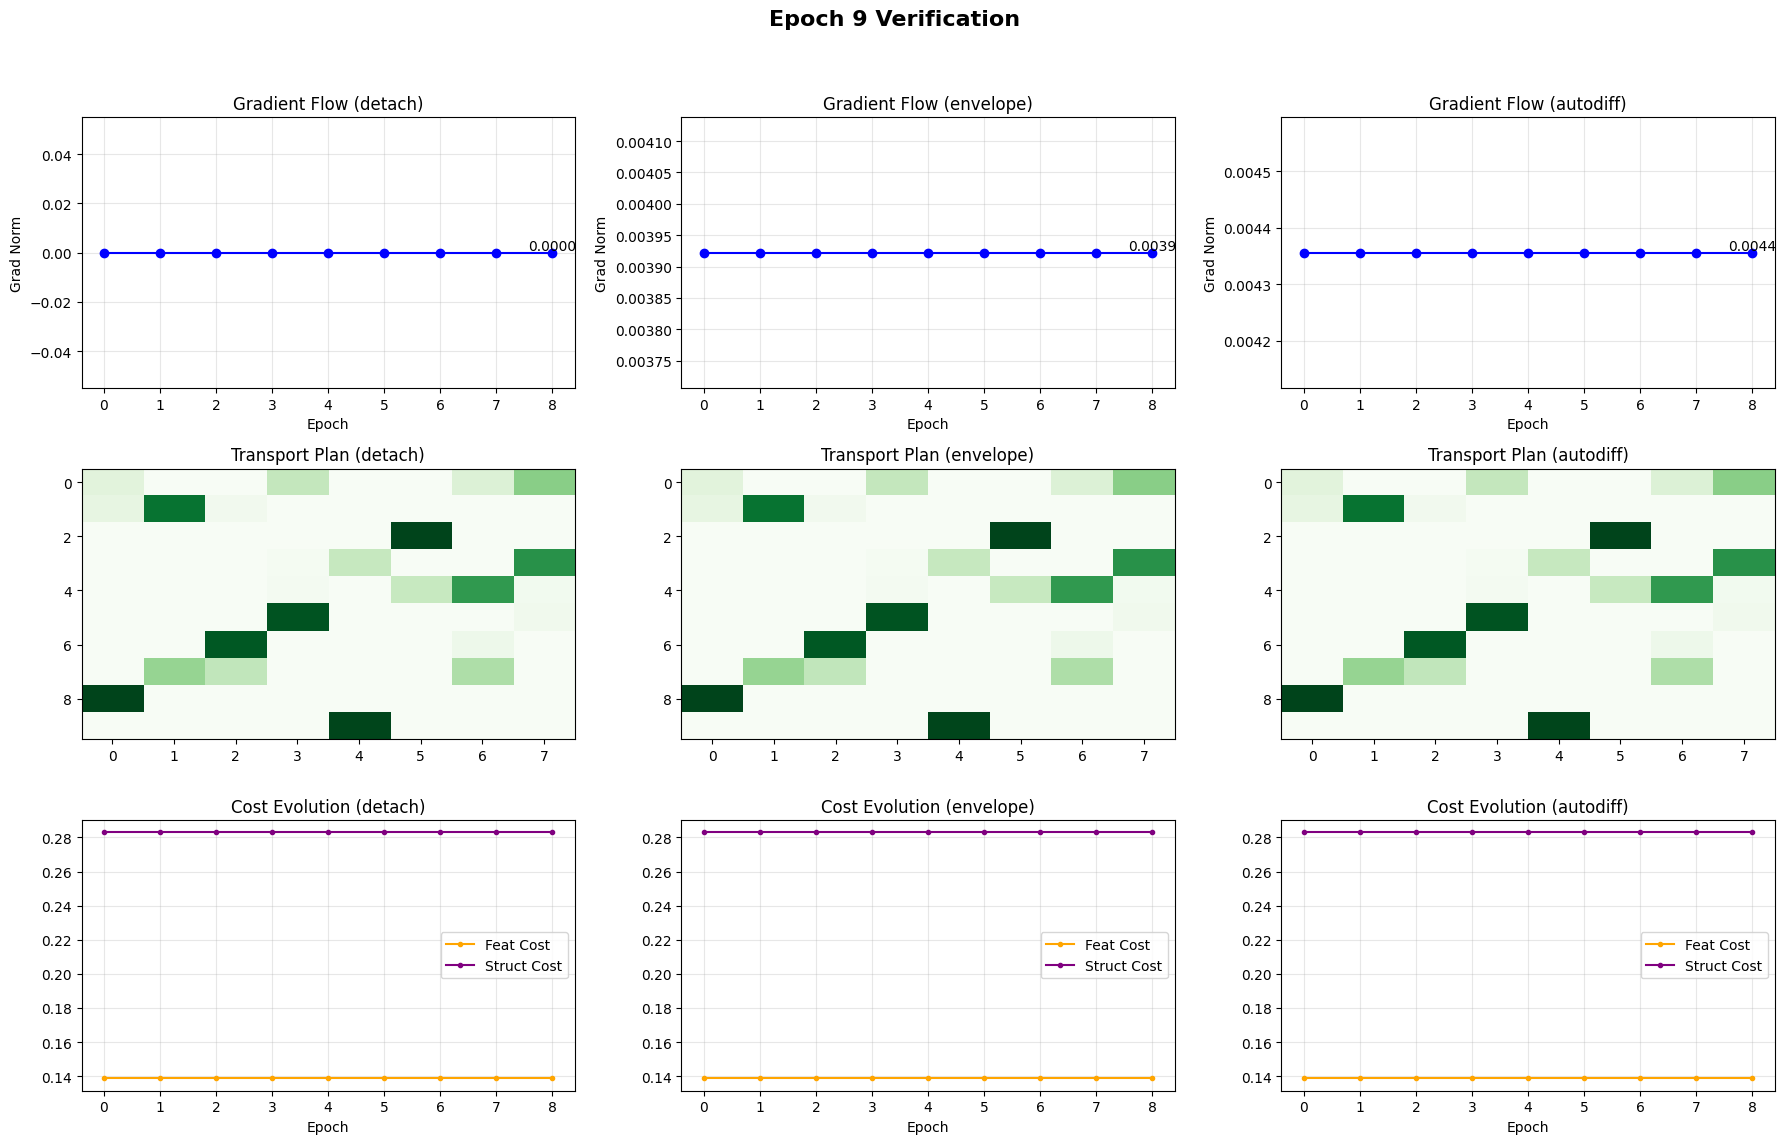

Epoch 9 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


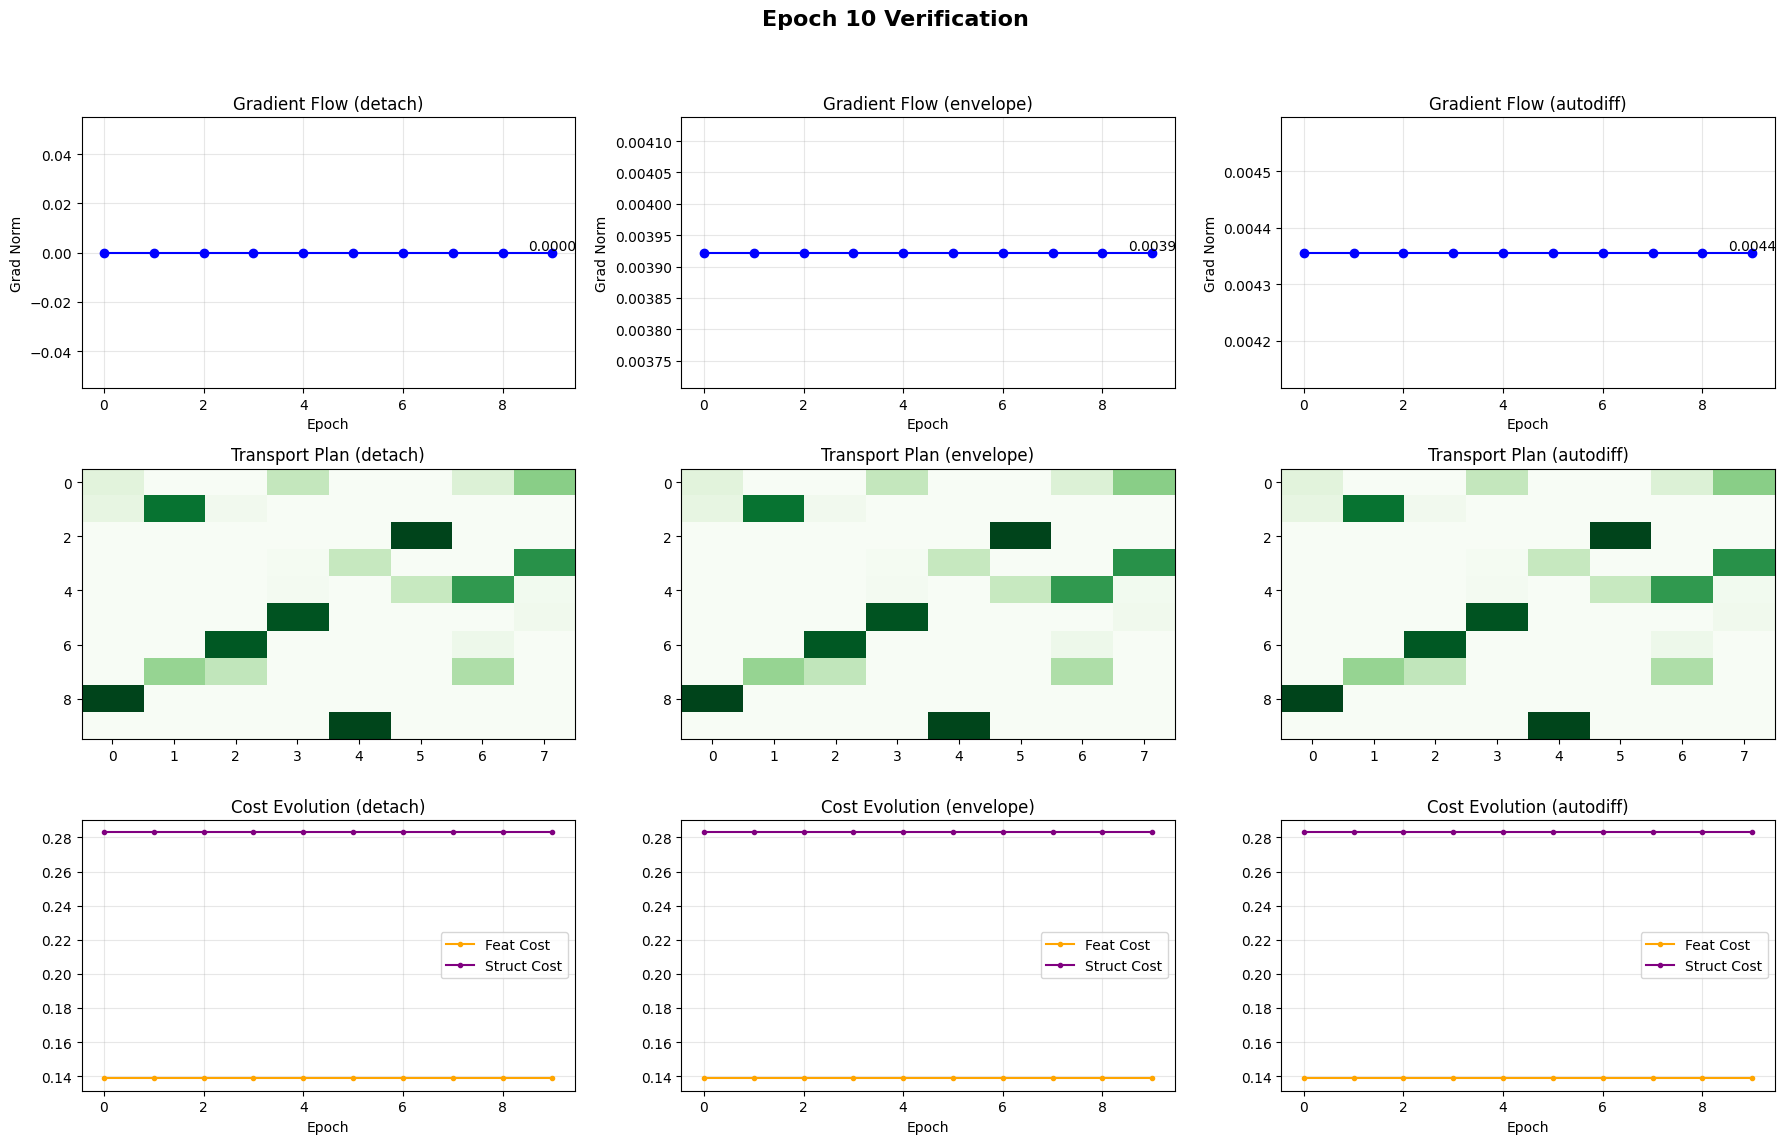

Epoch 10 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


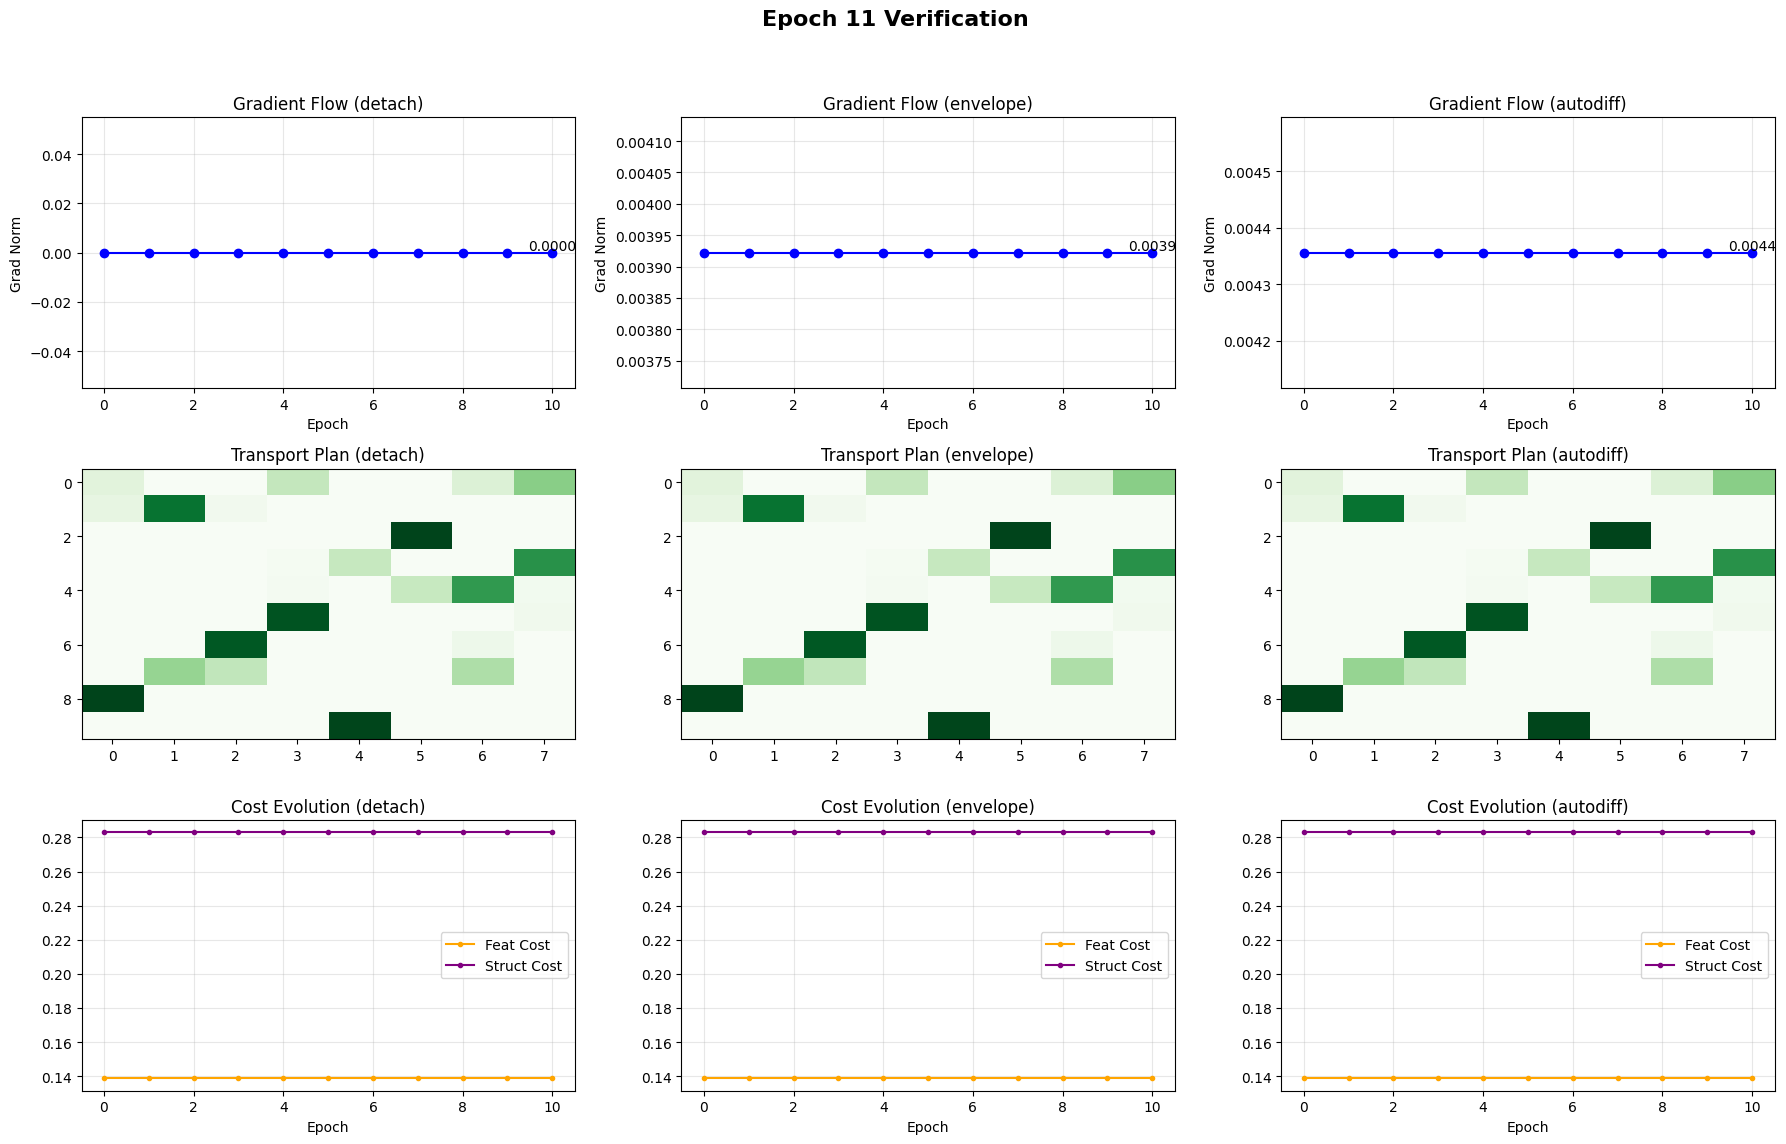

Epoch 11 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


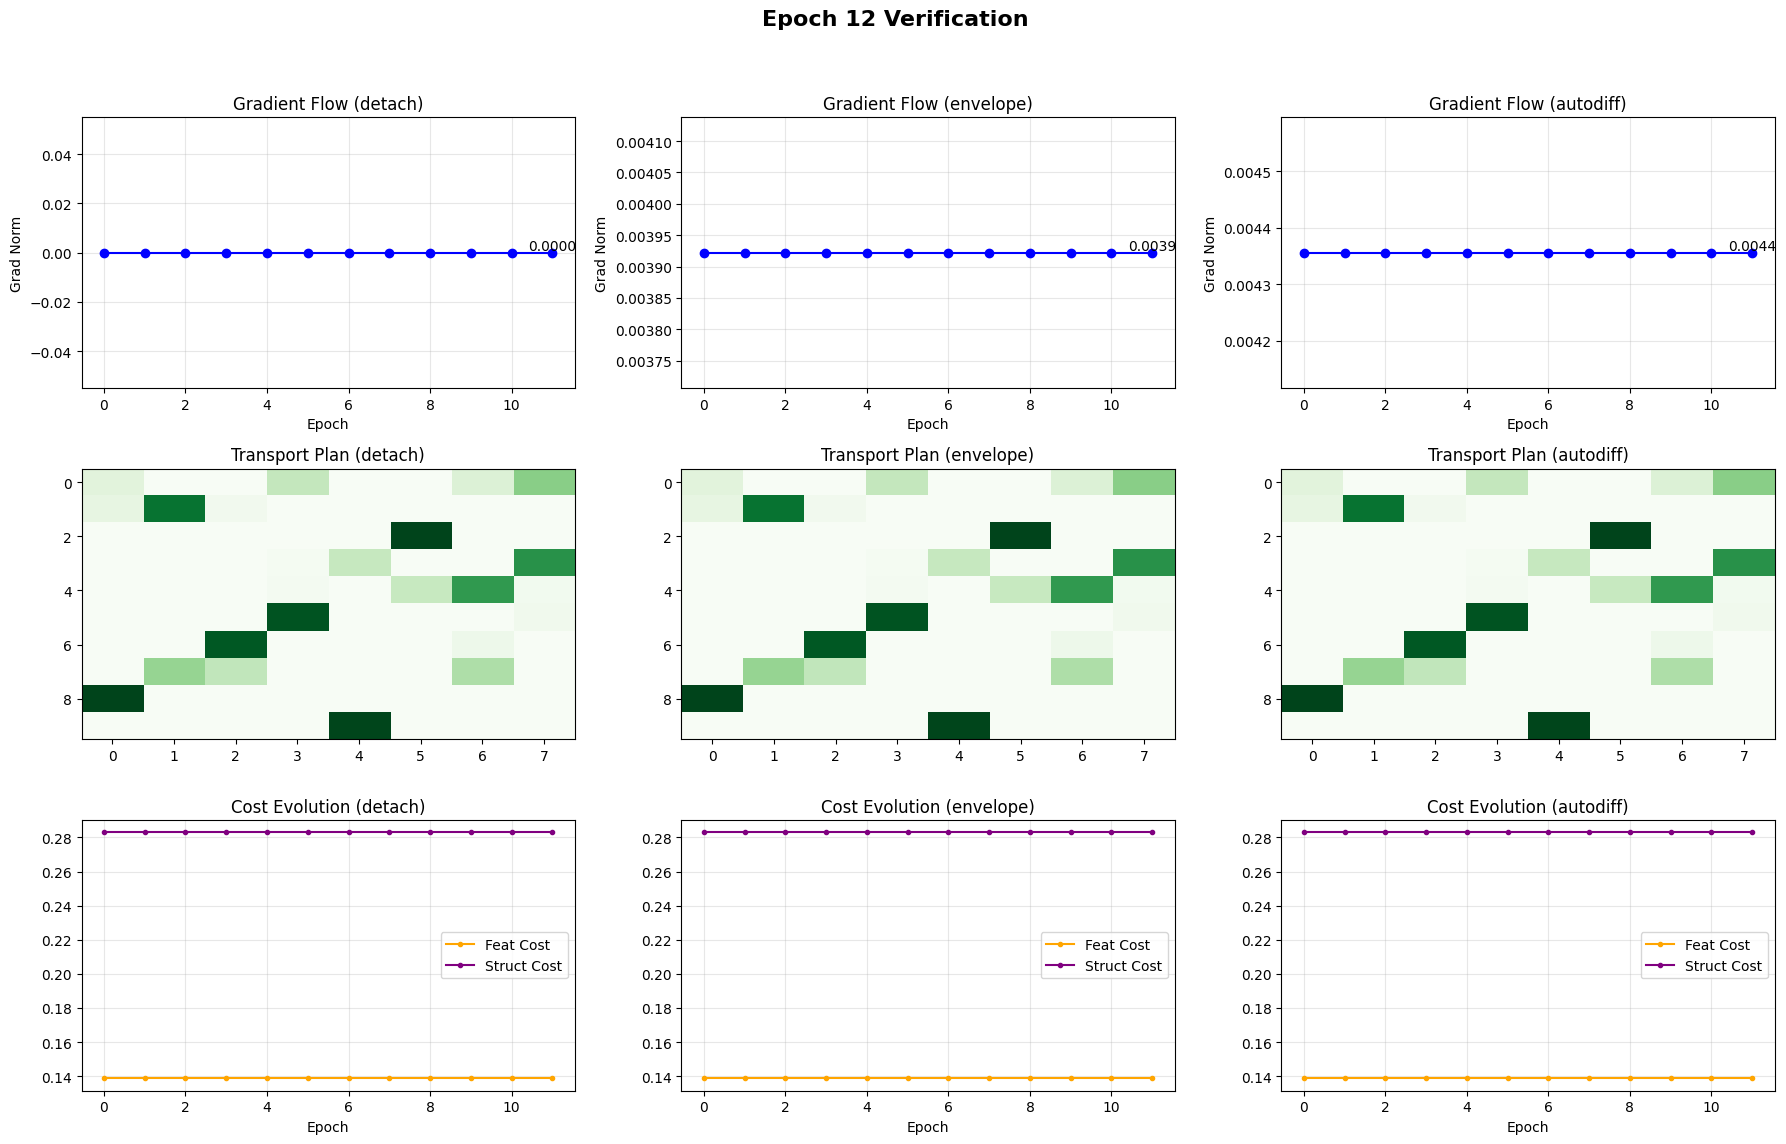

Epoch 12 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


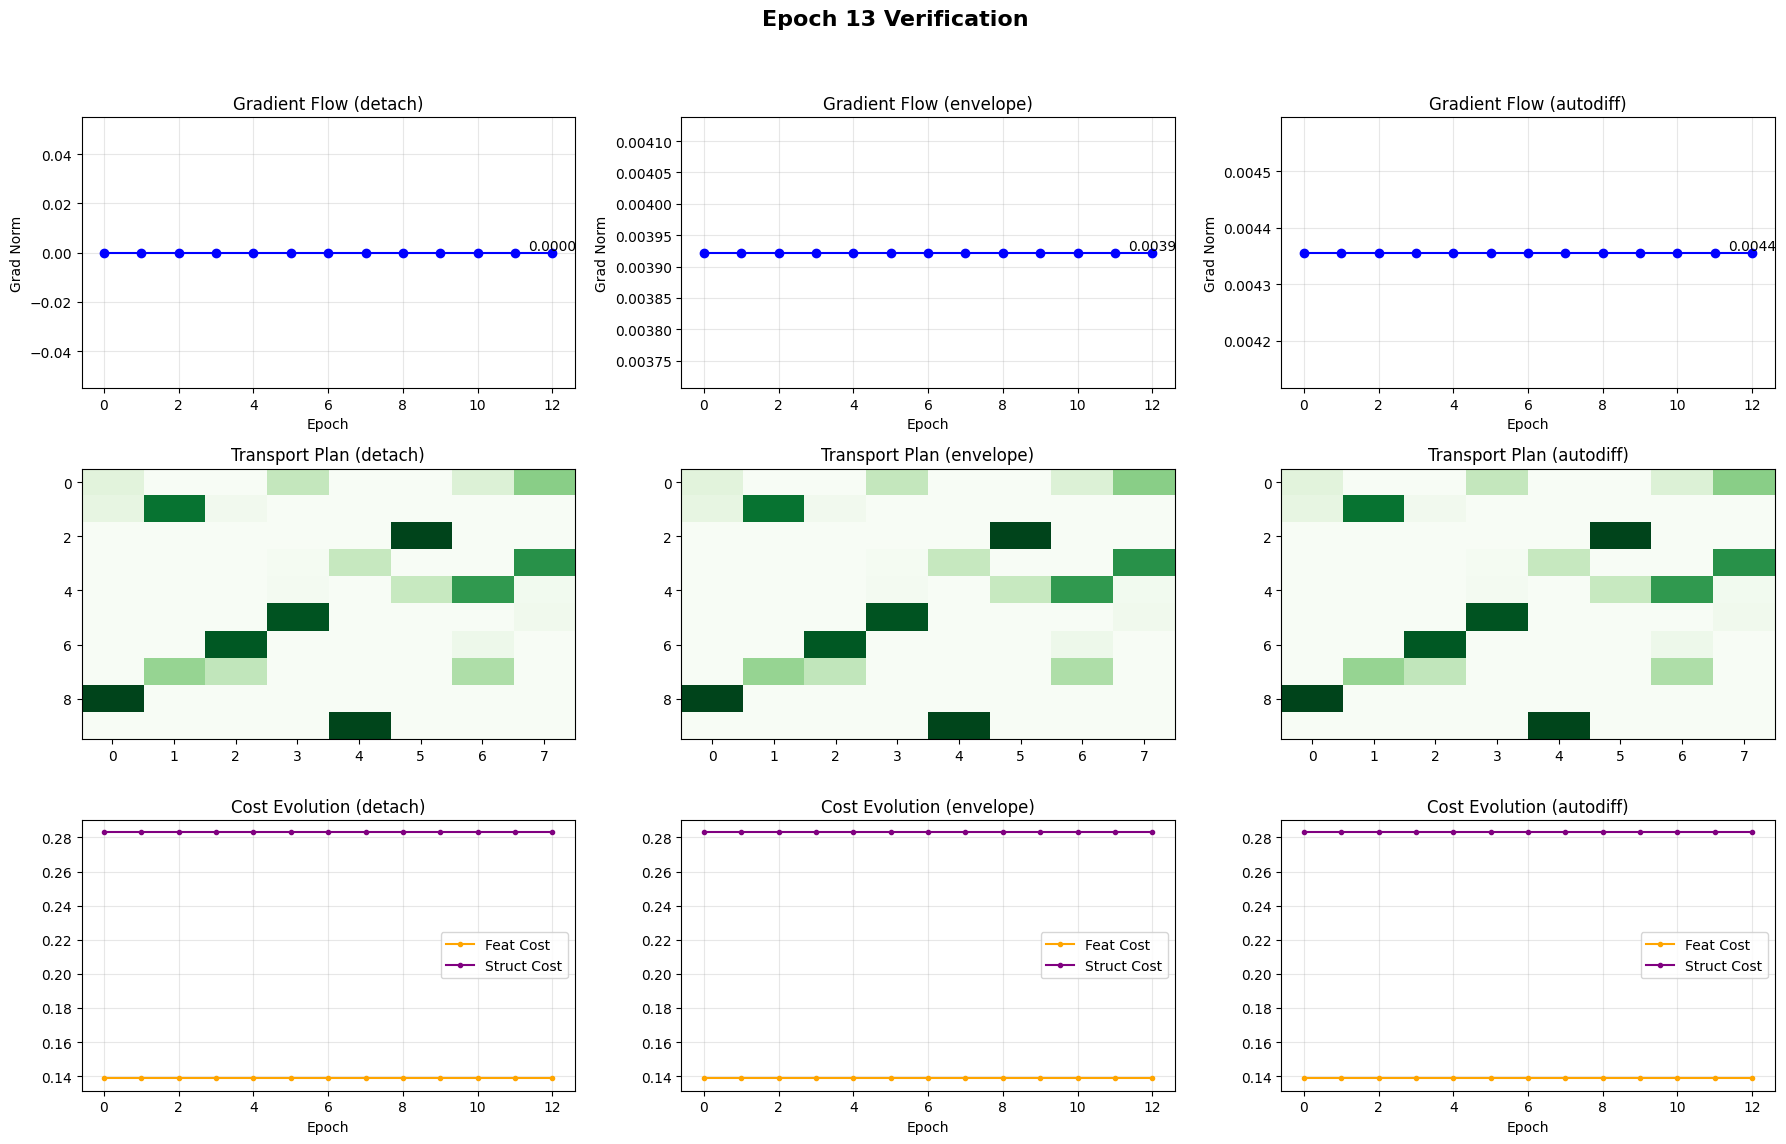

Epoch 13 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


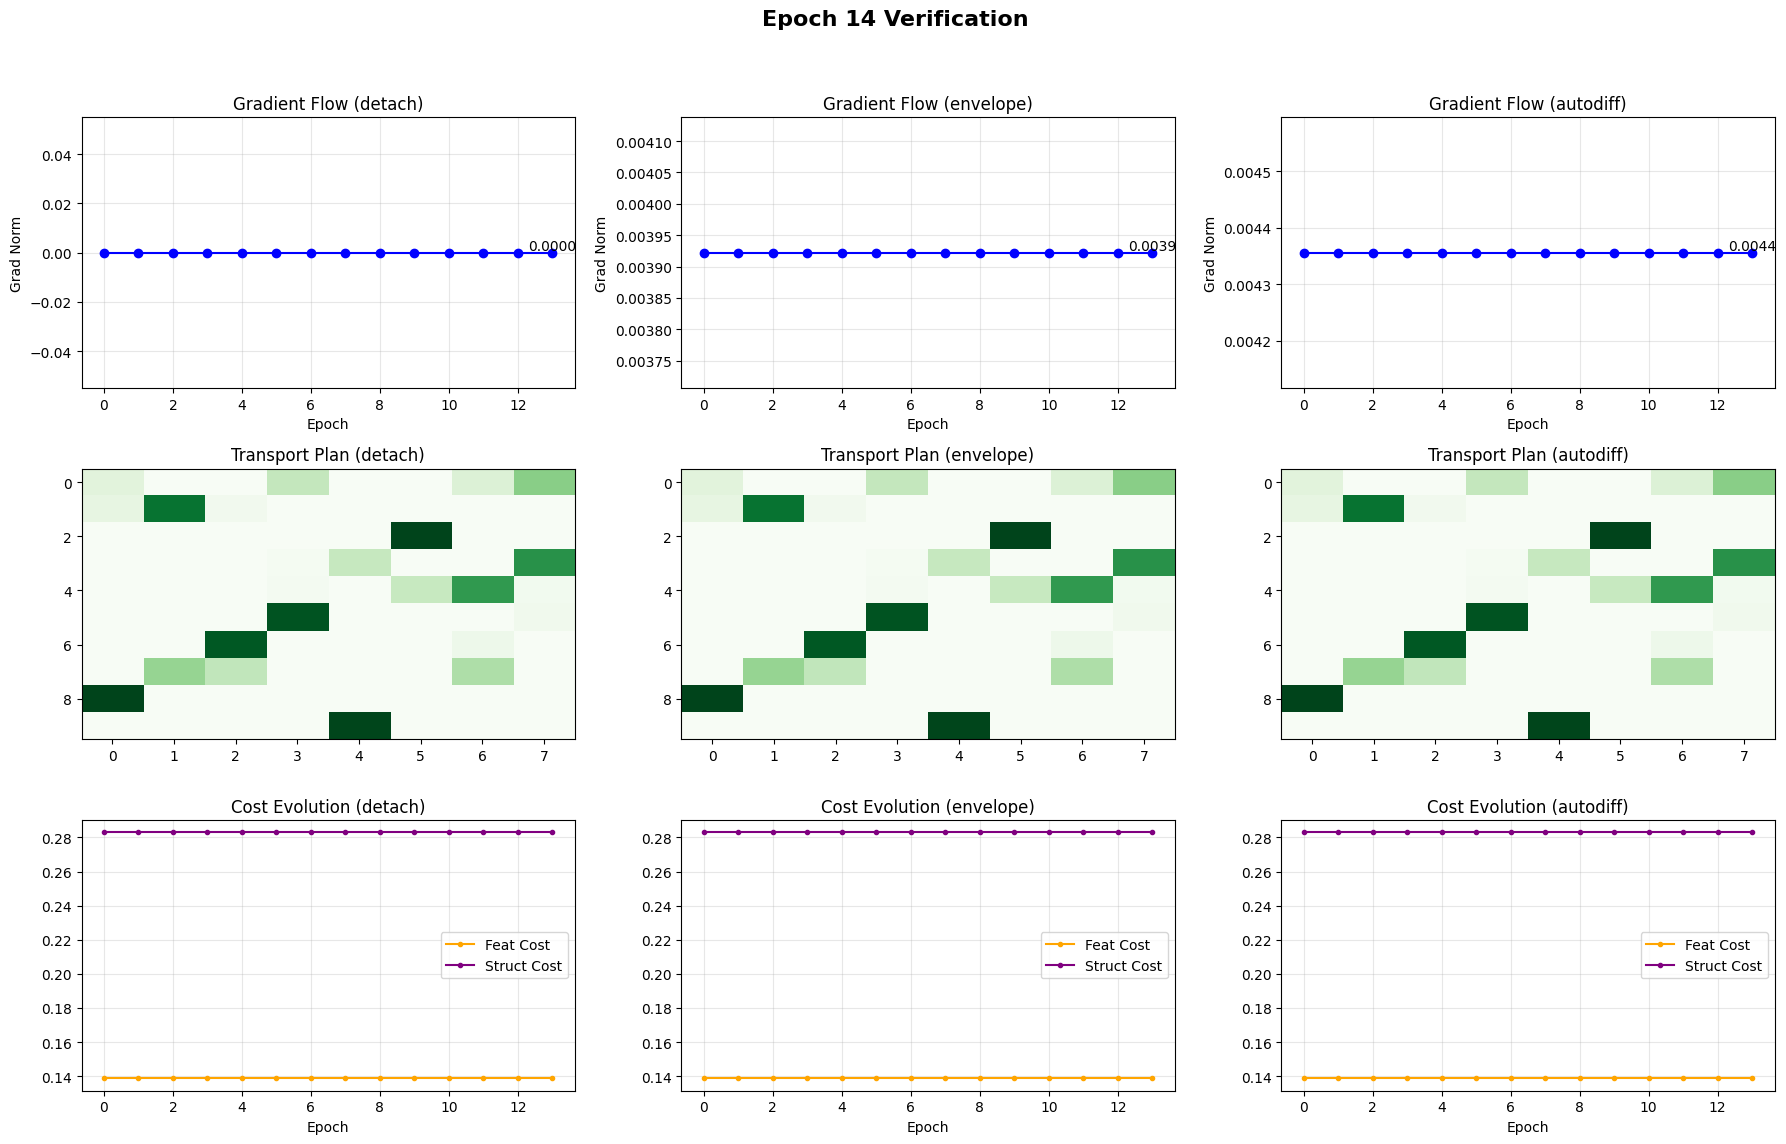

Epoch 14 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


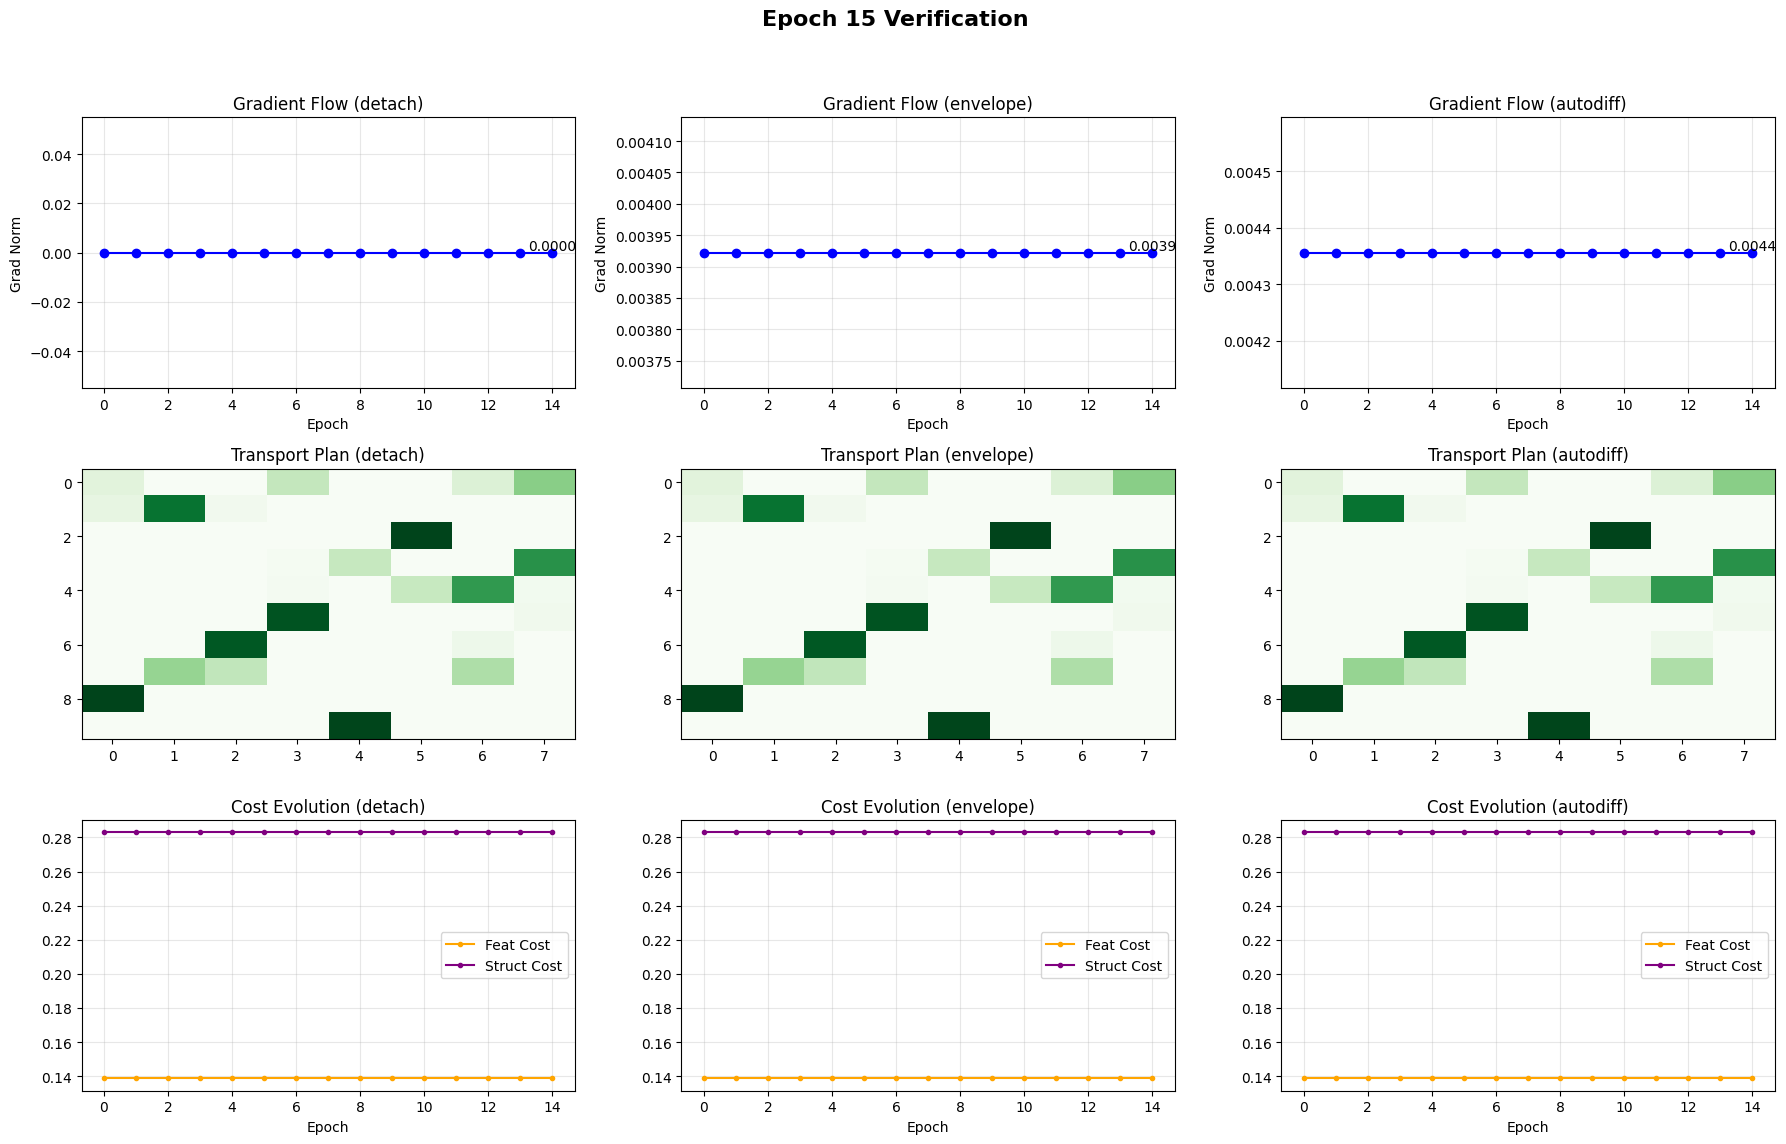

Epoch 15 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


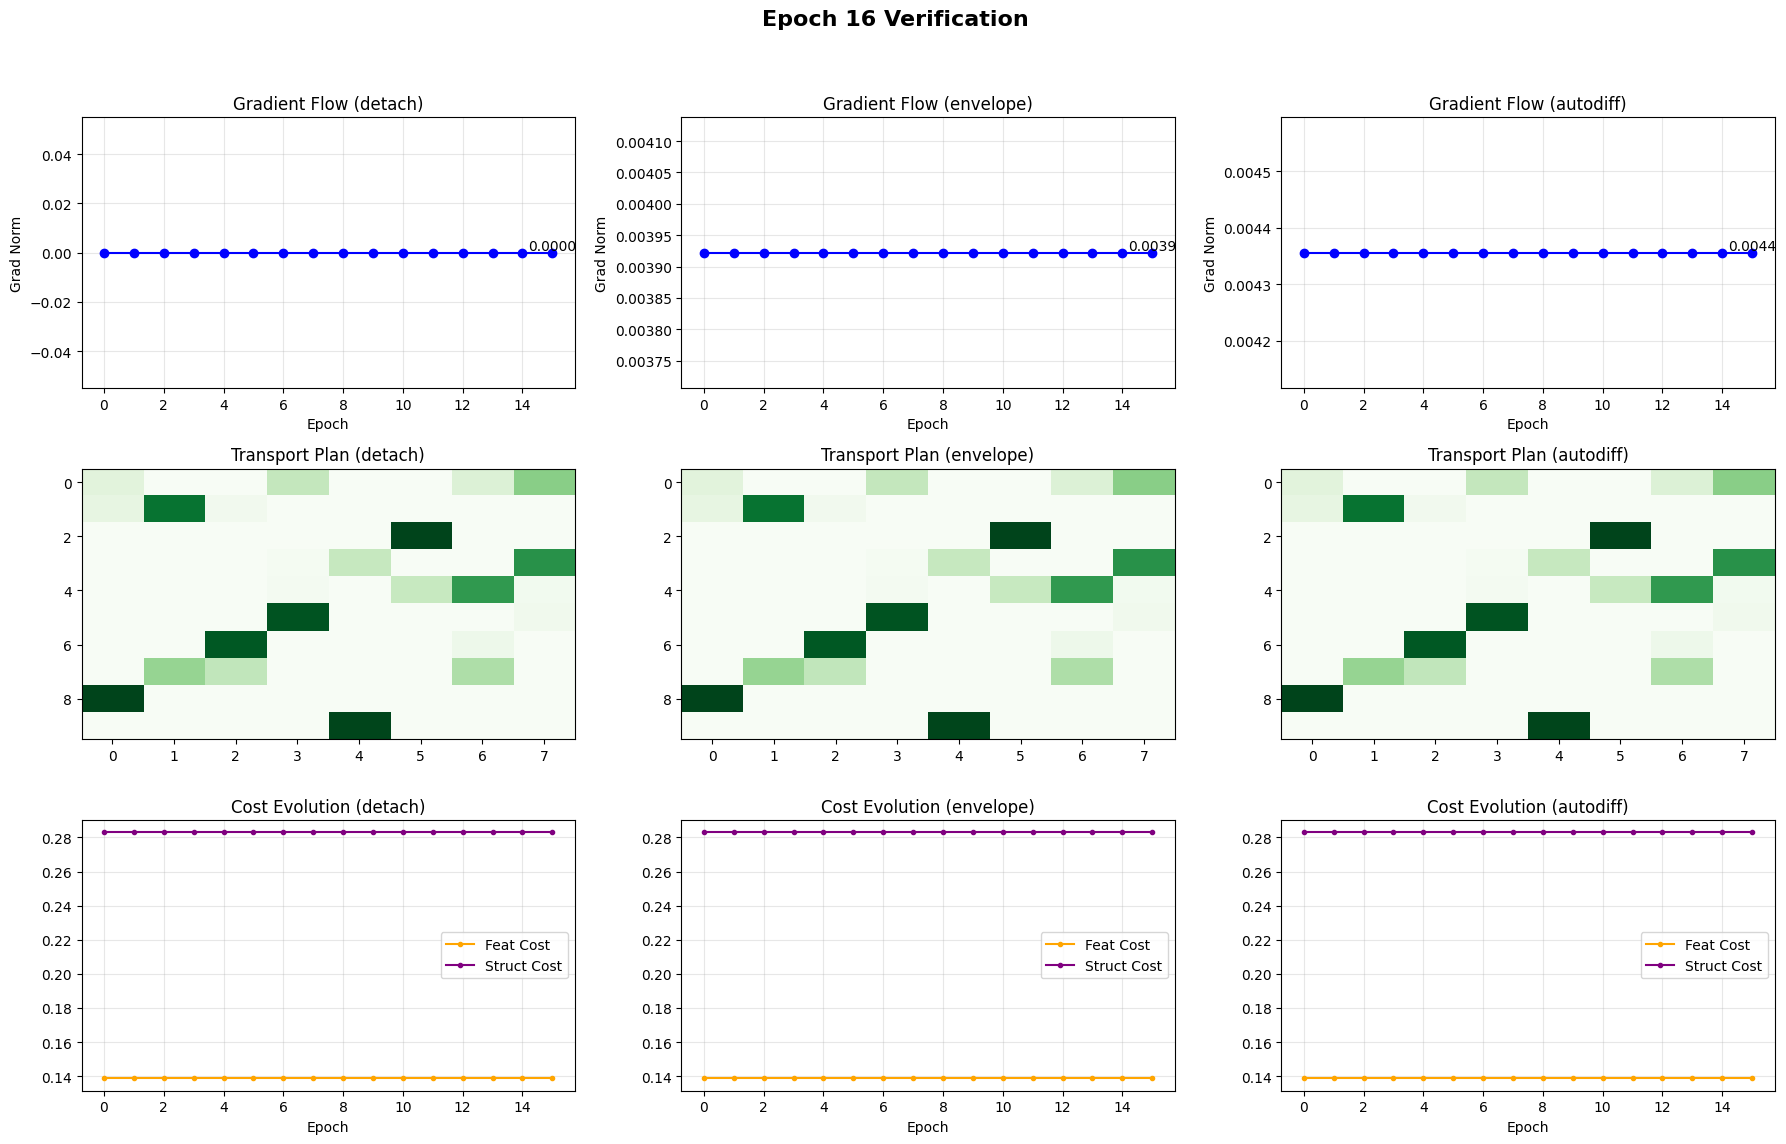

Epoch 16 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


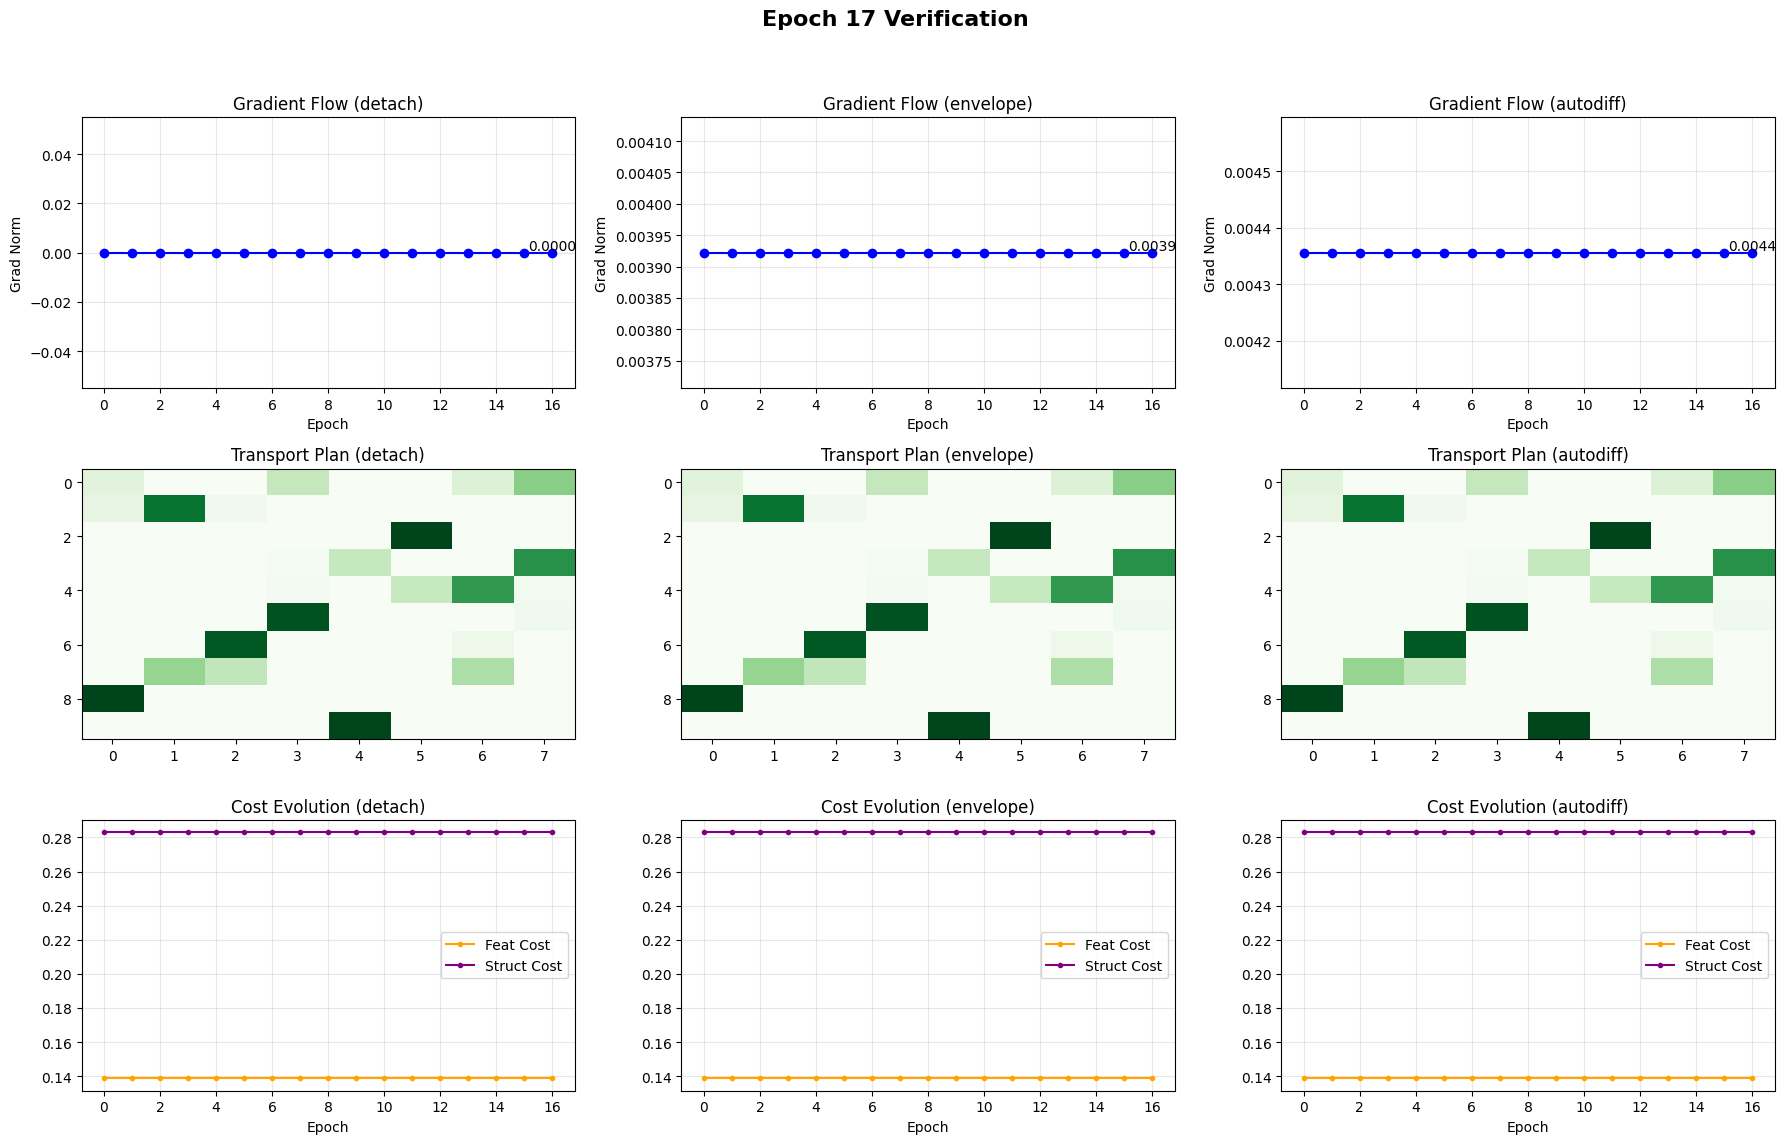

Epoch 17 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


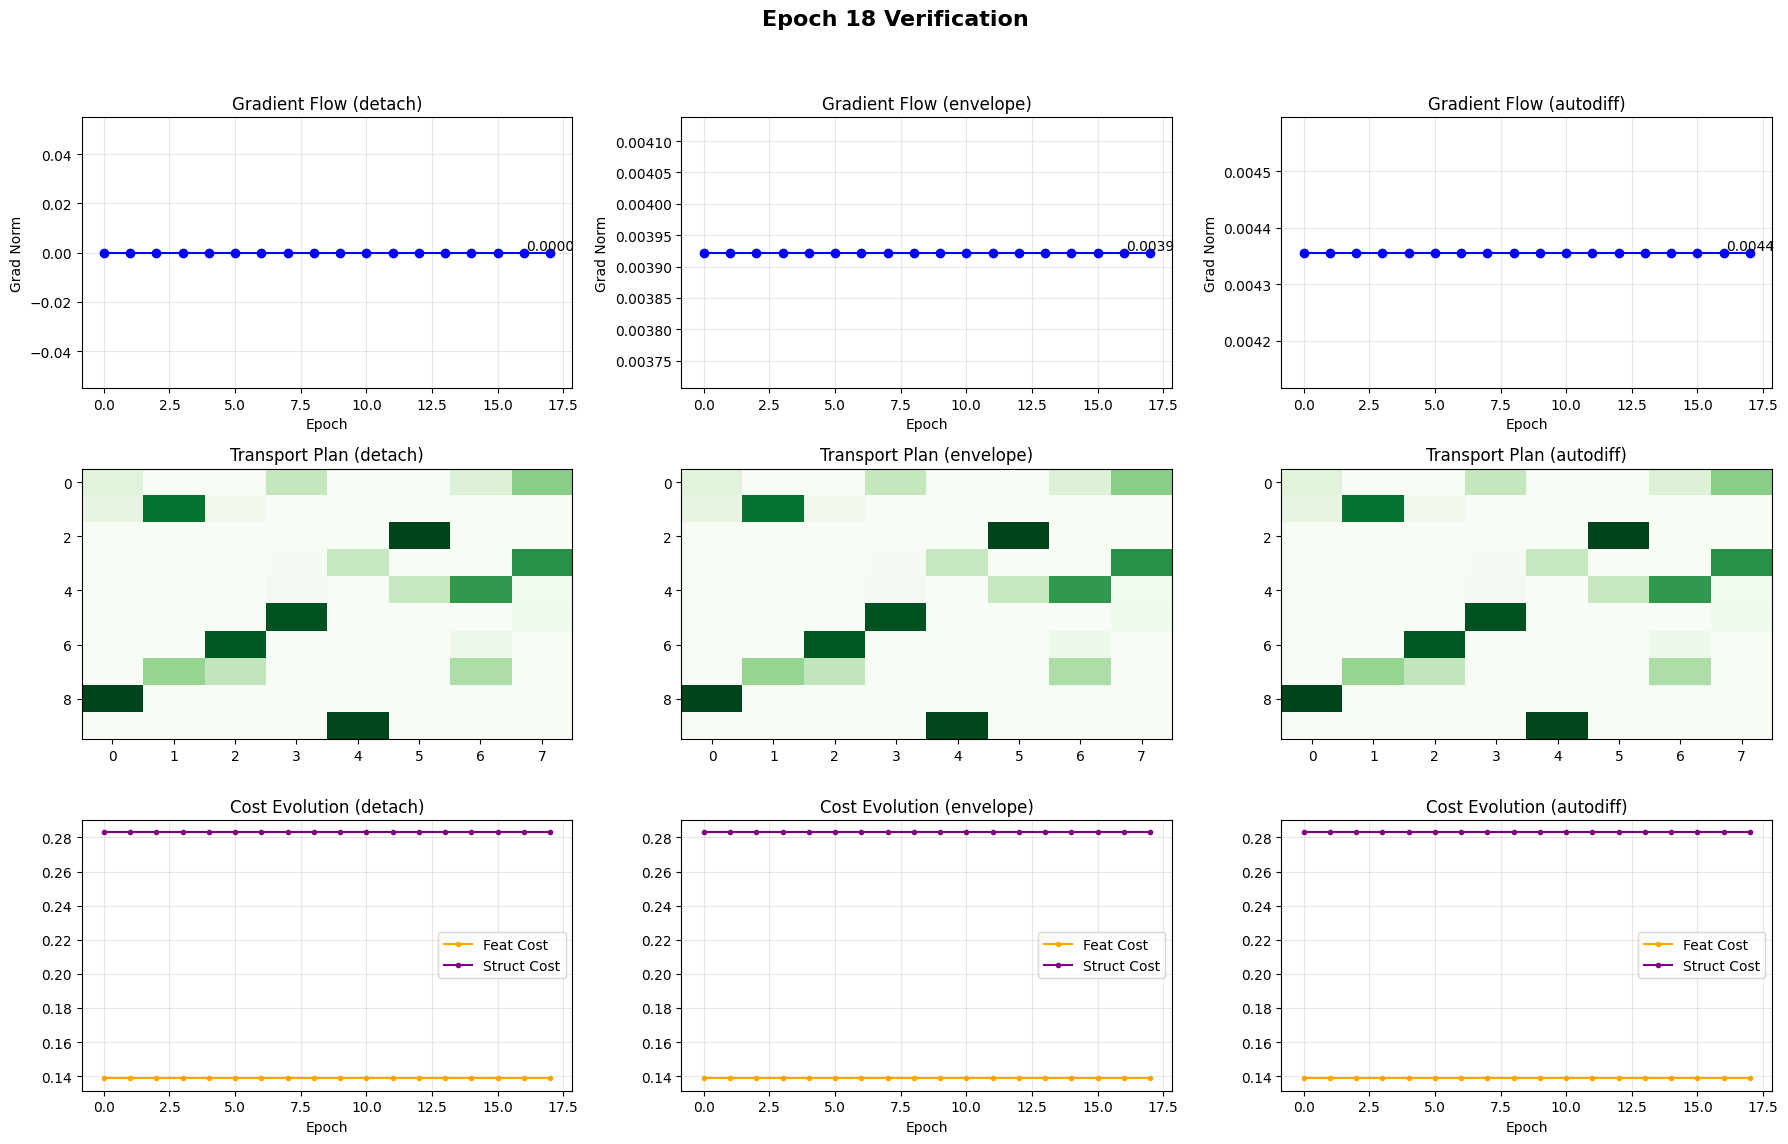

Epoch 18 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


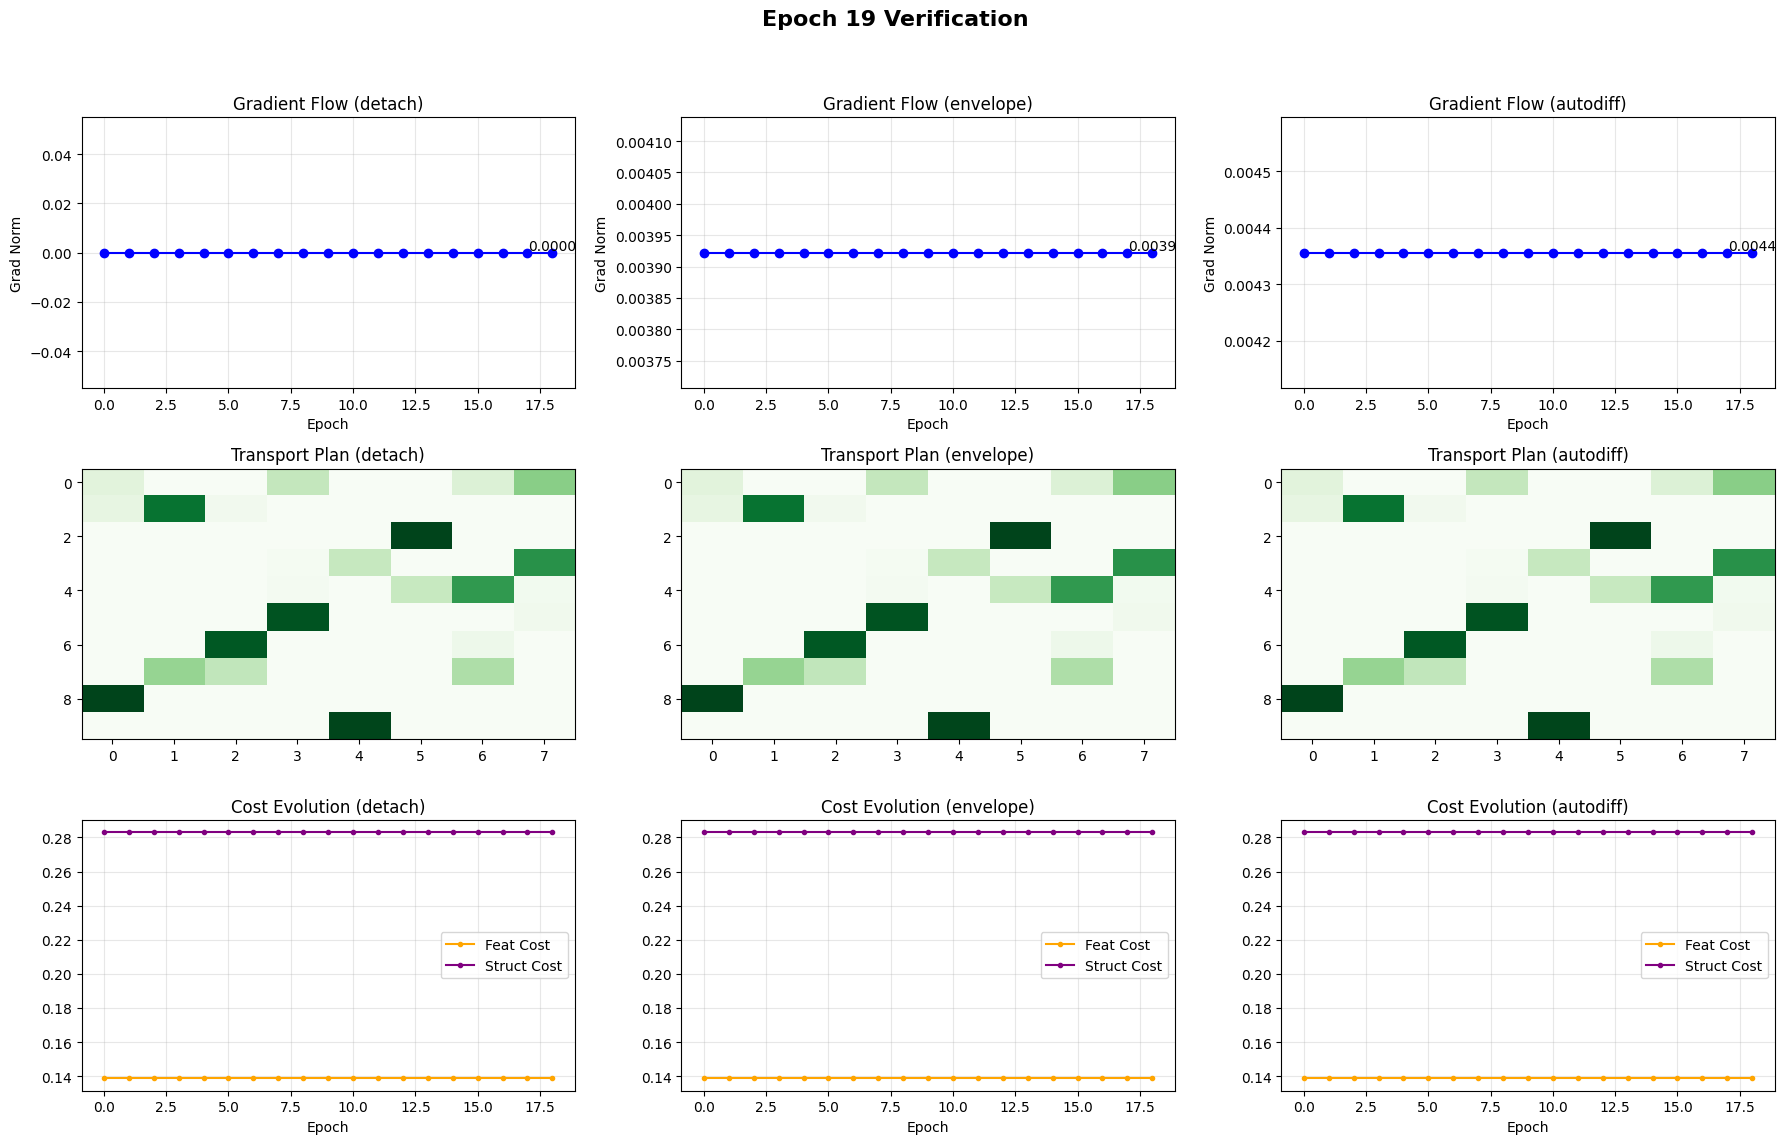

Epoch 19 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


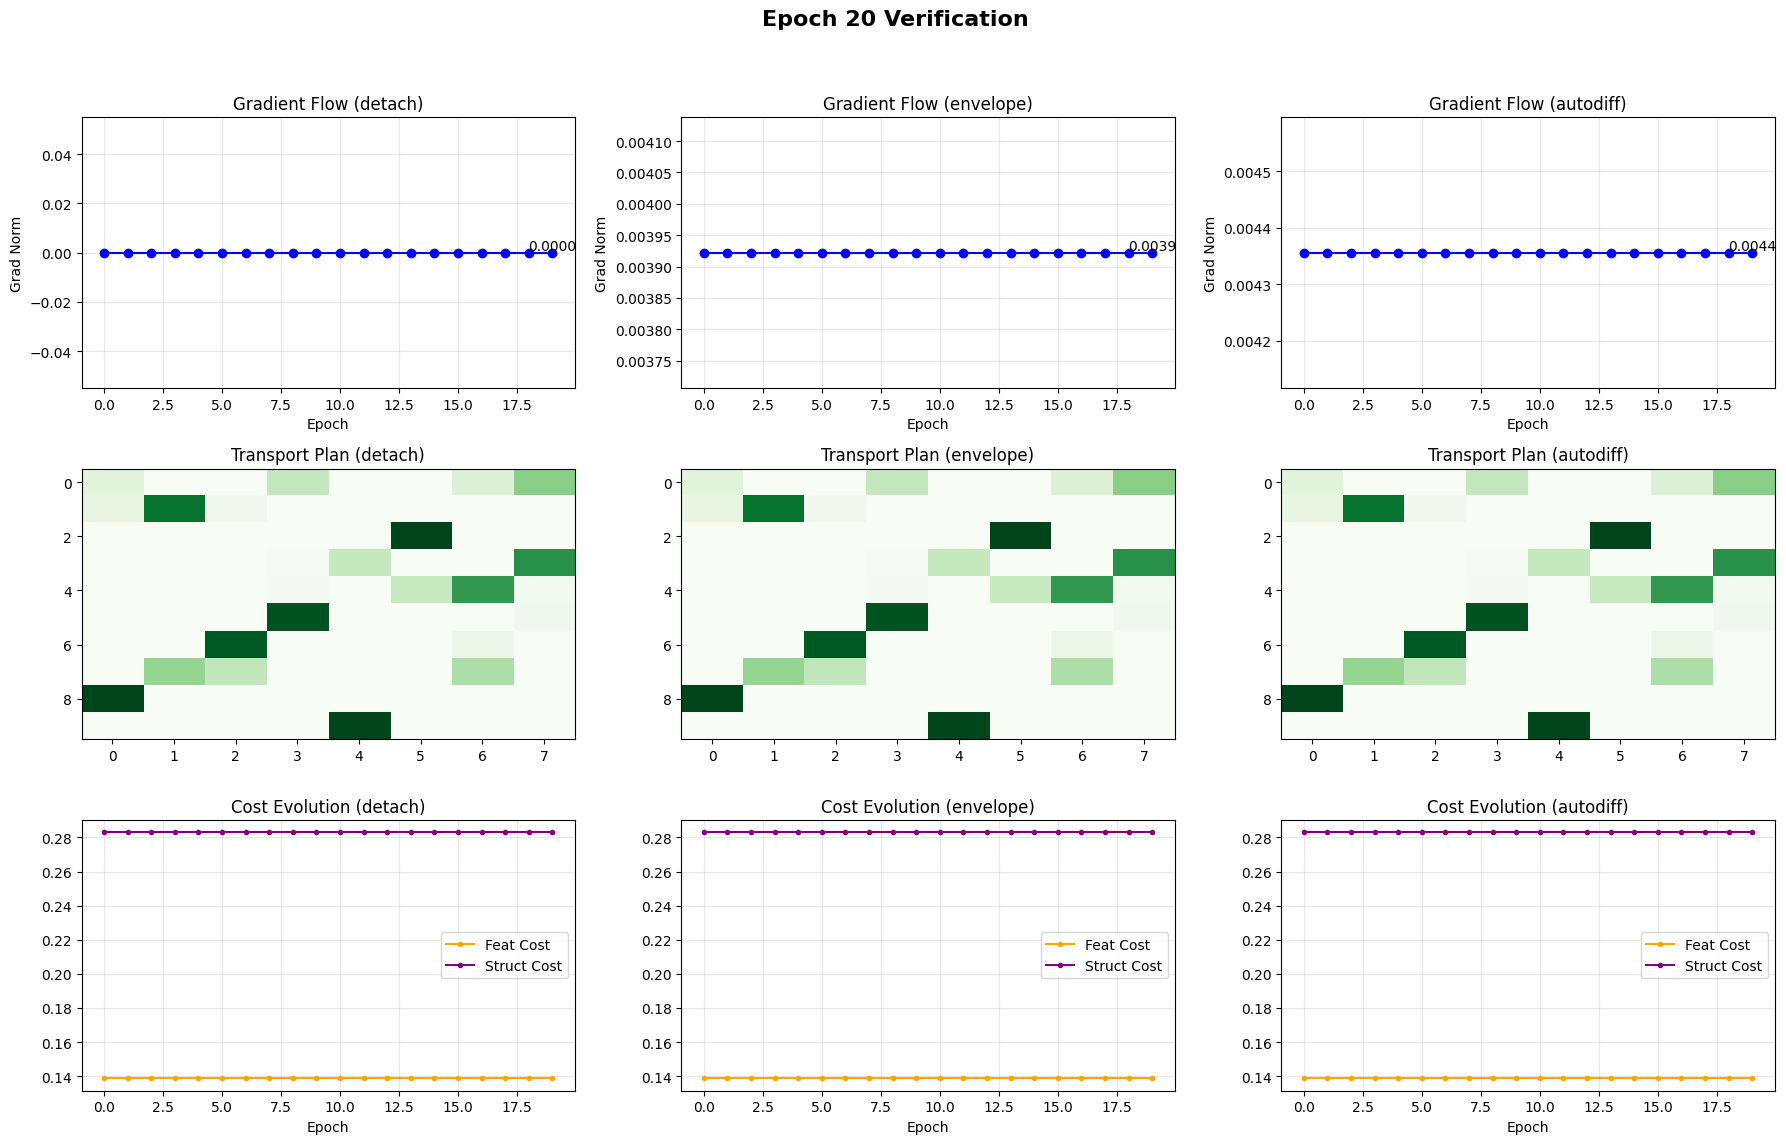

Epoch 20 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


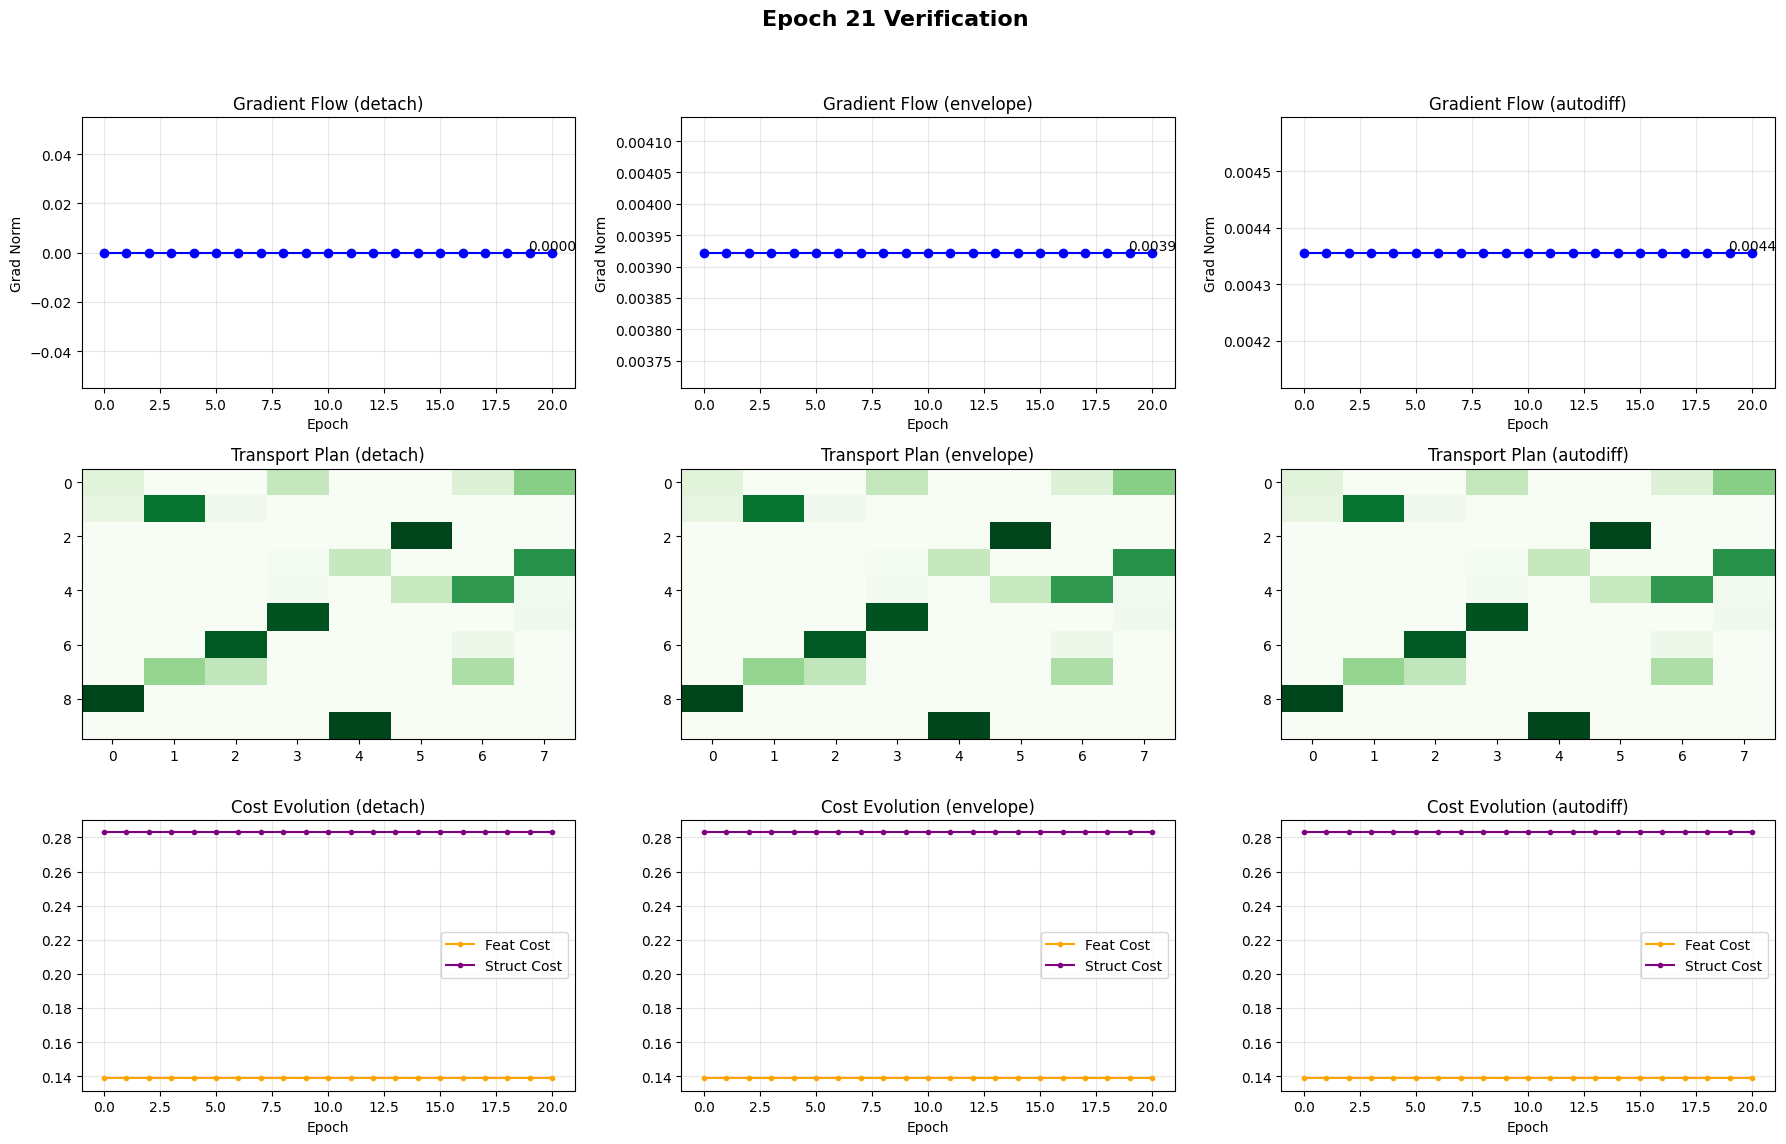

Epoch 21 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


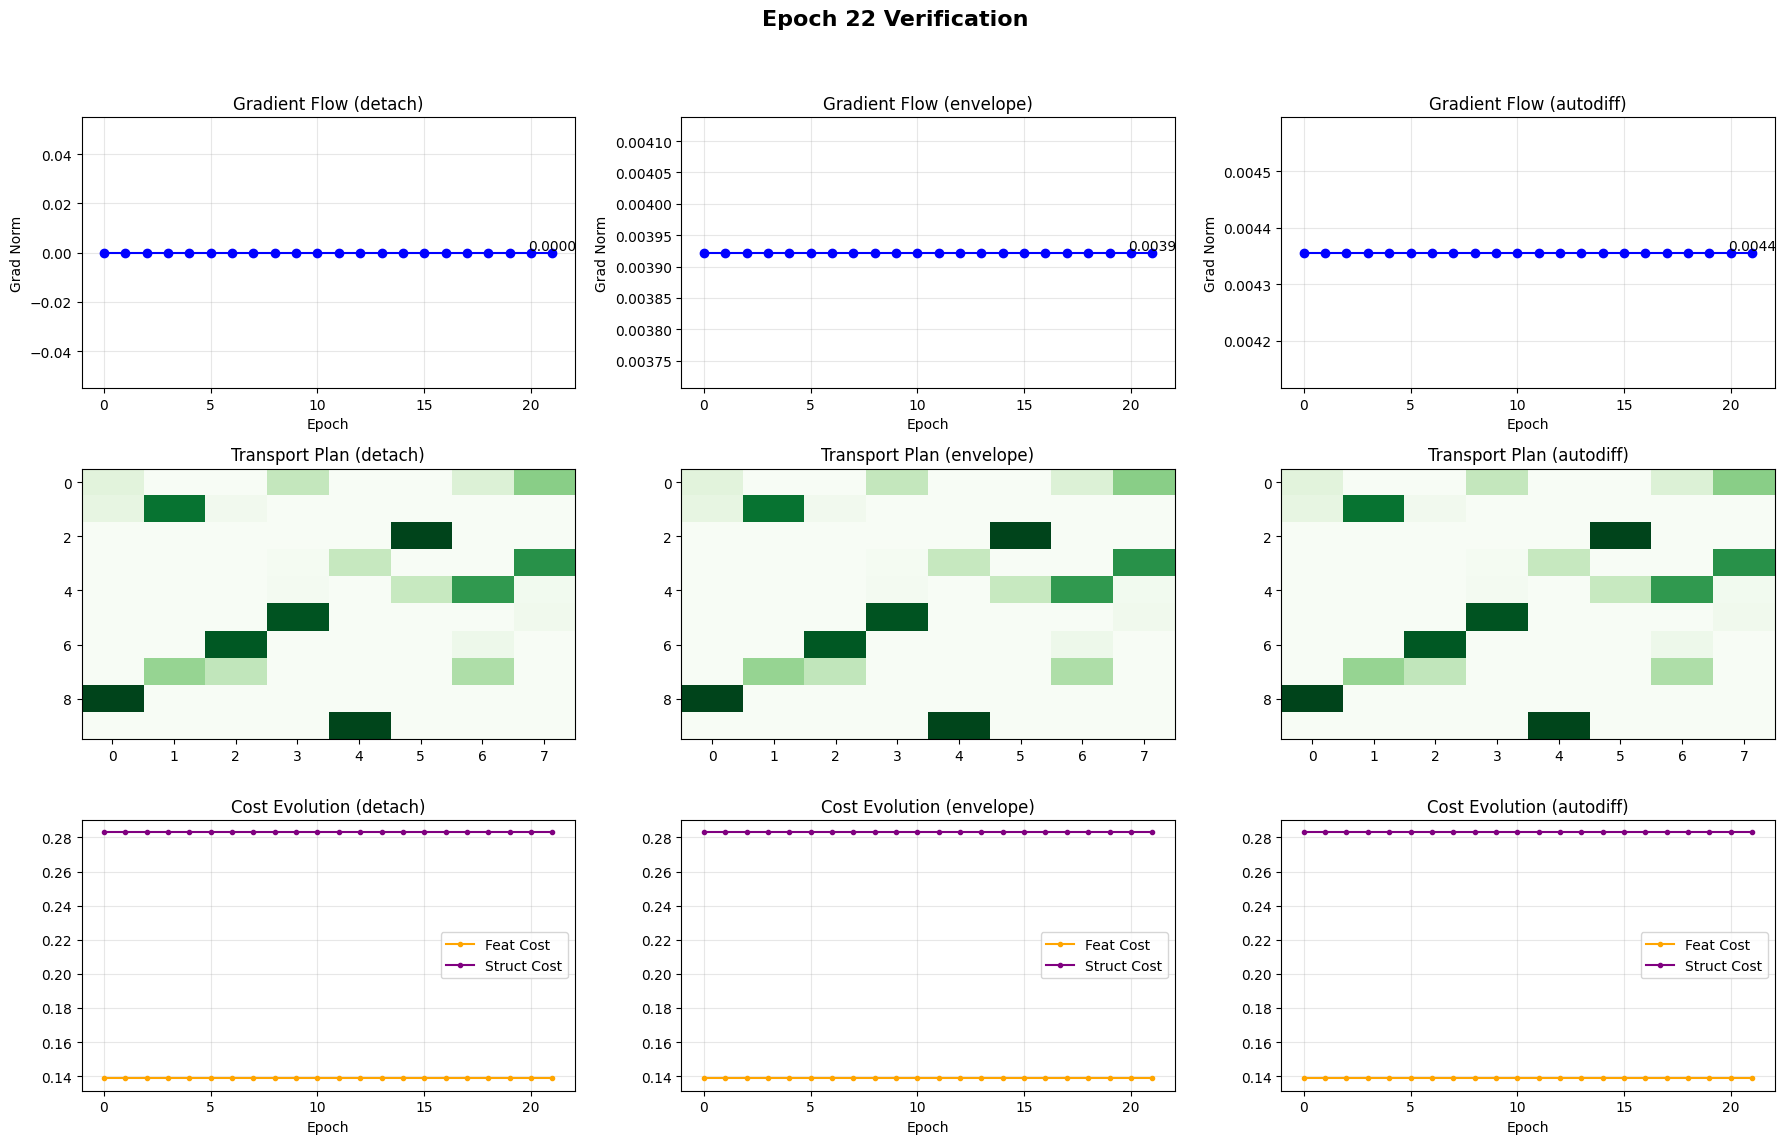

Epoch 22 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


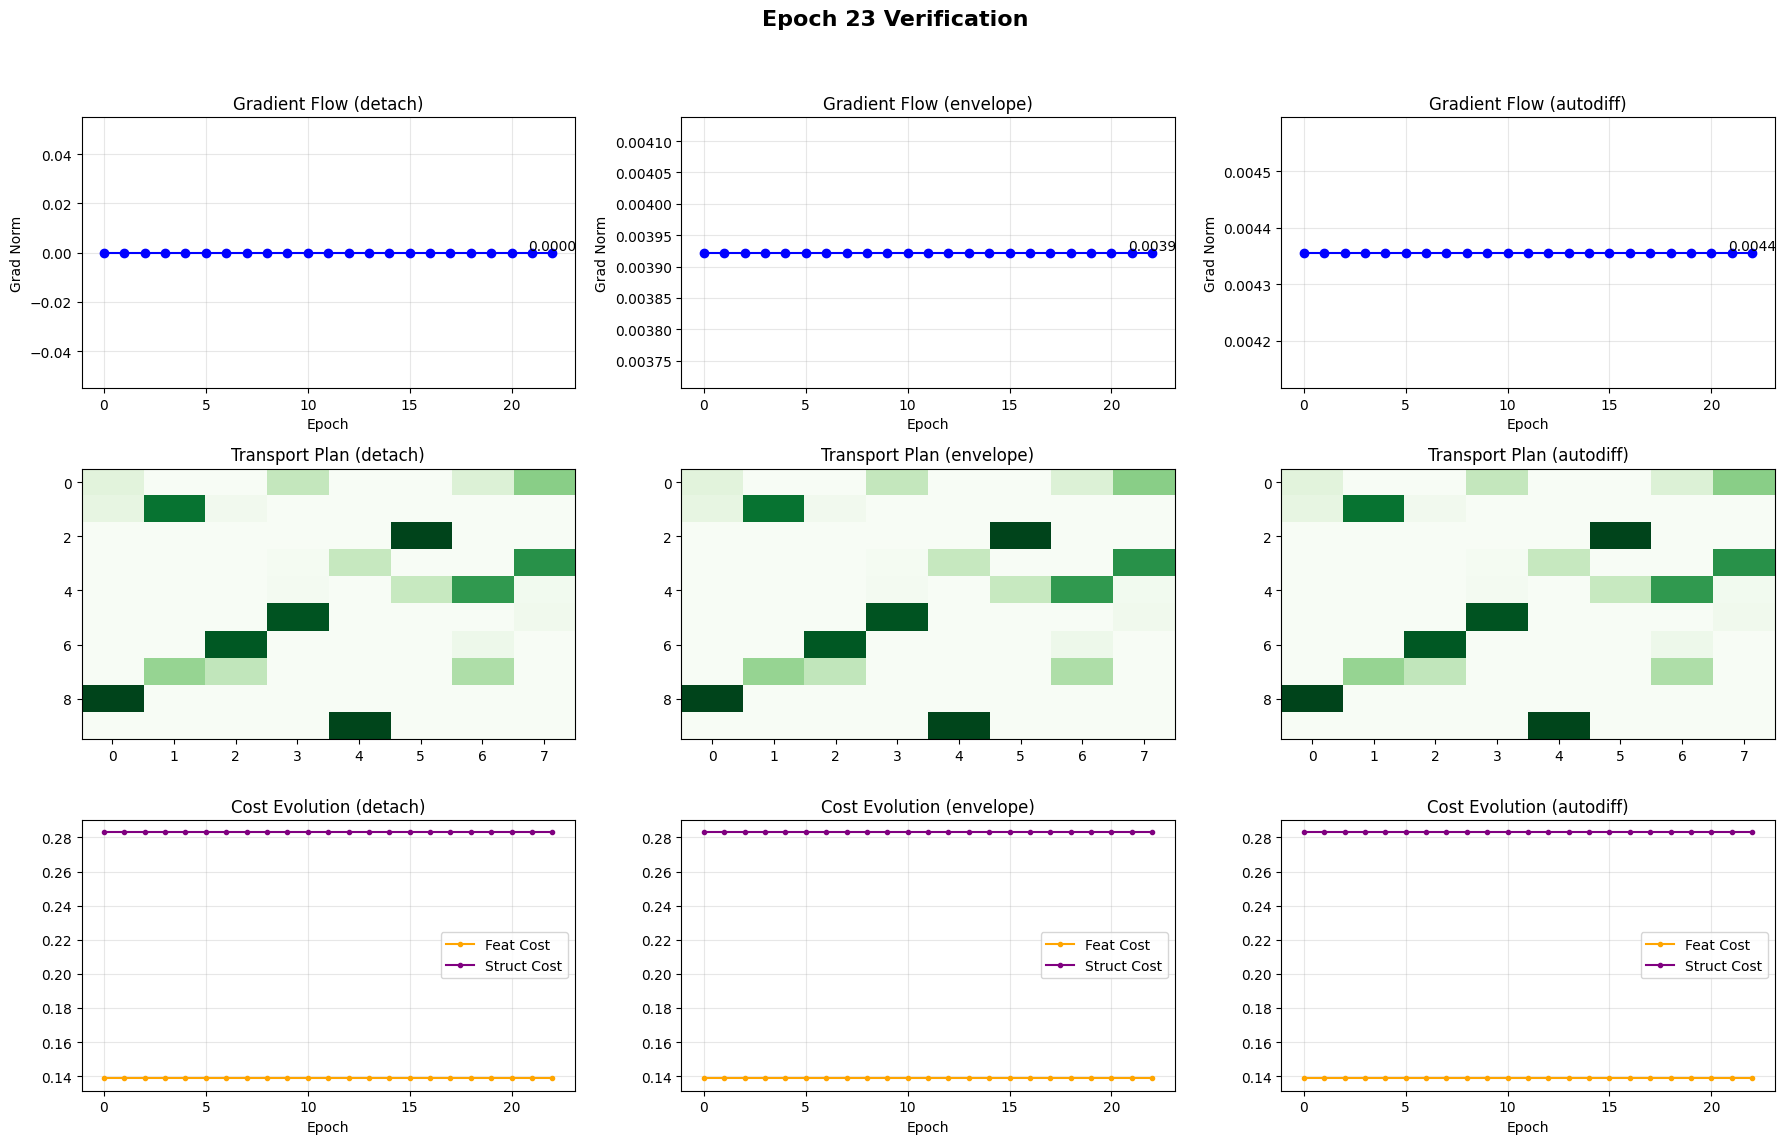

Epoch 23 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


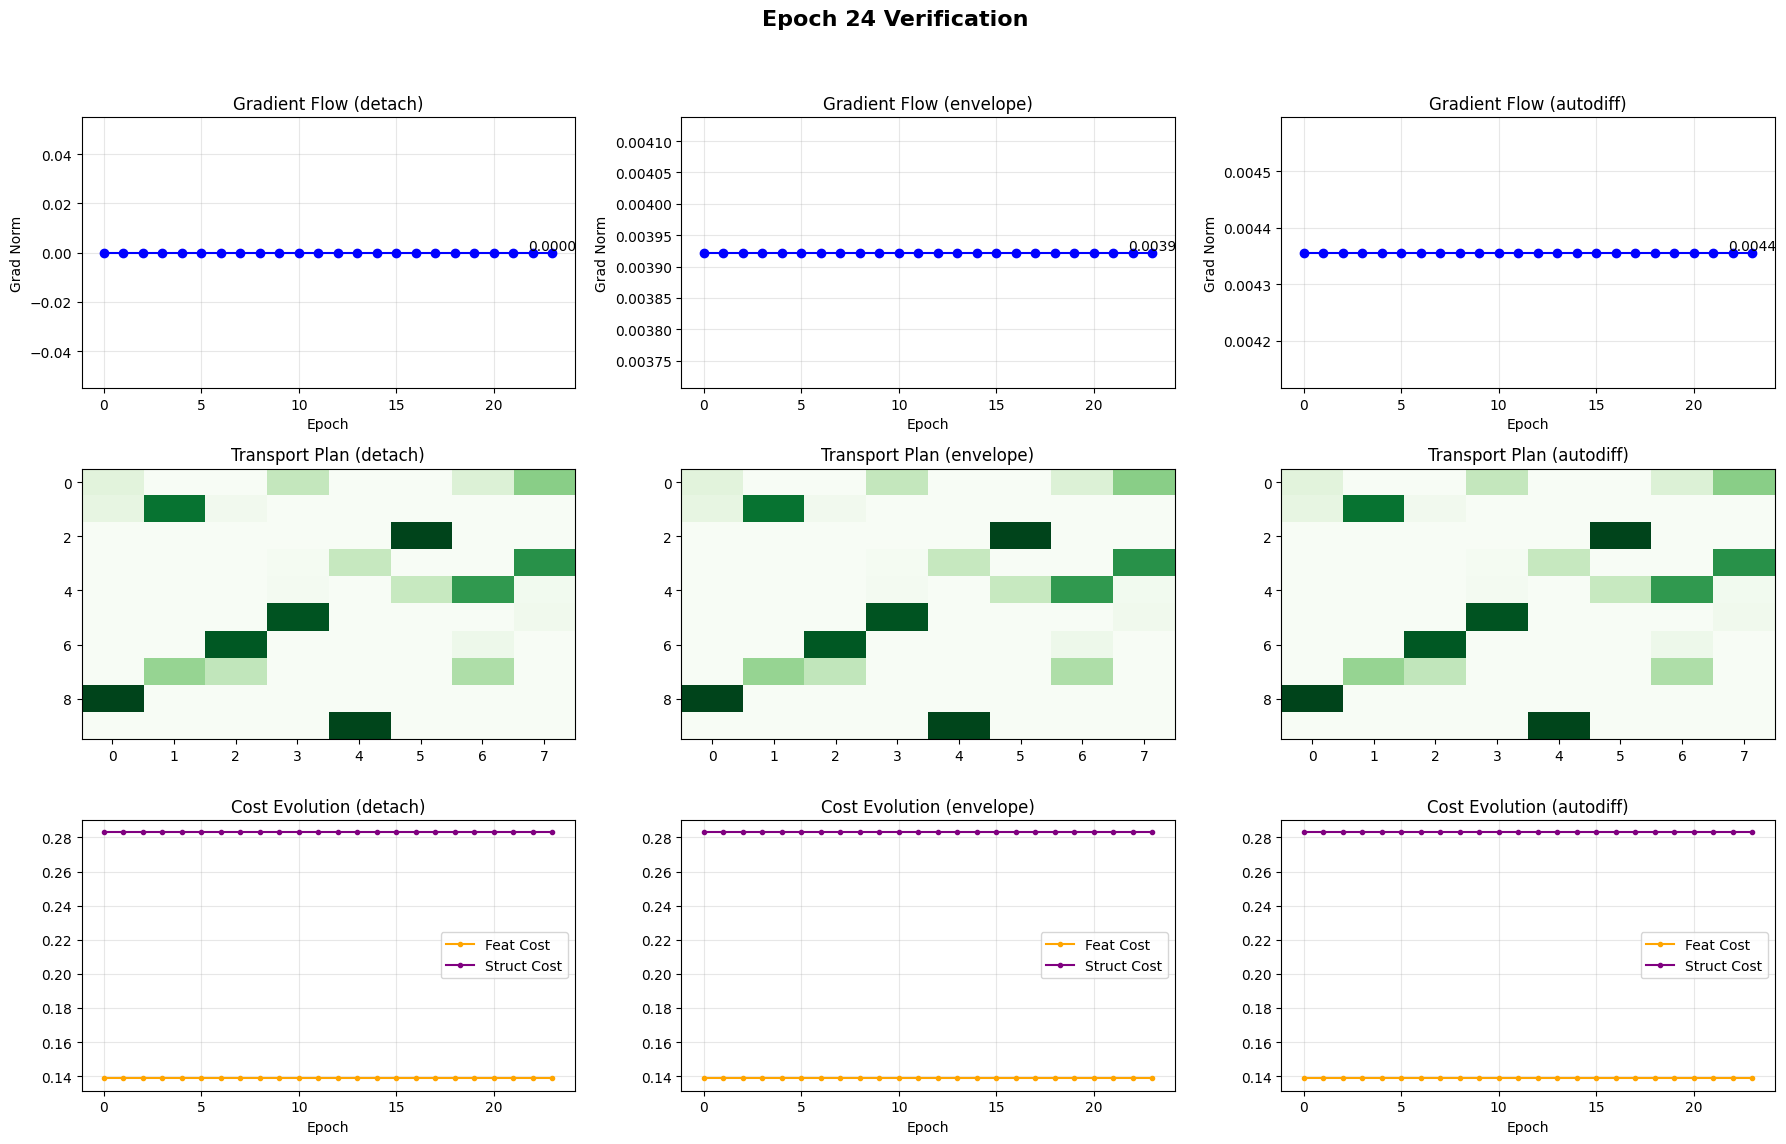

Epoch 24 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


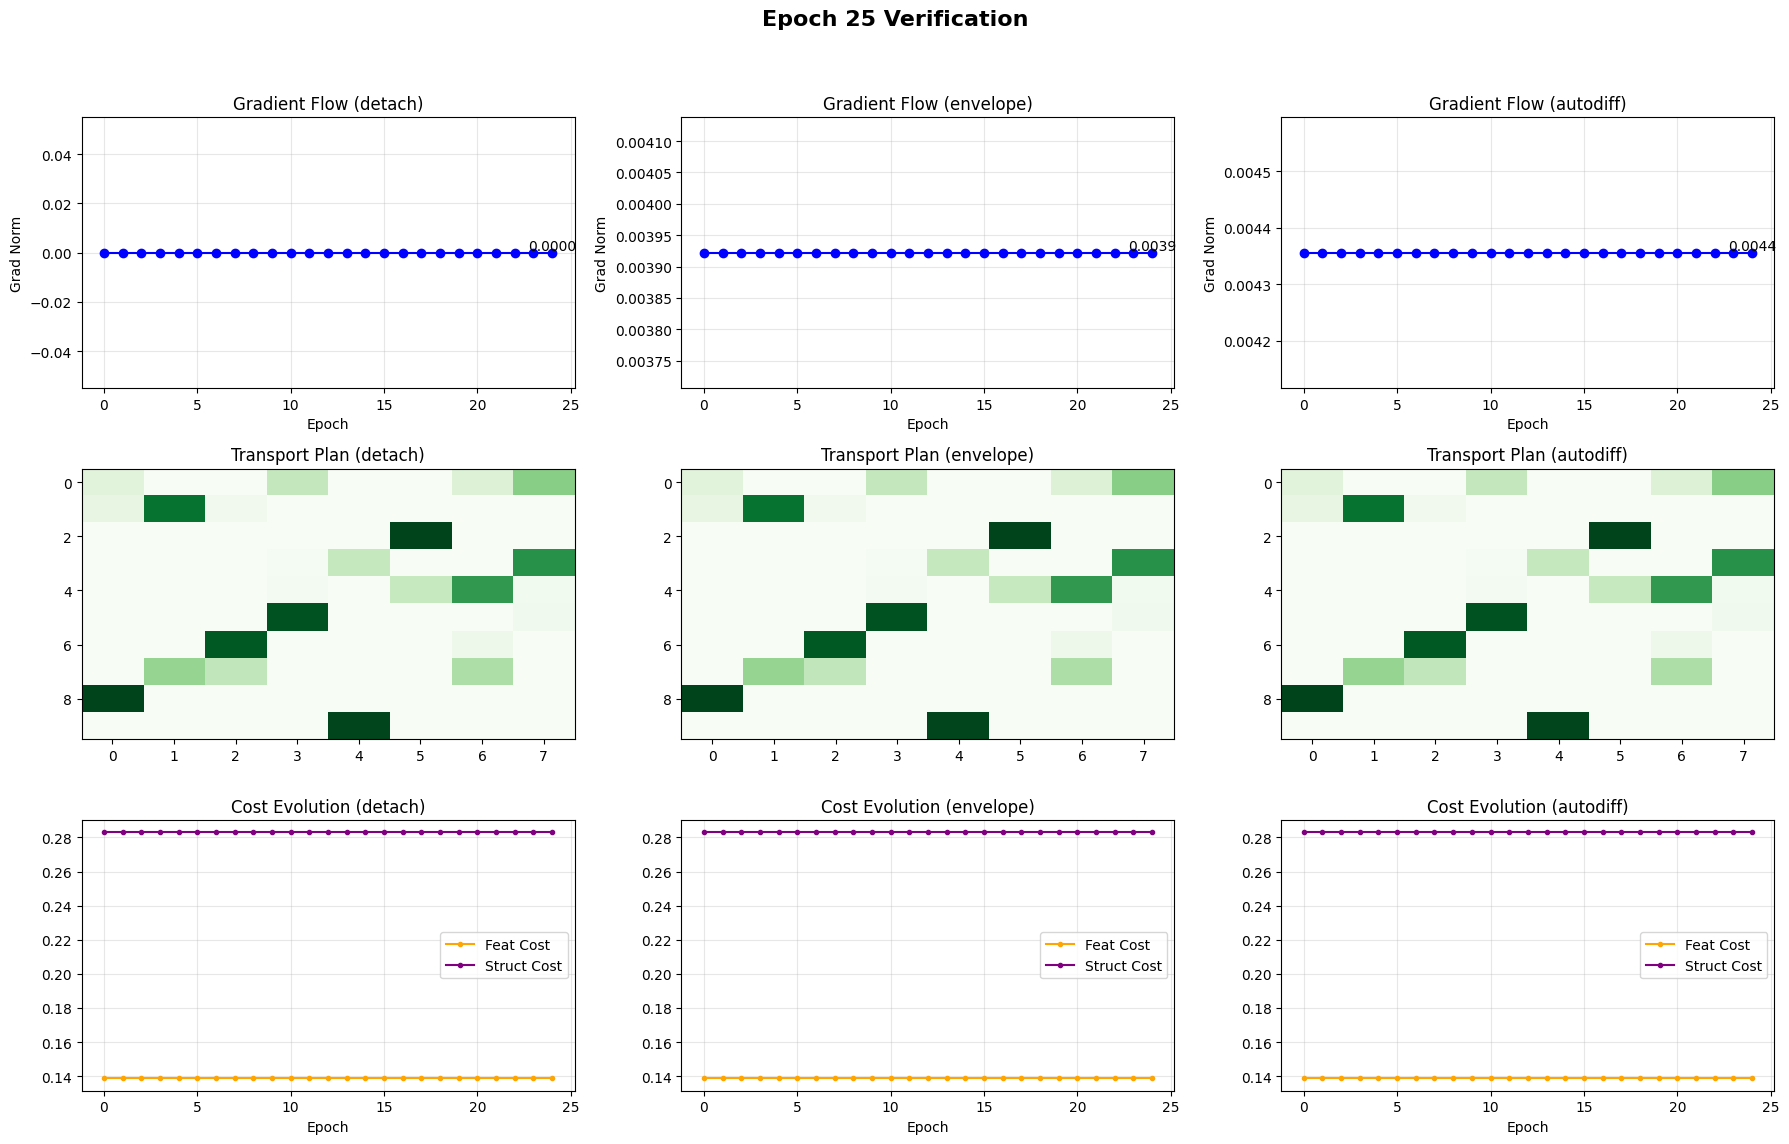

Epoch 25 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


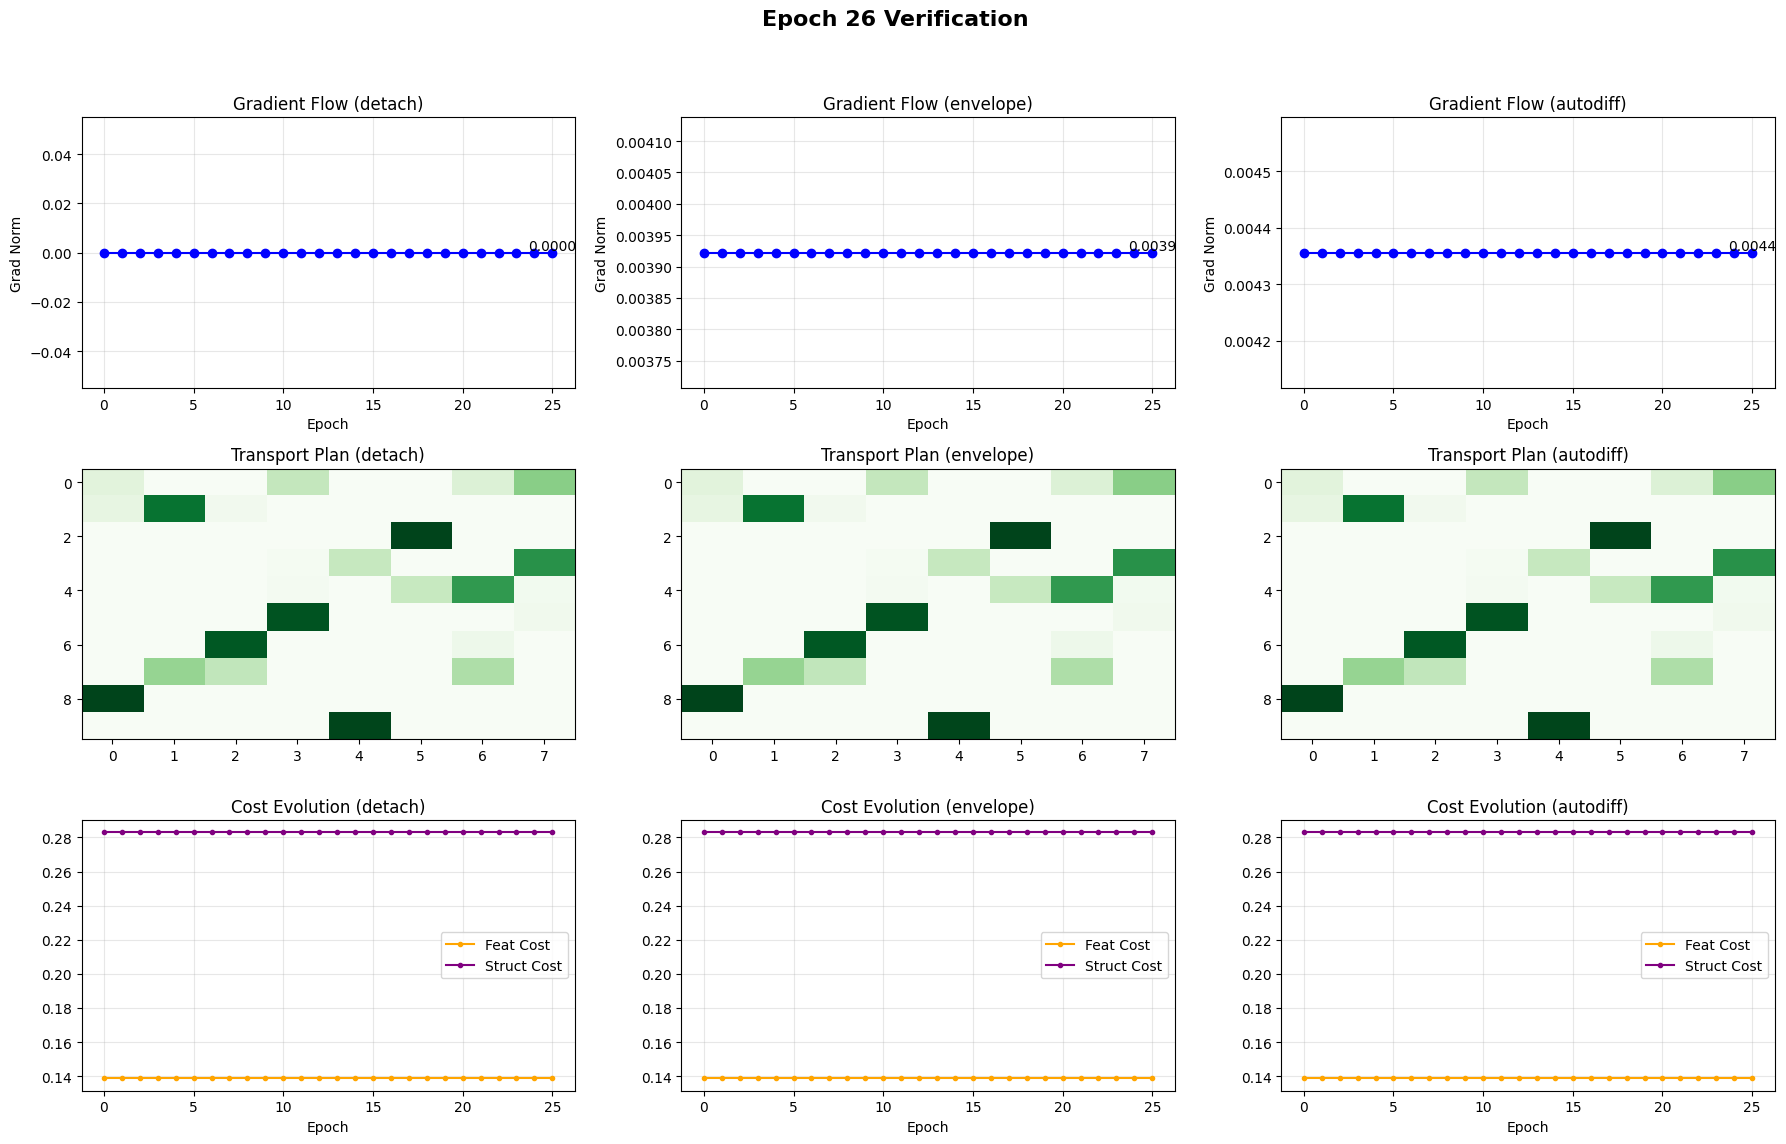

Epoch 26 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


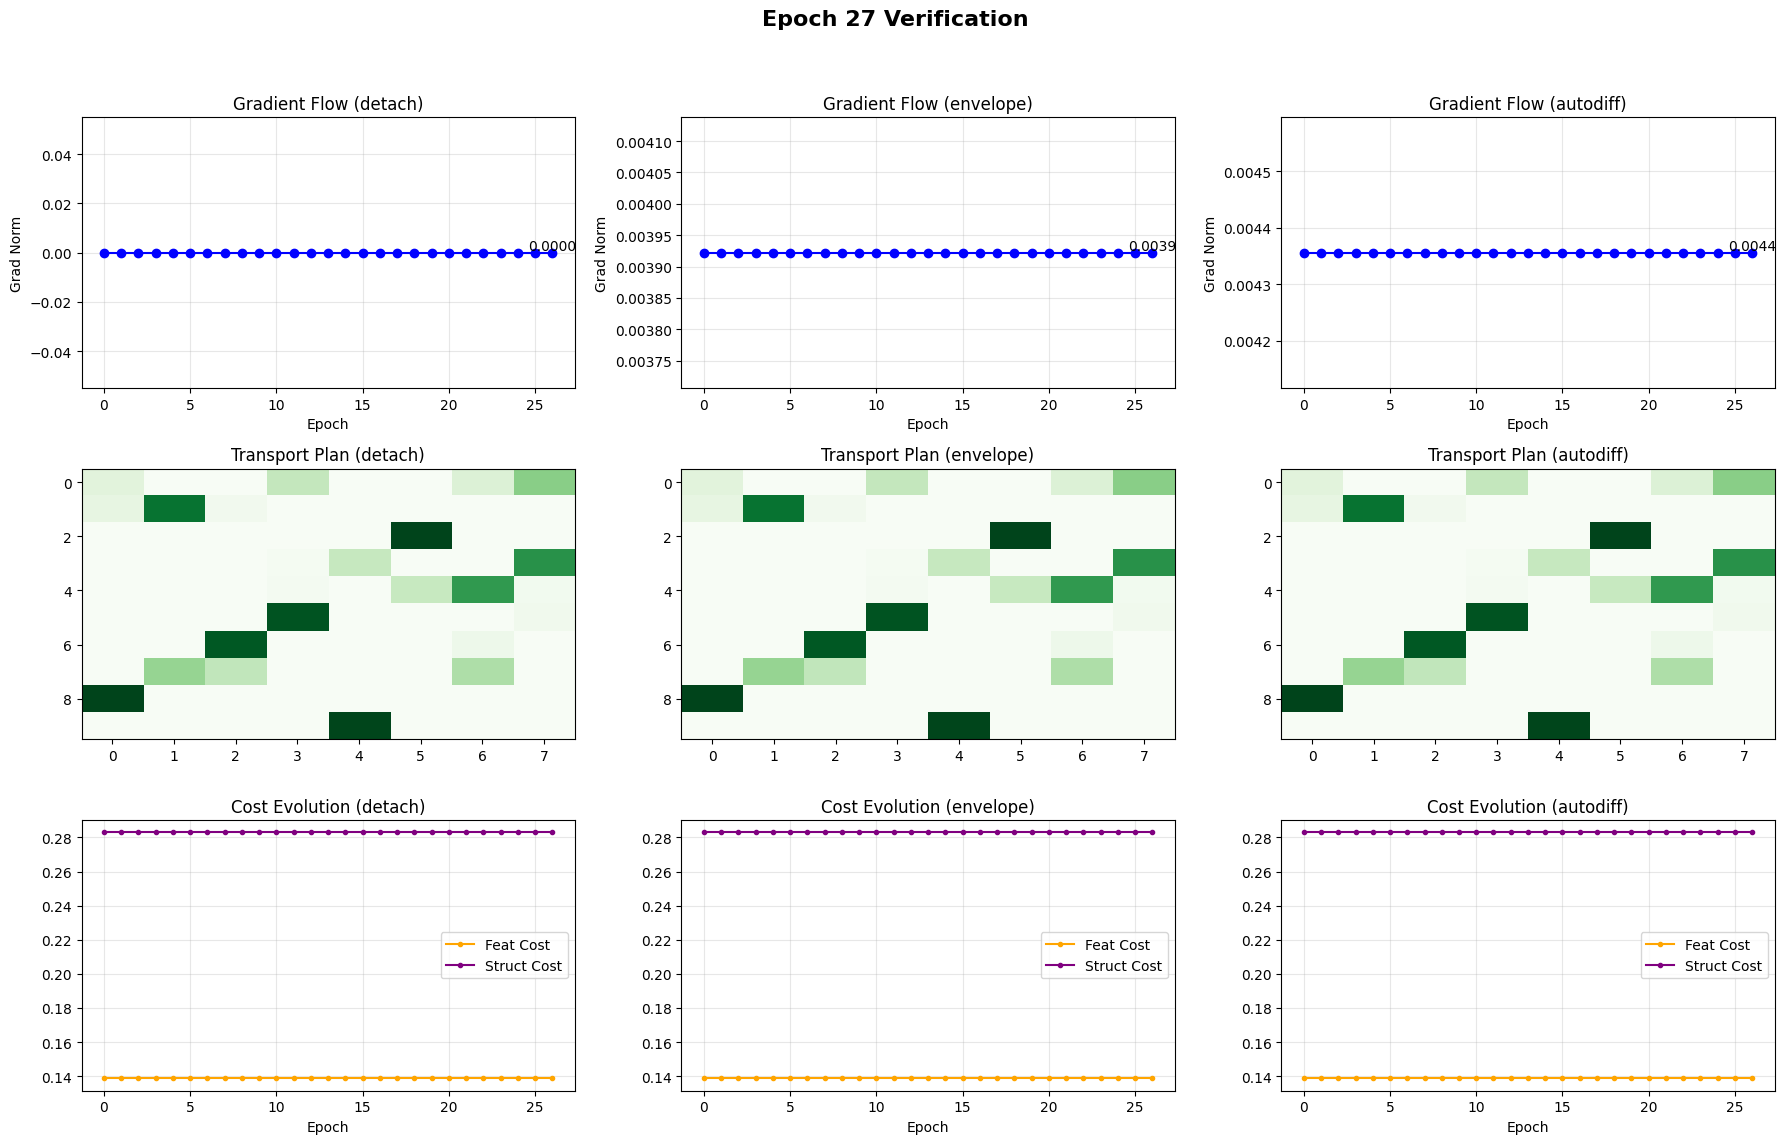

Epoch 27 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


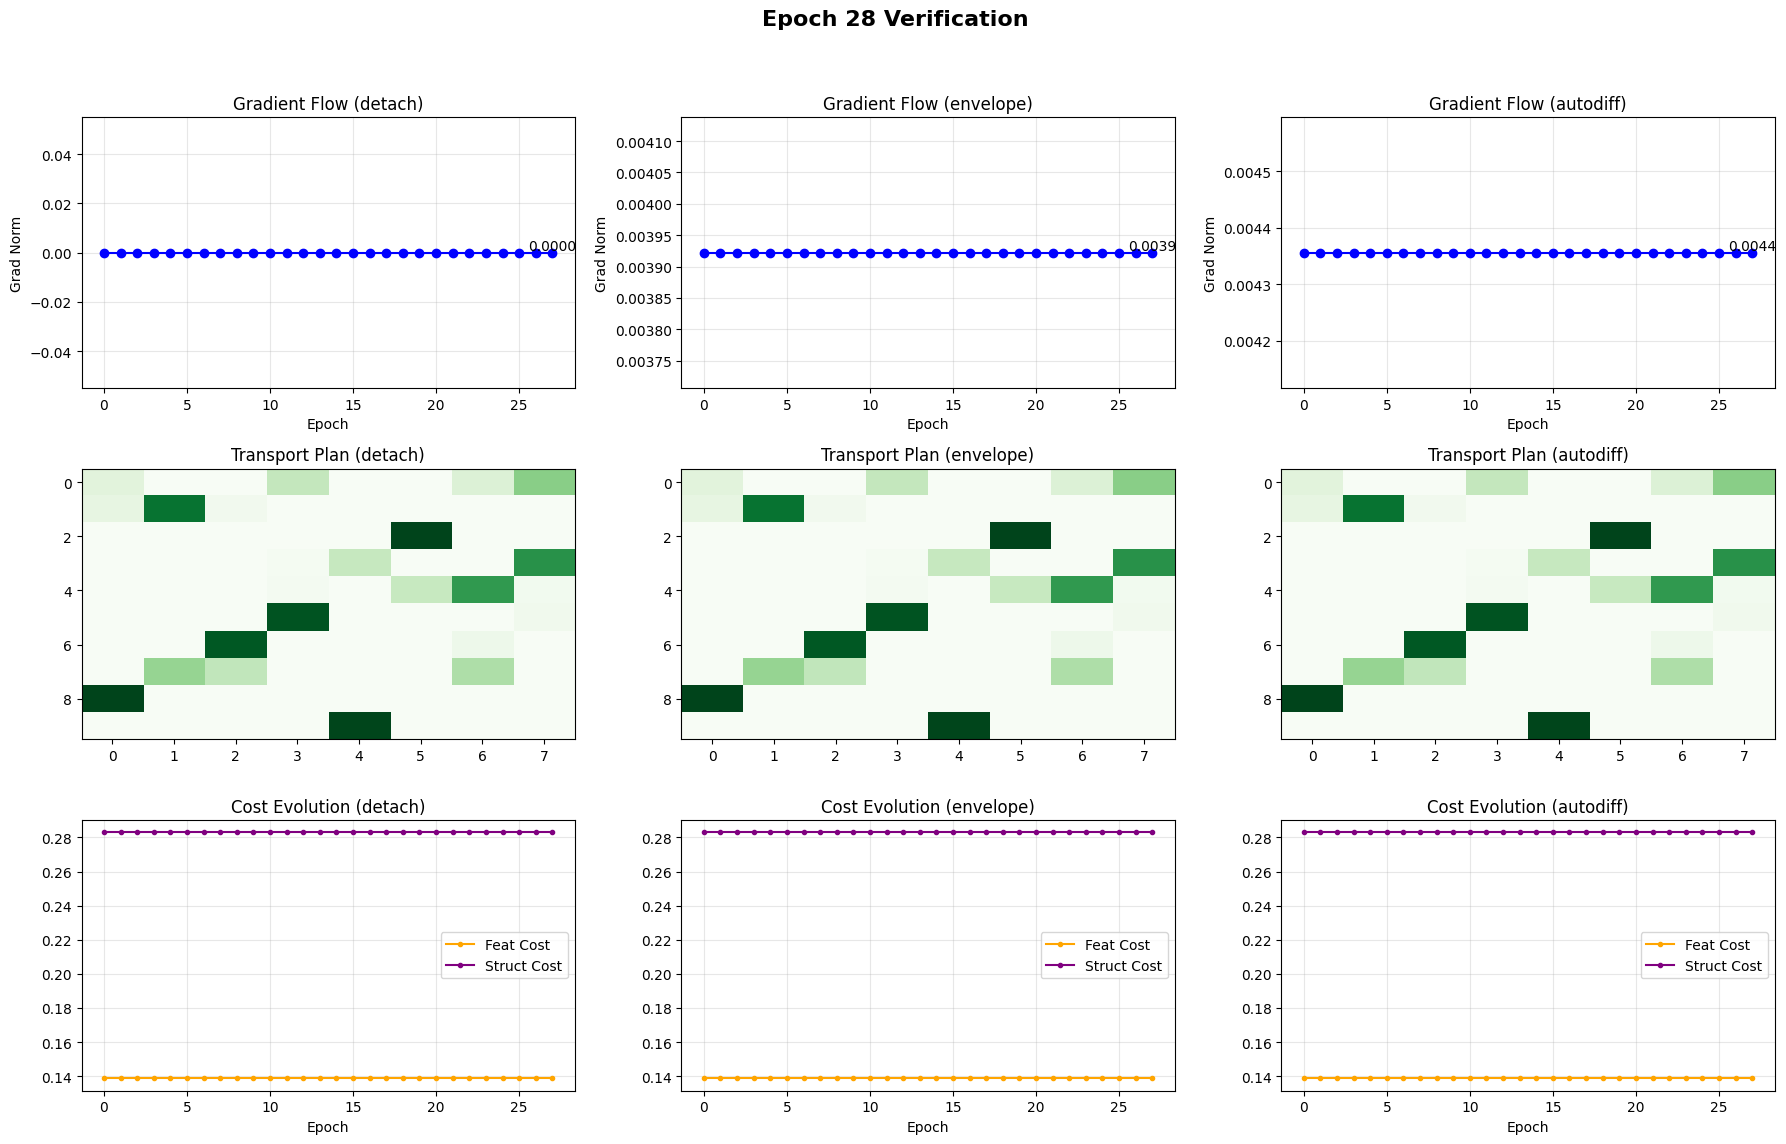

Epoch 28 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


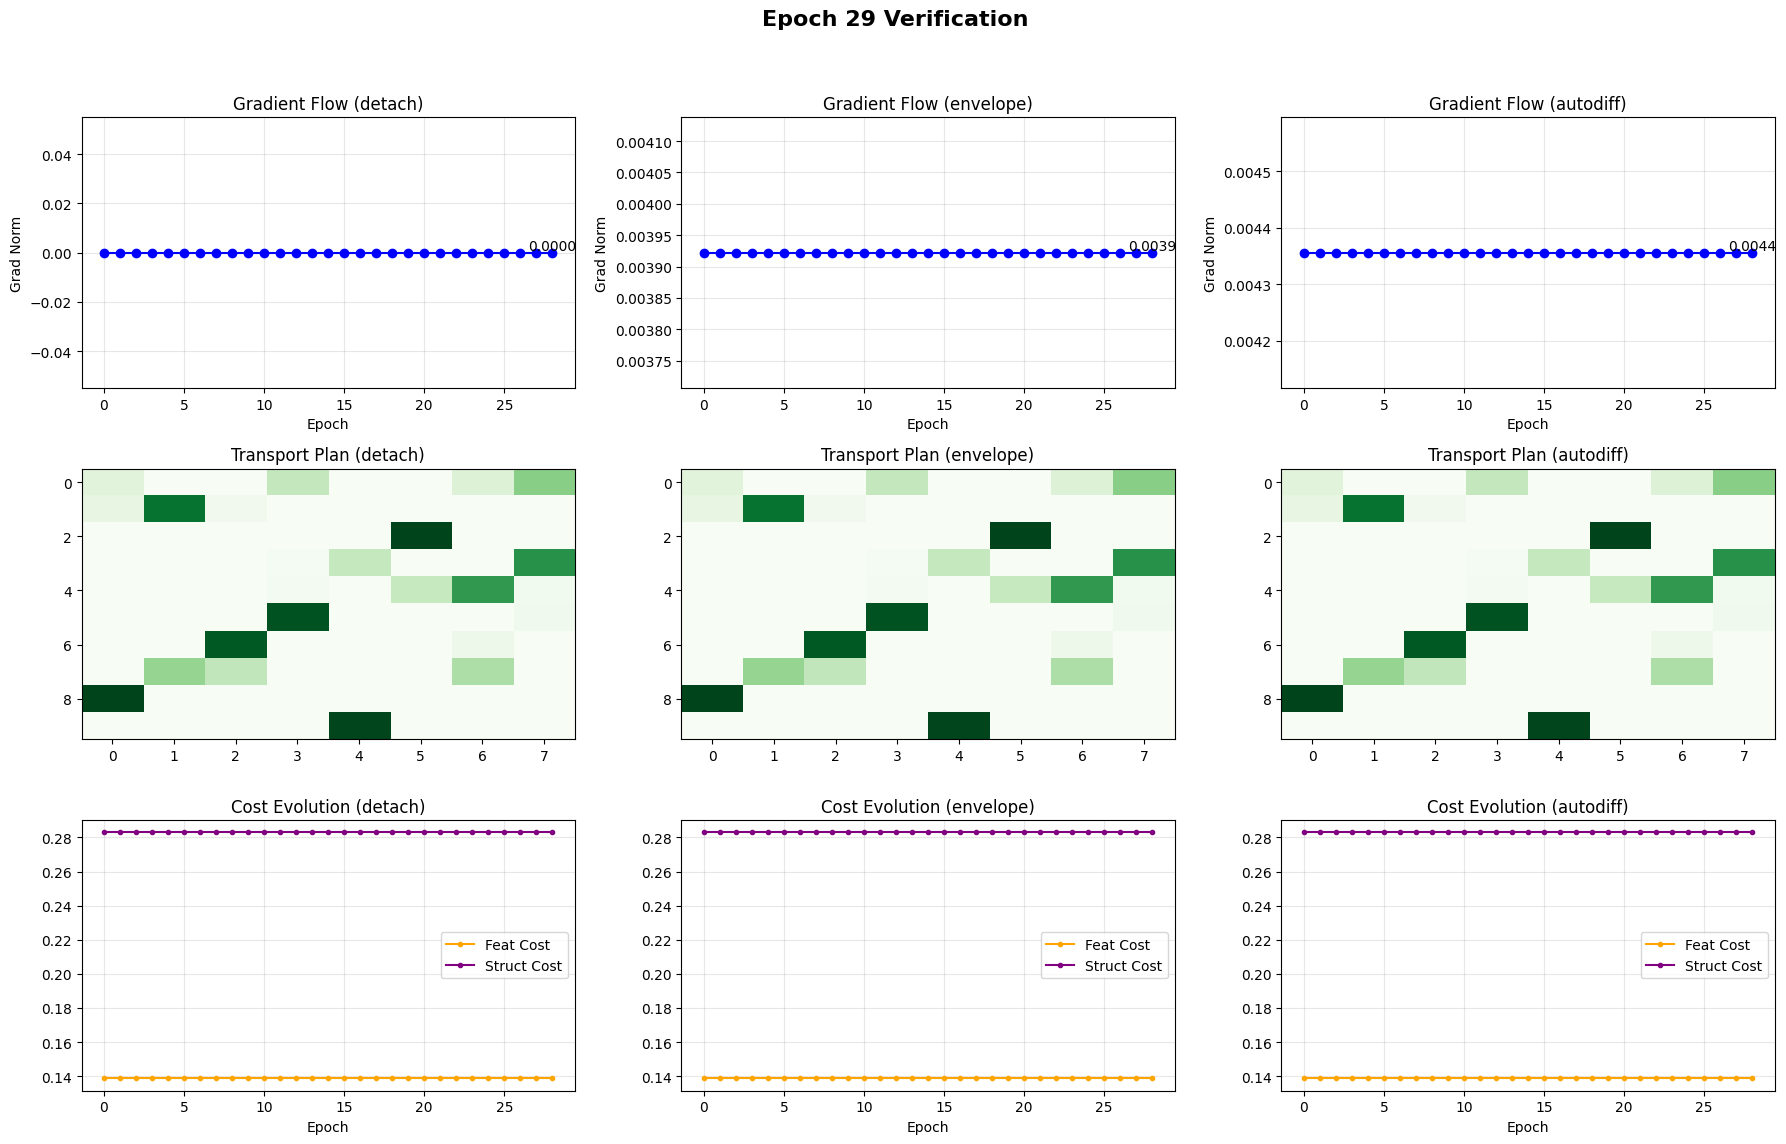

Epoch 29 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


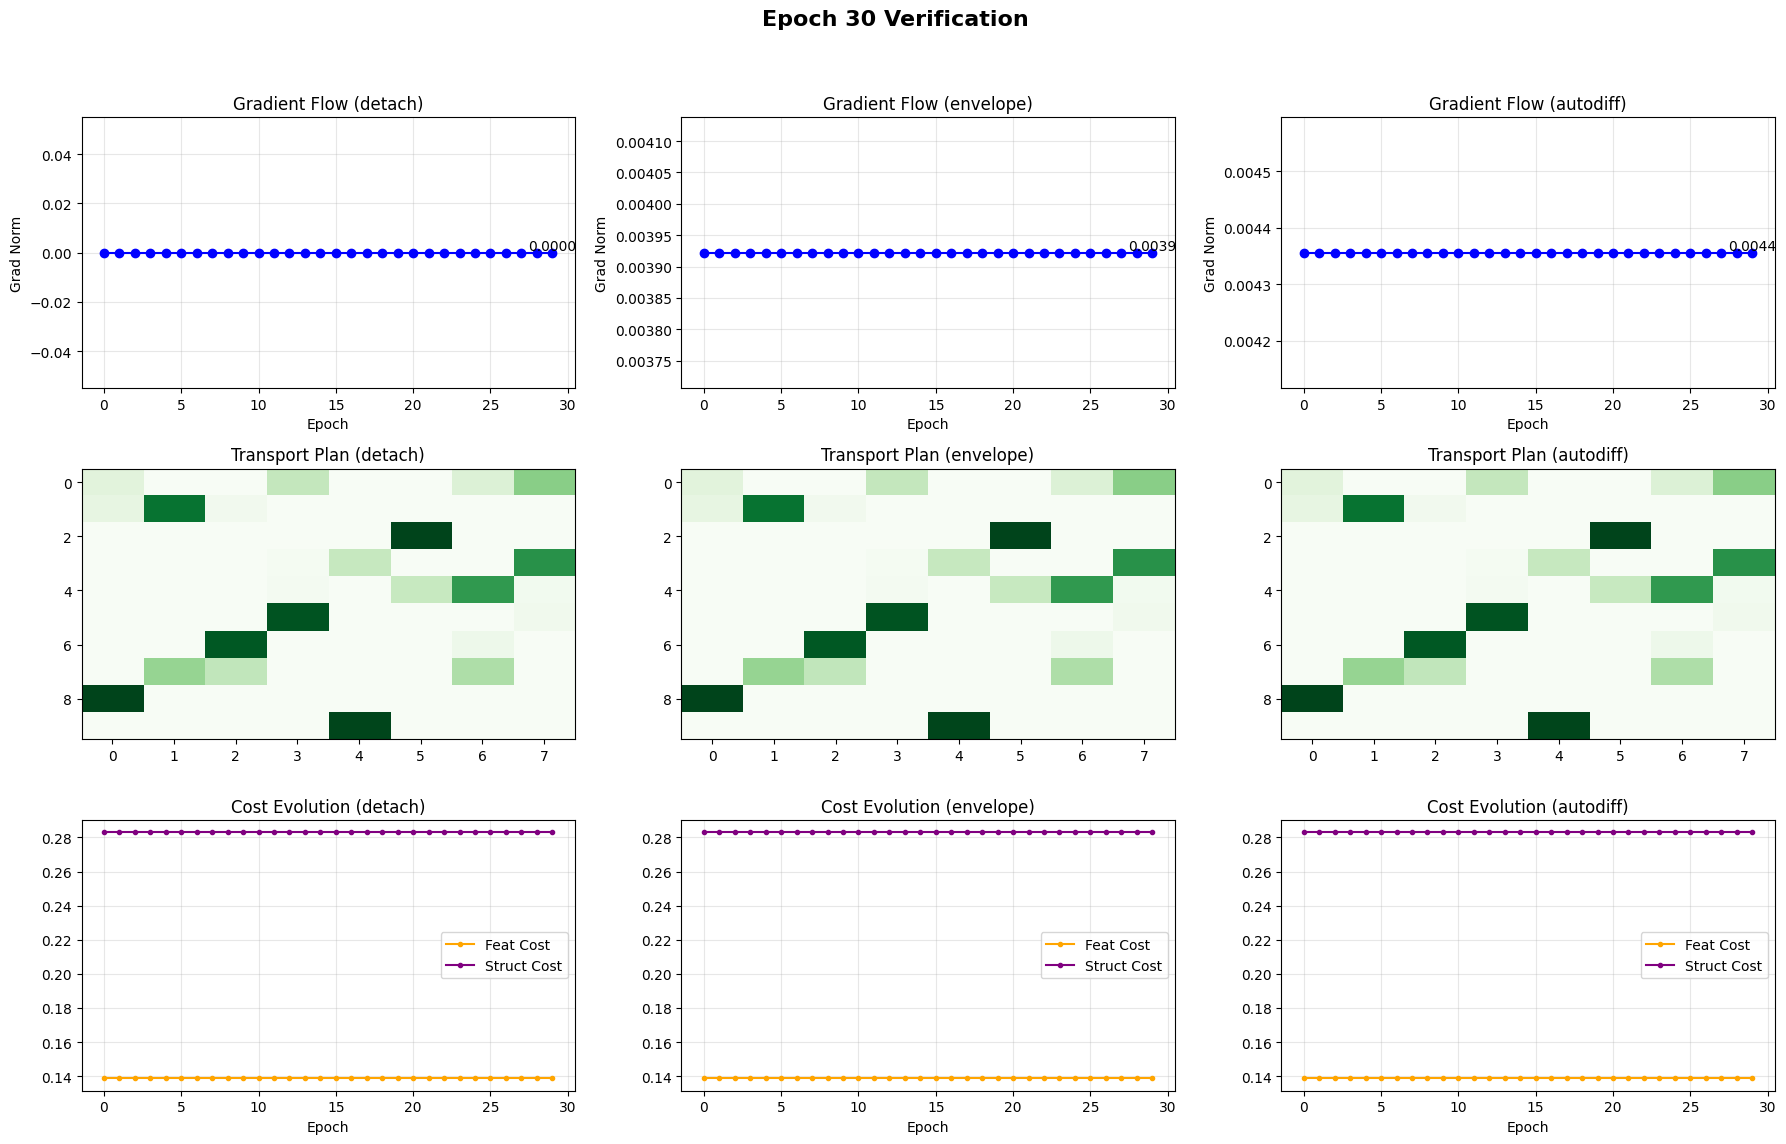

Epoch 30 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


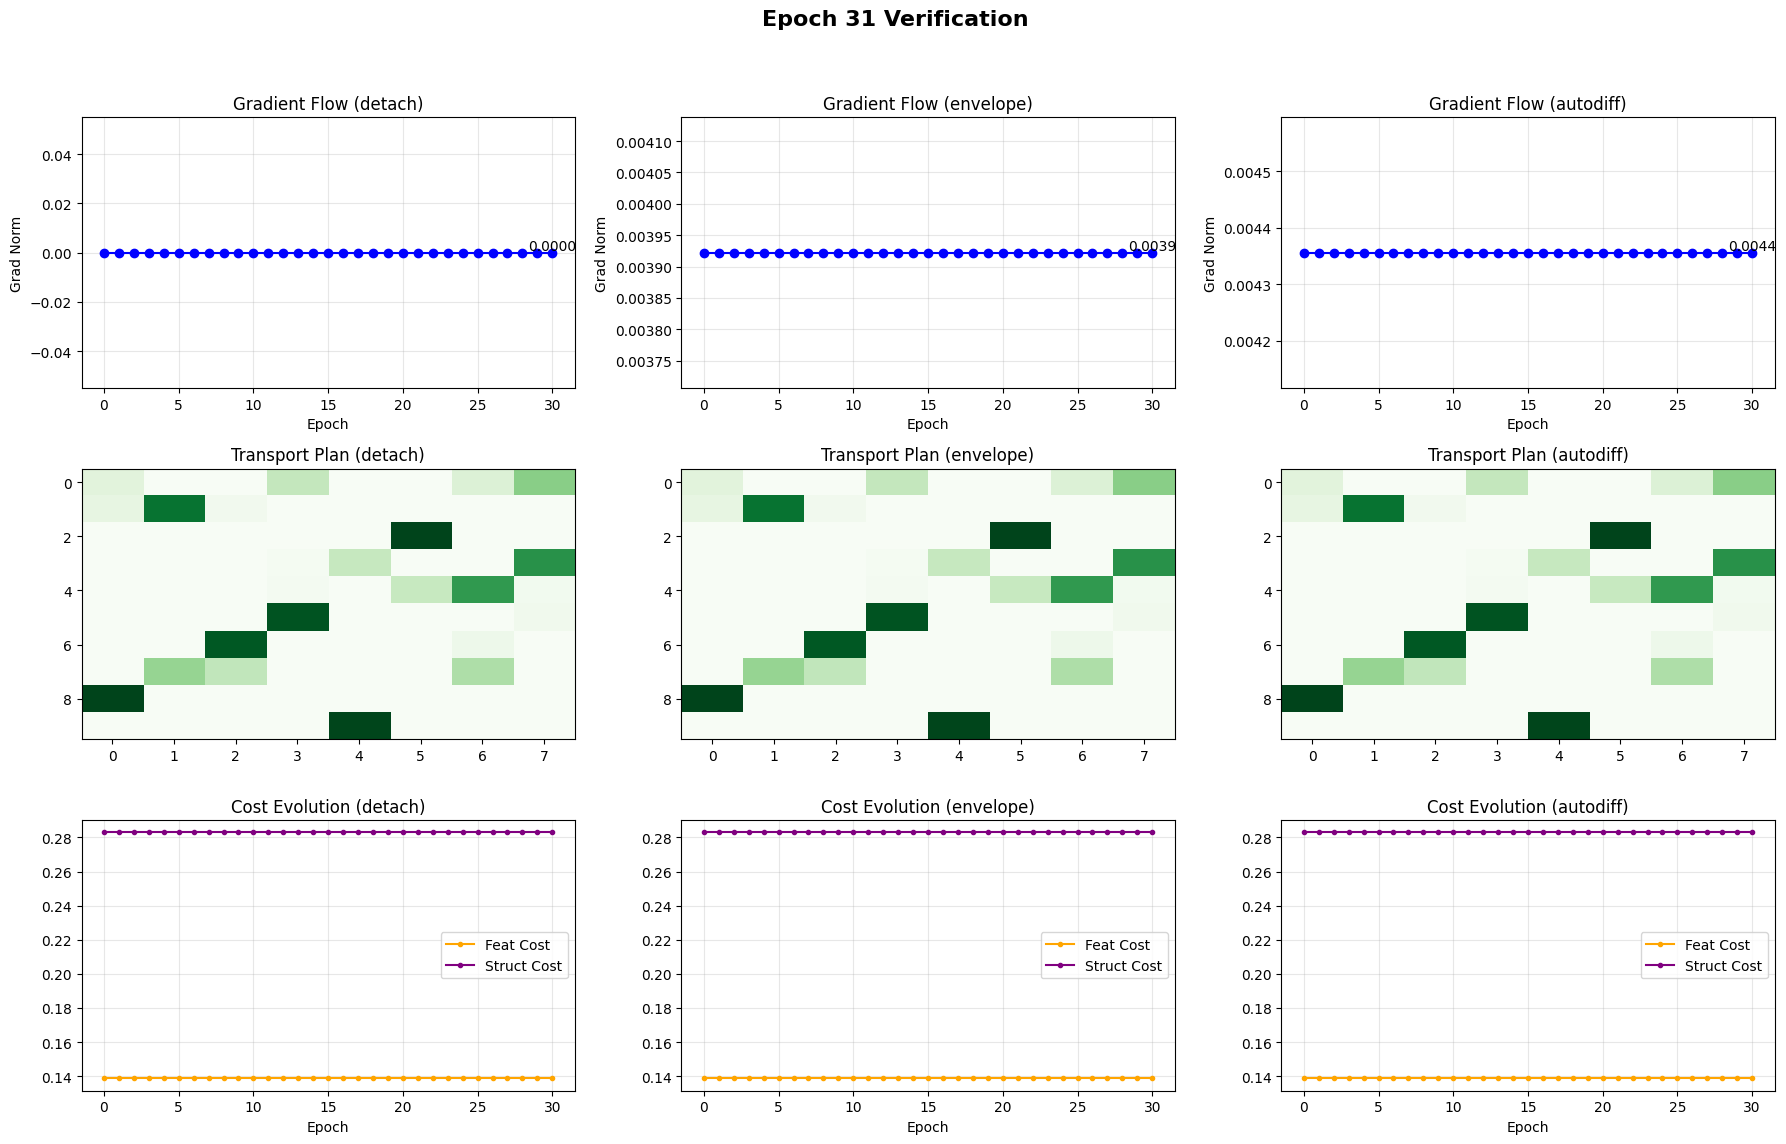

Epoch 31 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


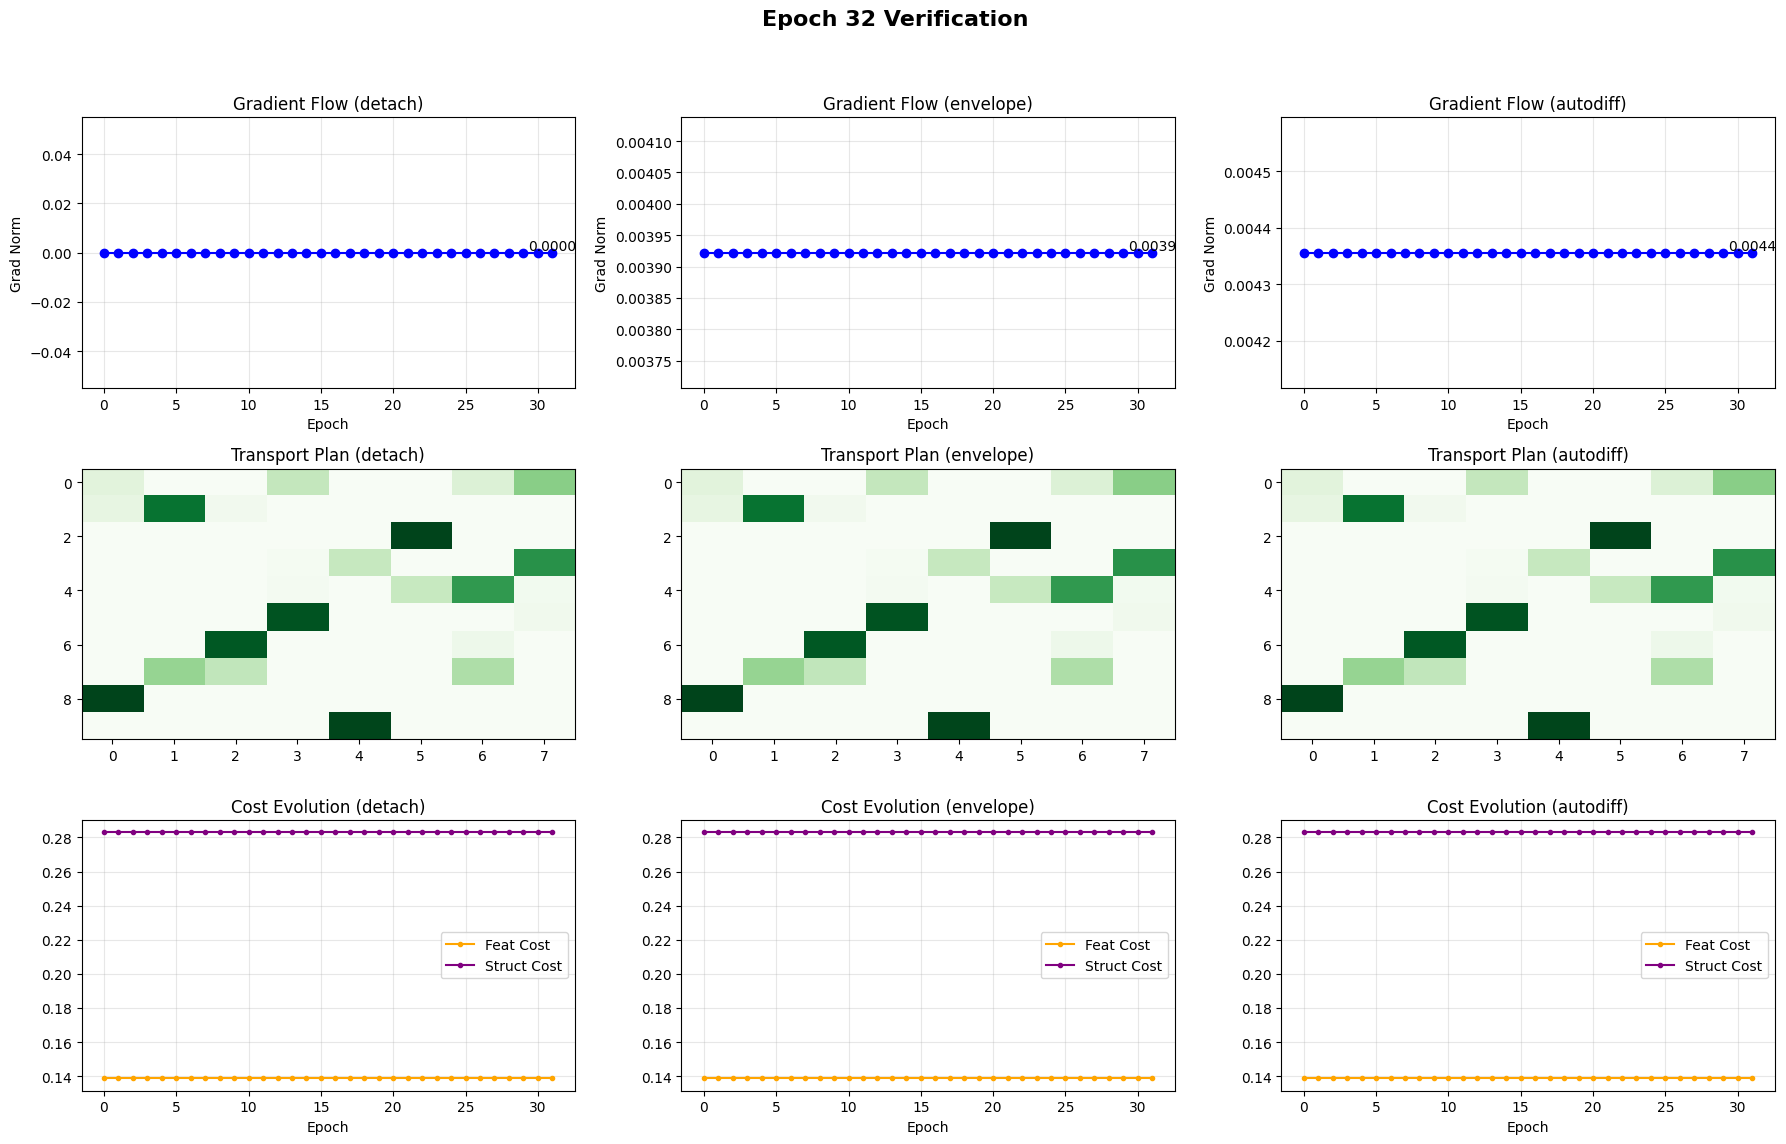

Epoch 32 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


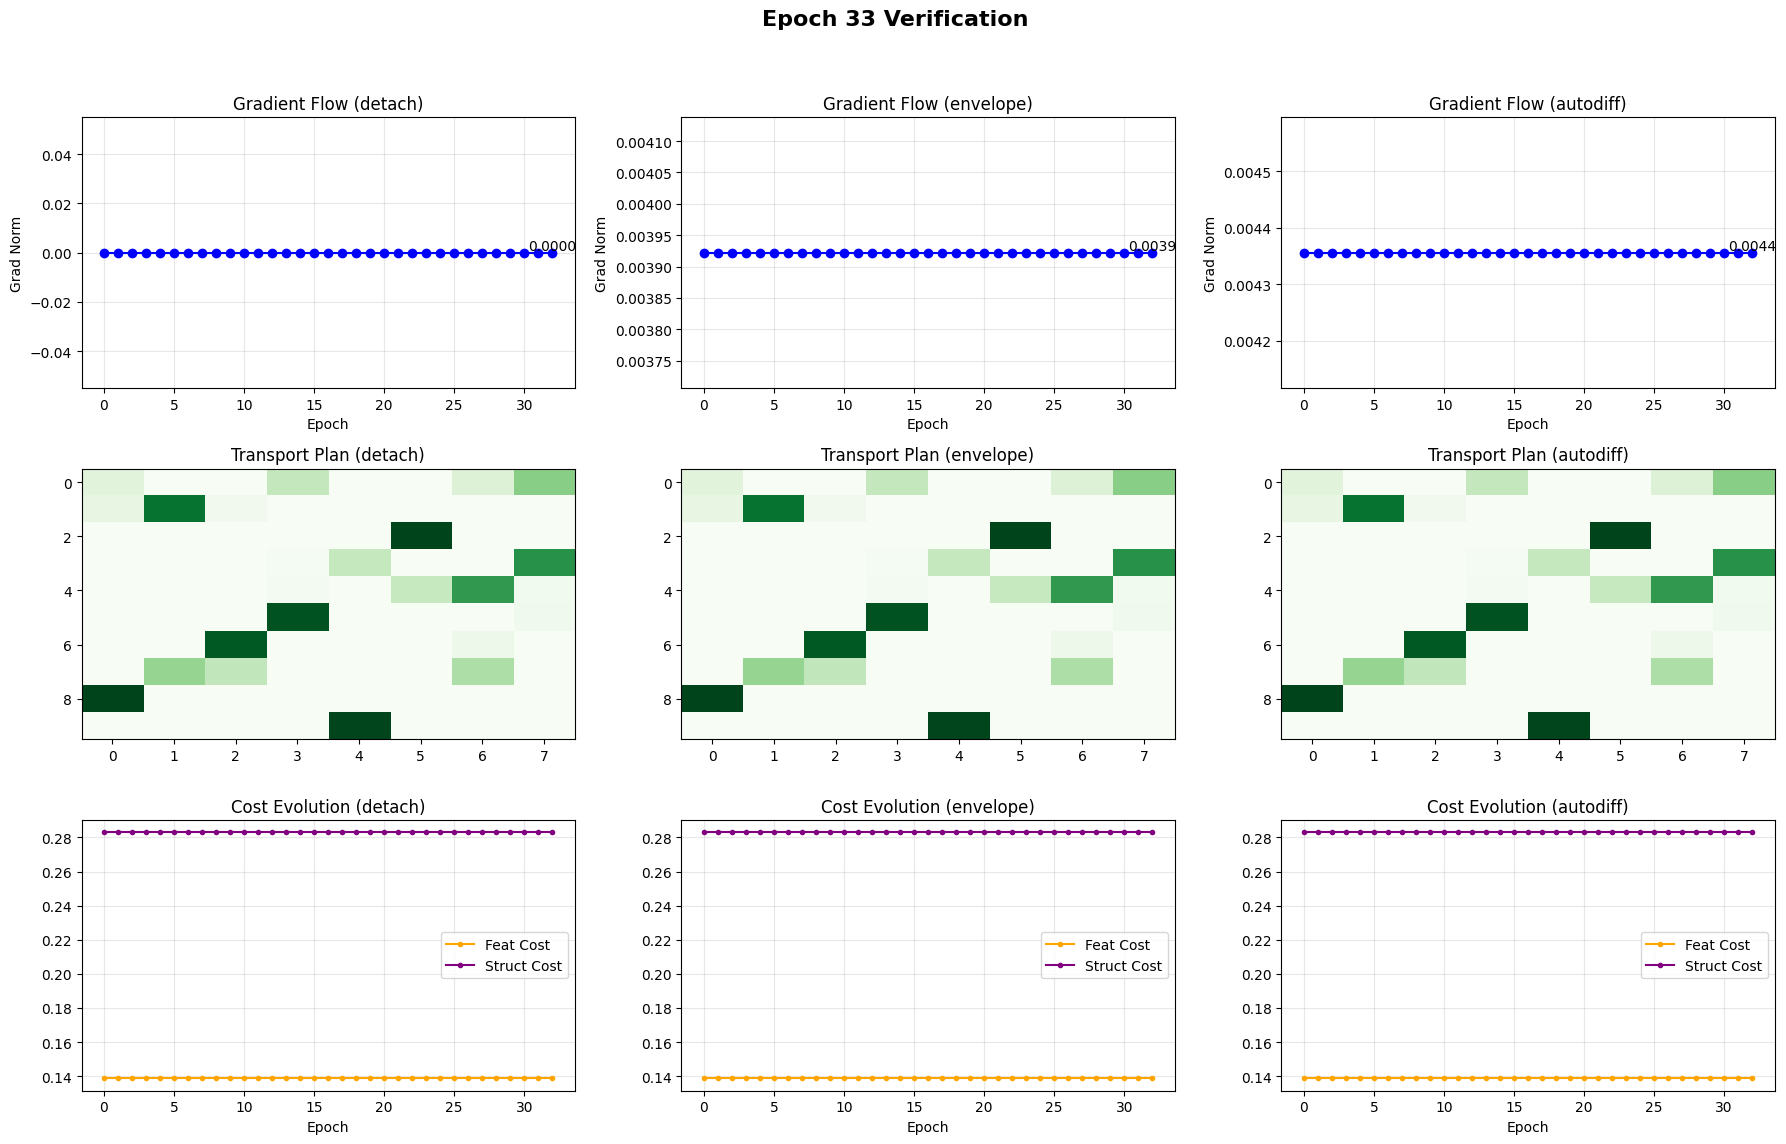

Epoch 33 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


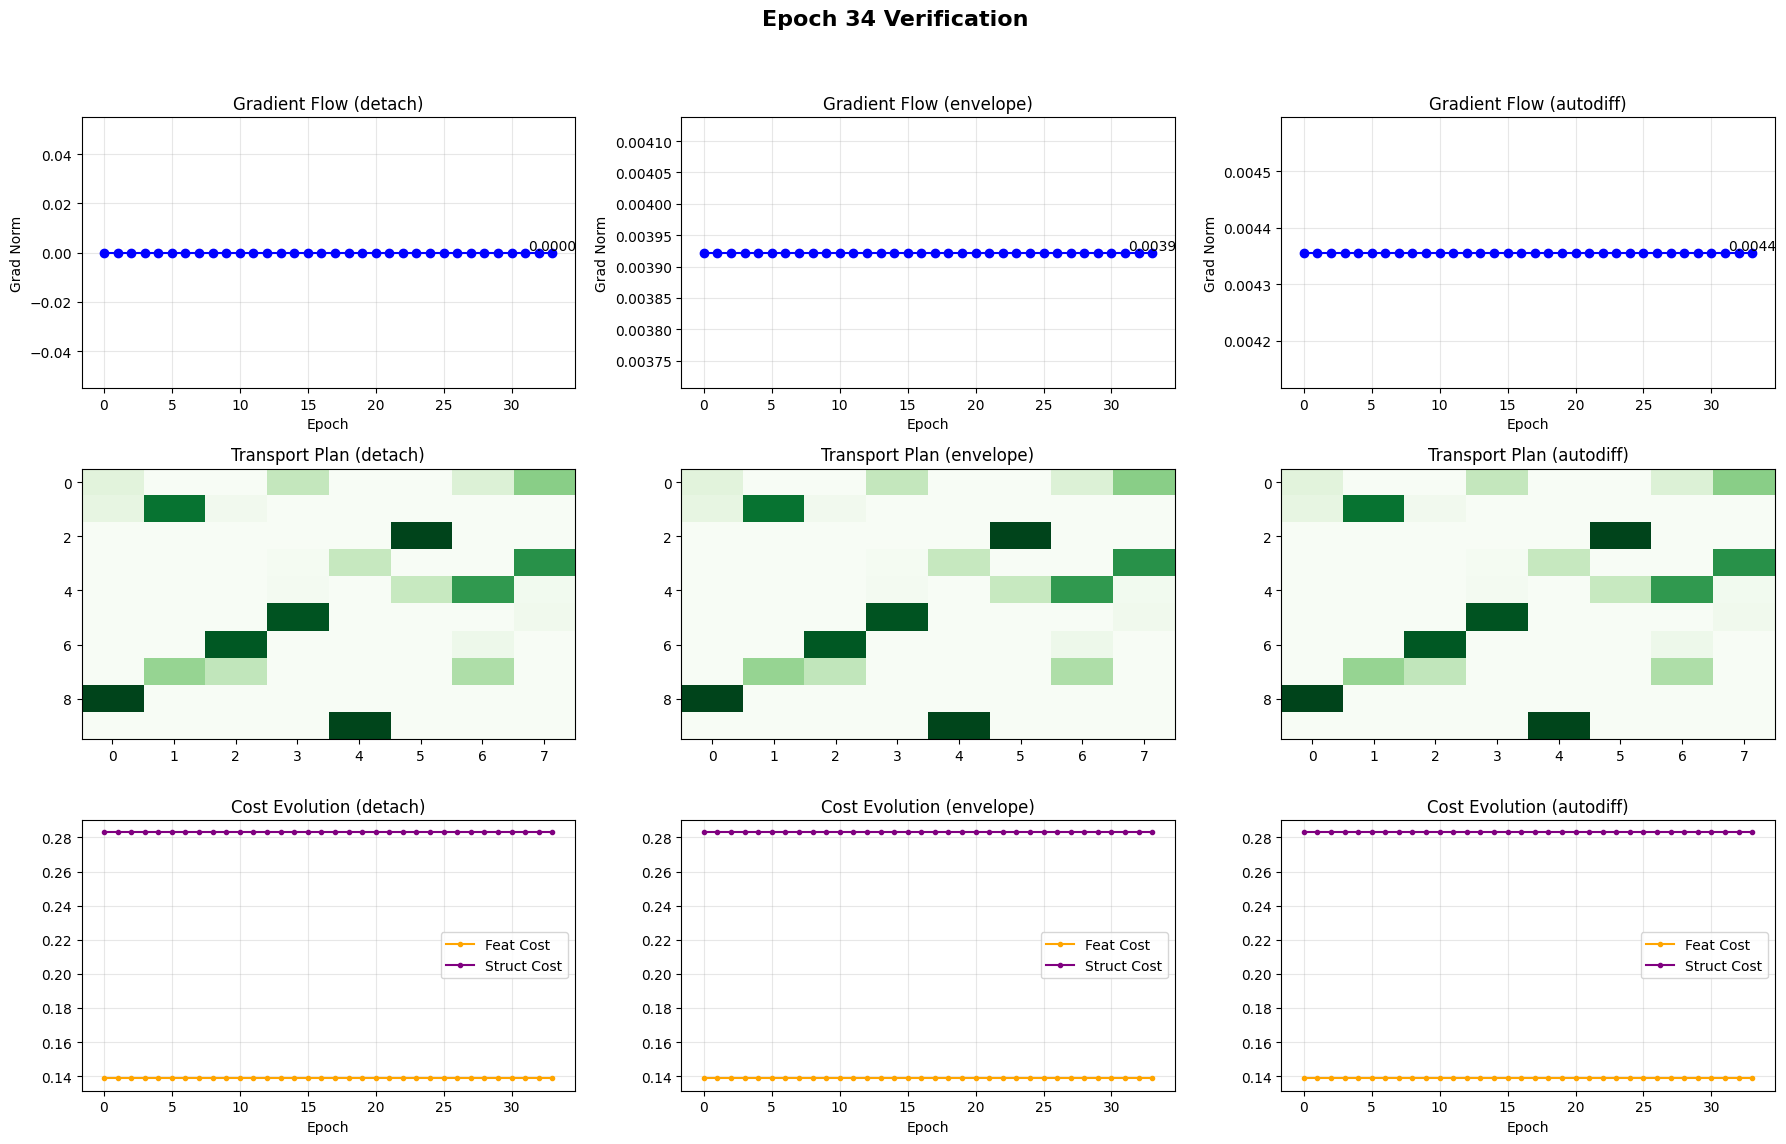

Epoch 34 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


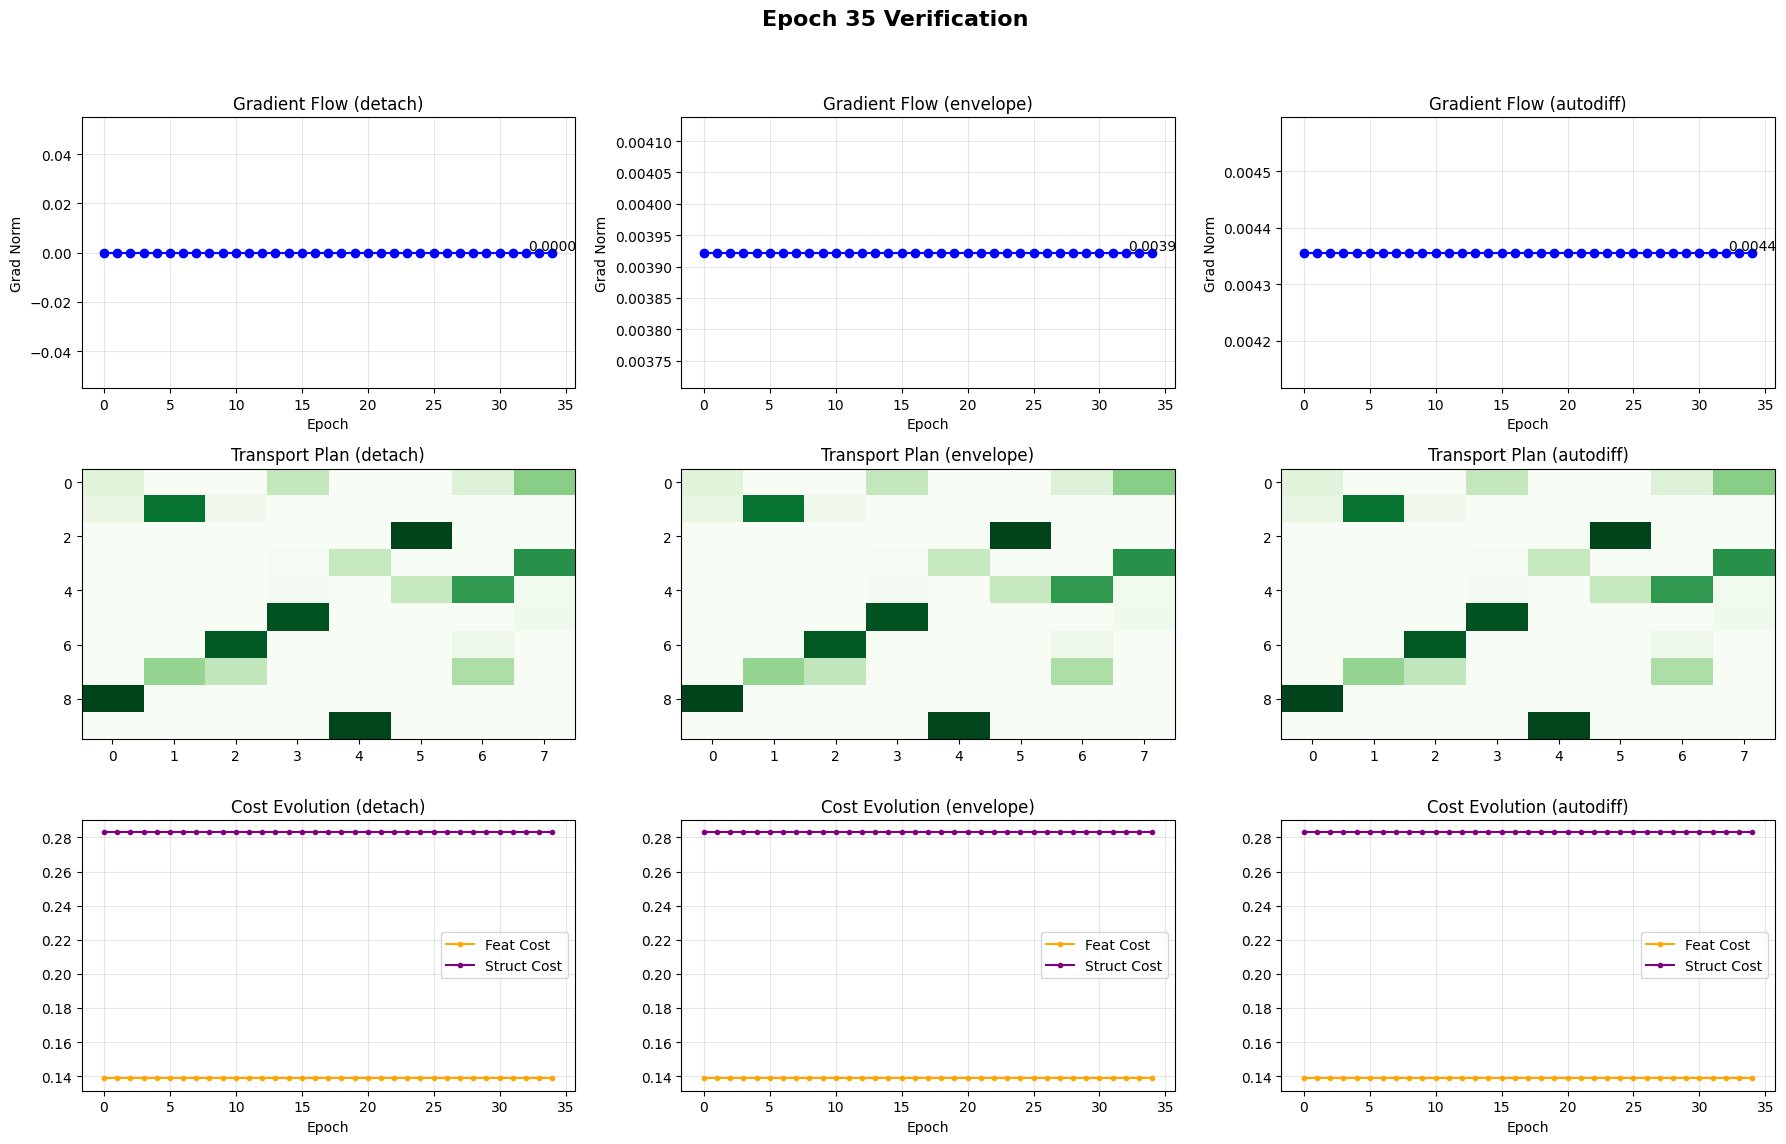

Epoch 35 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


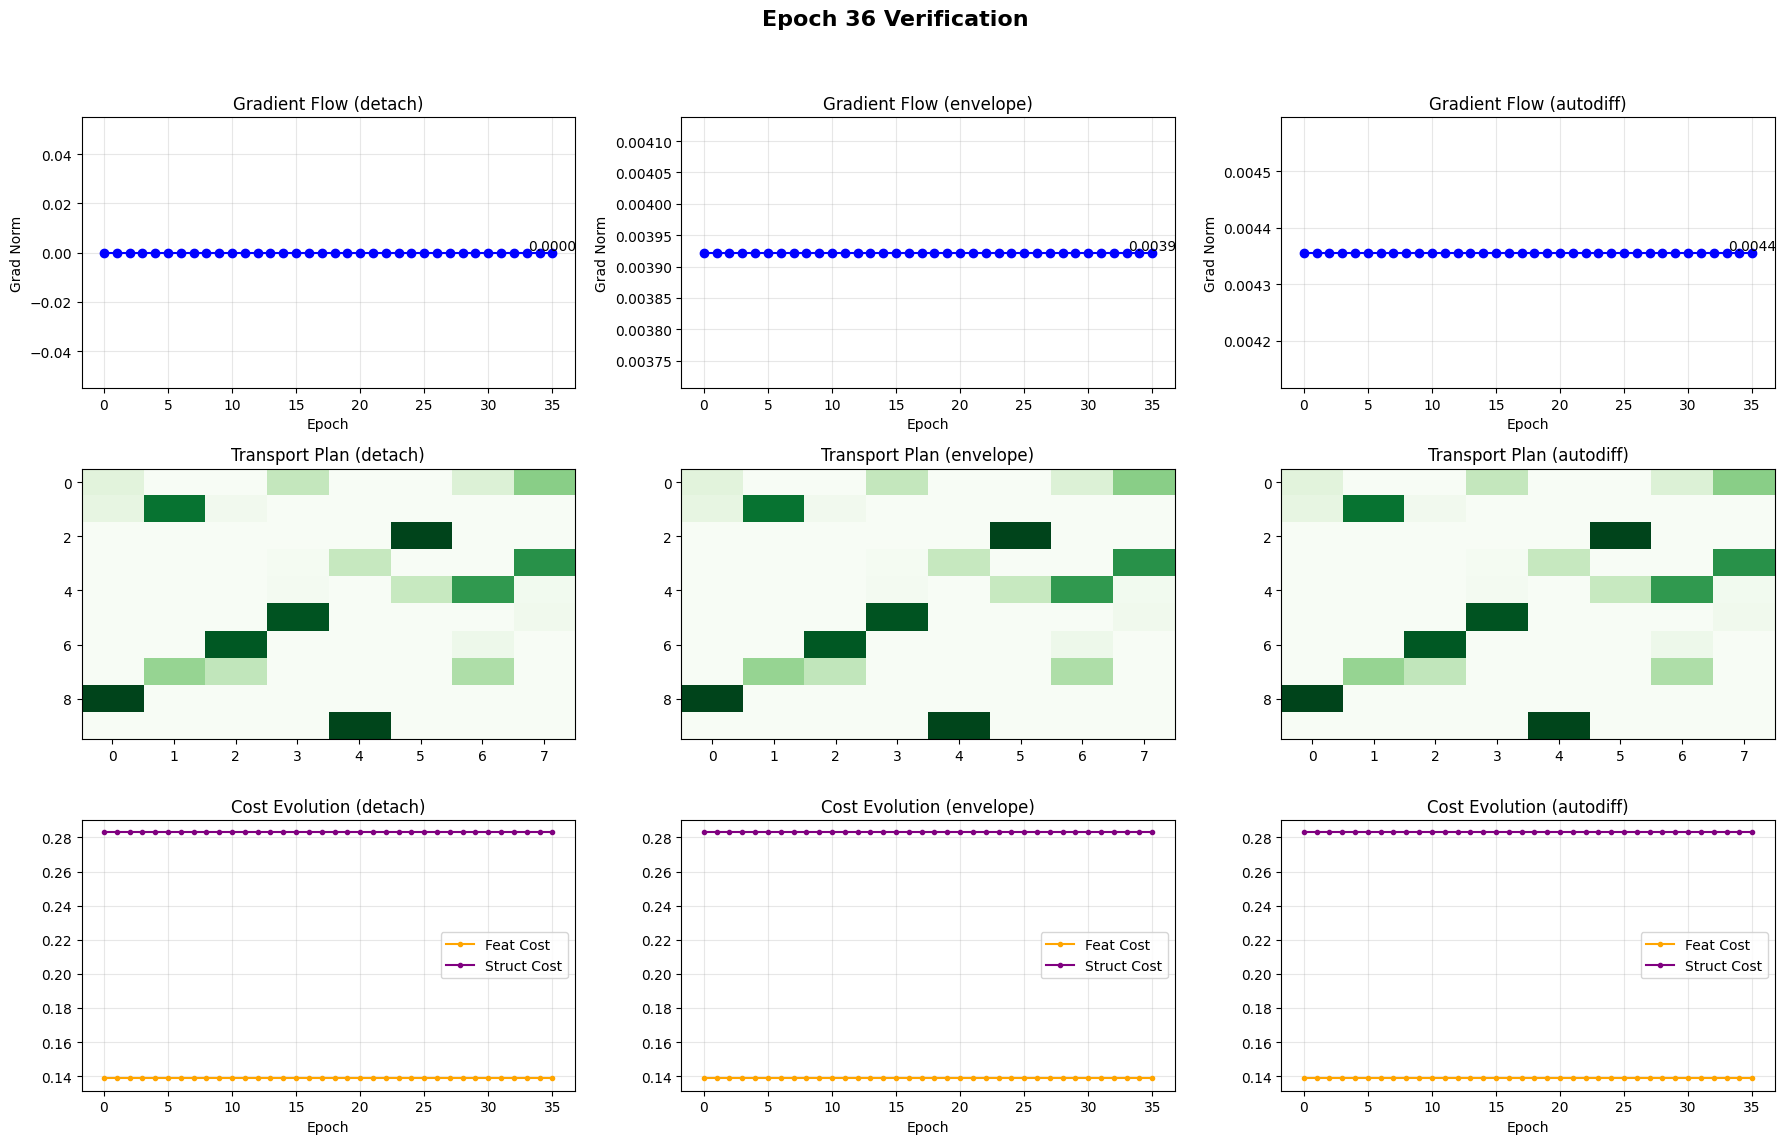

Epoch 36 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


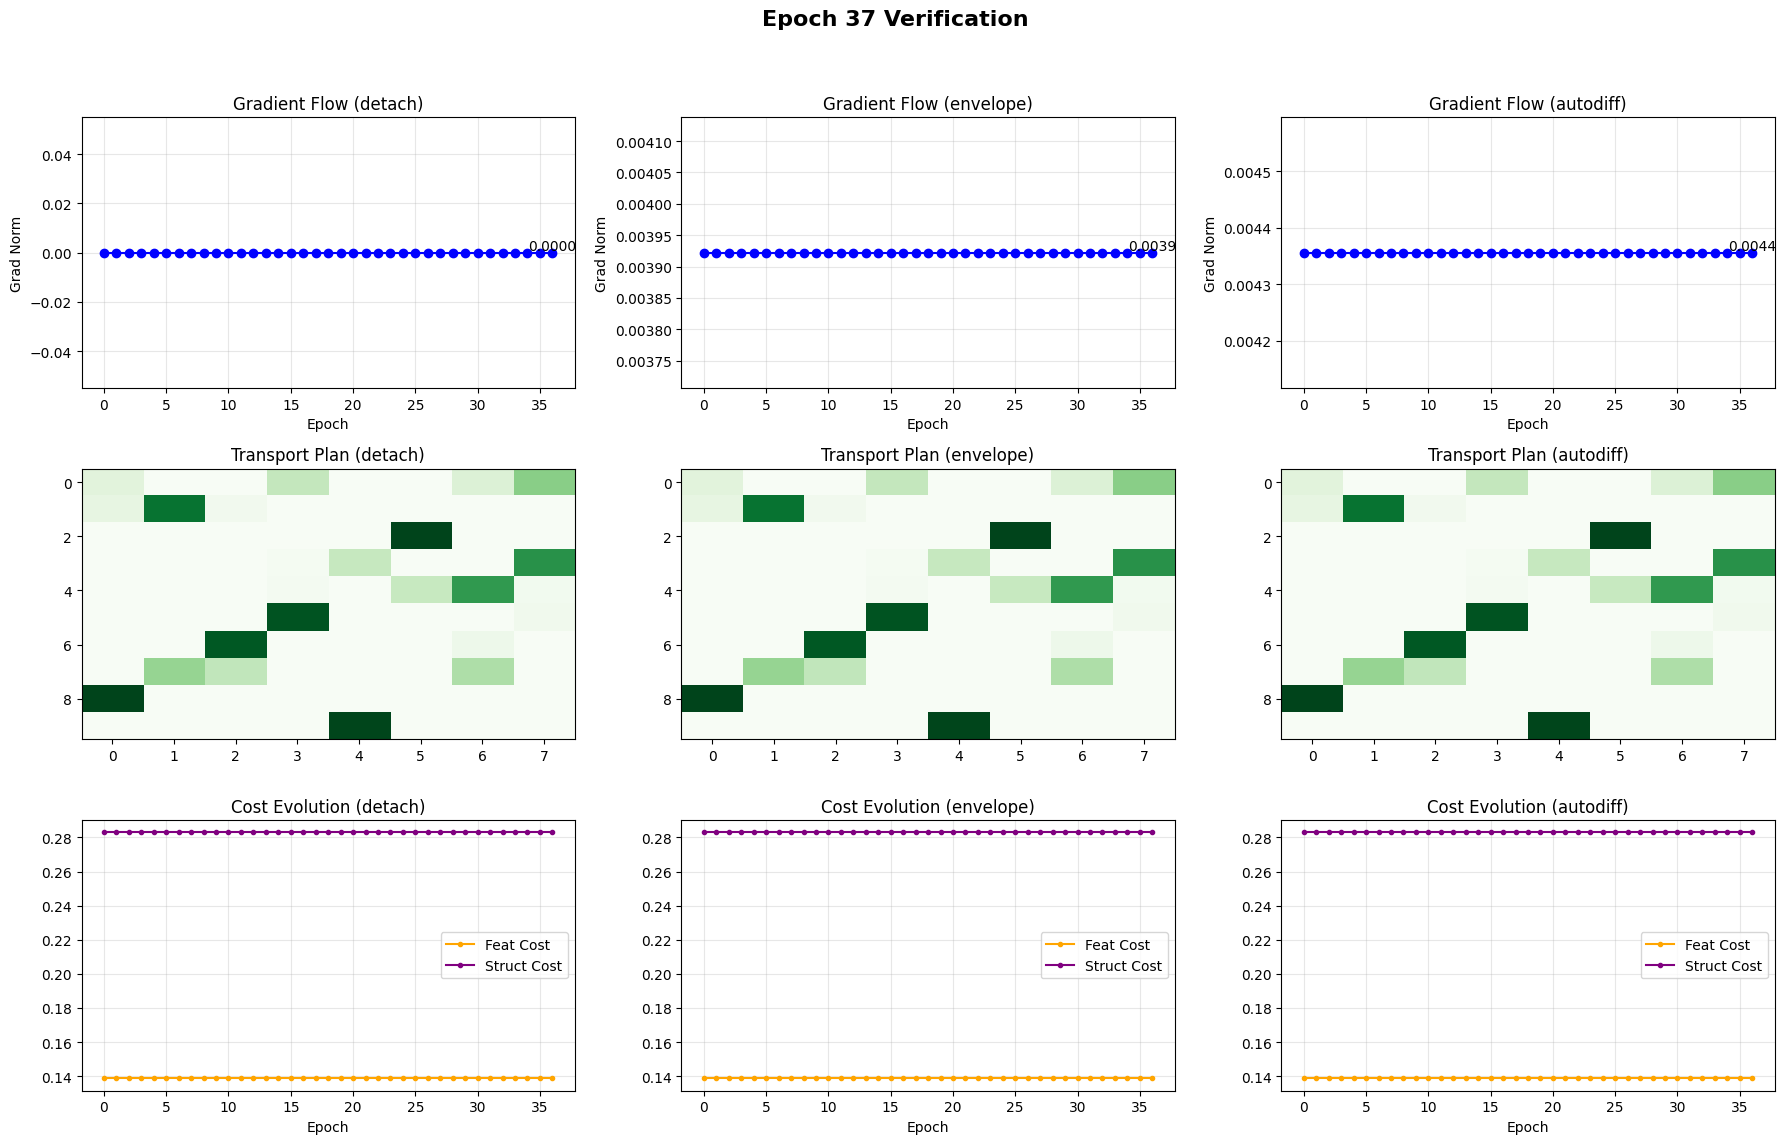

Epoch 37 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


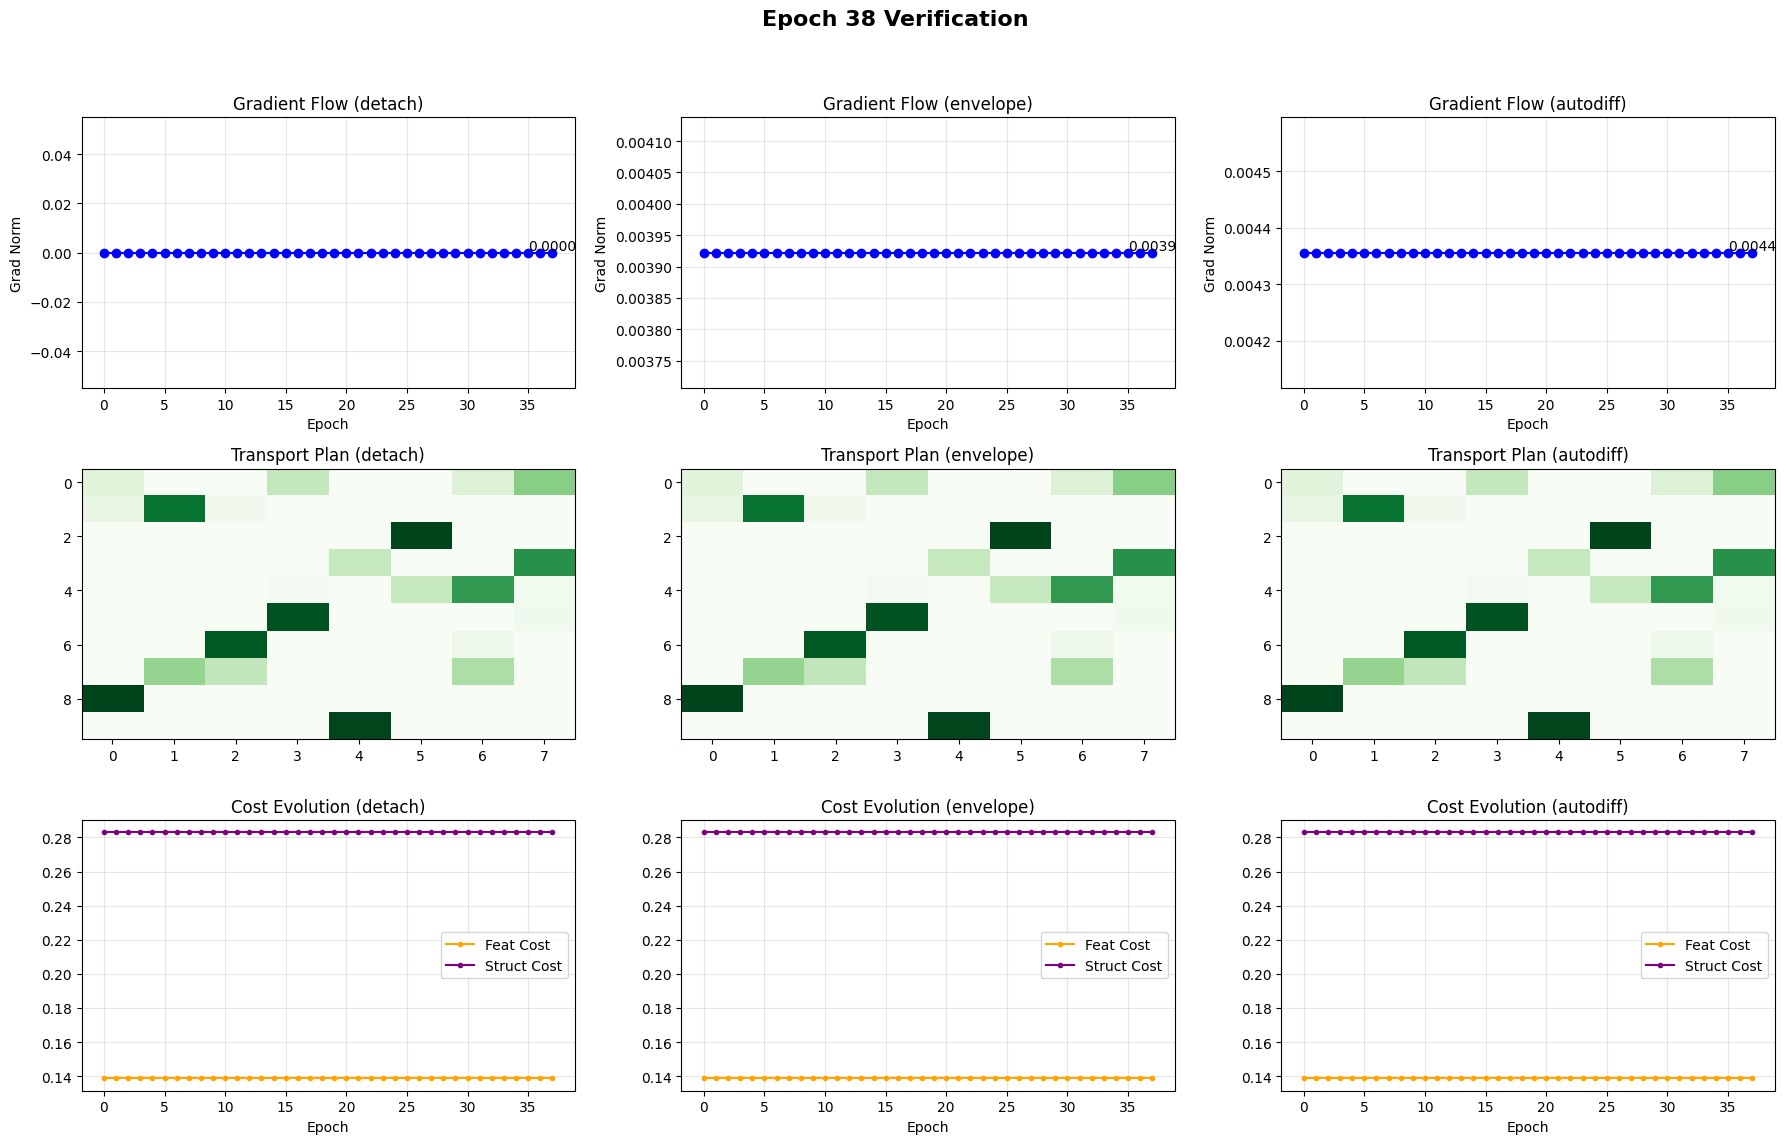

Epoch 38 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


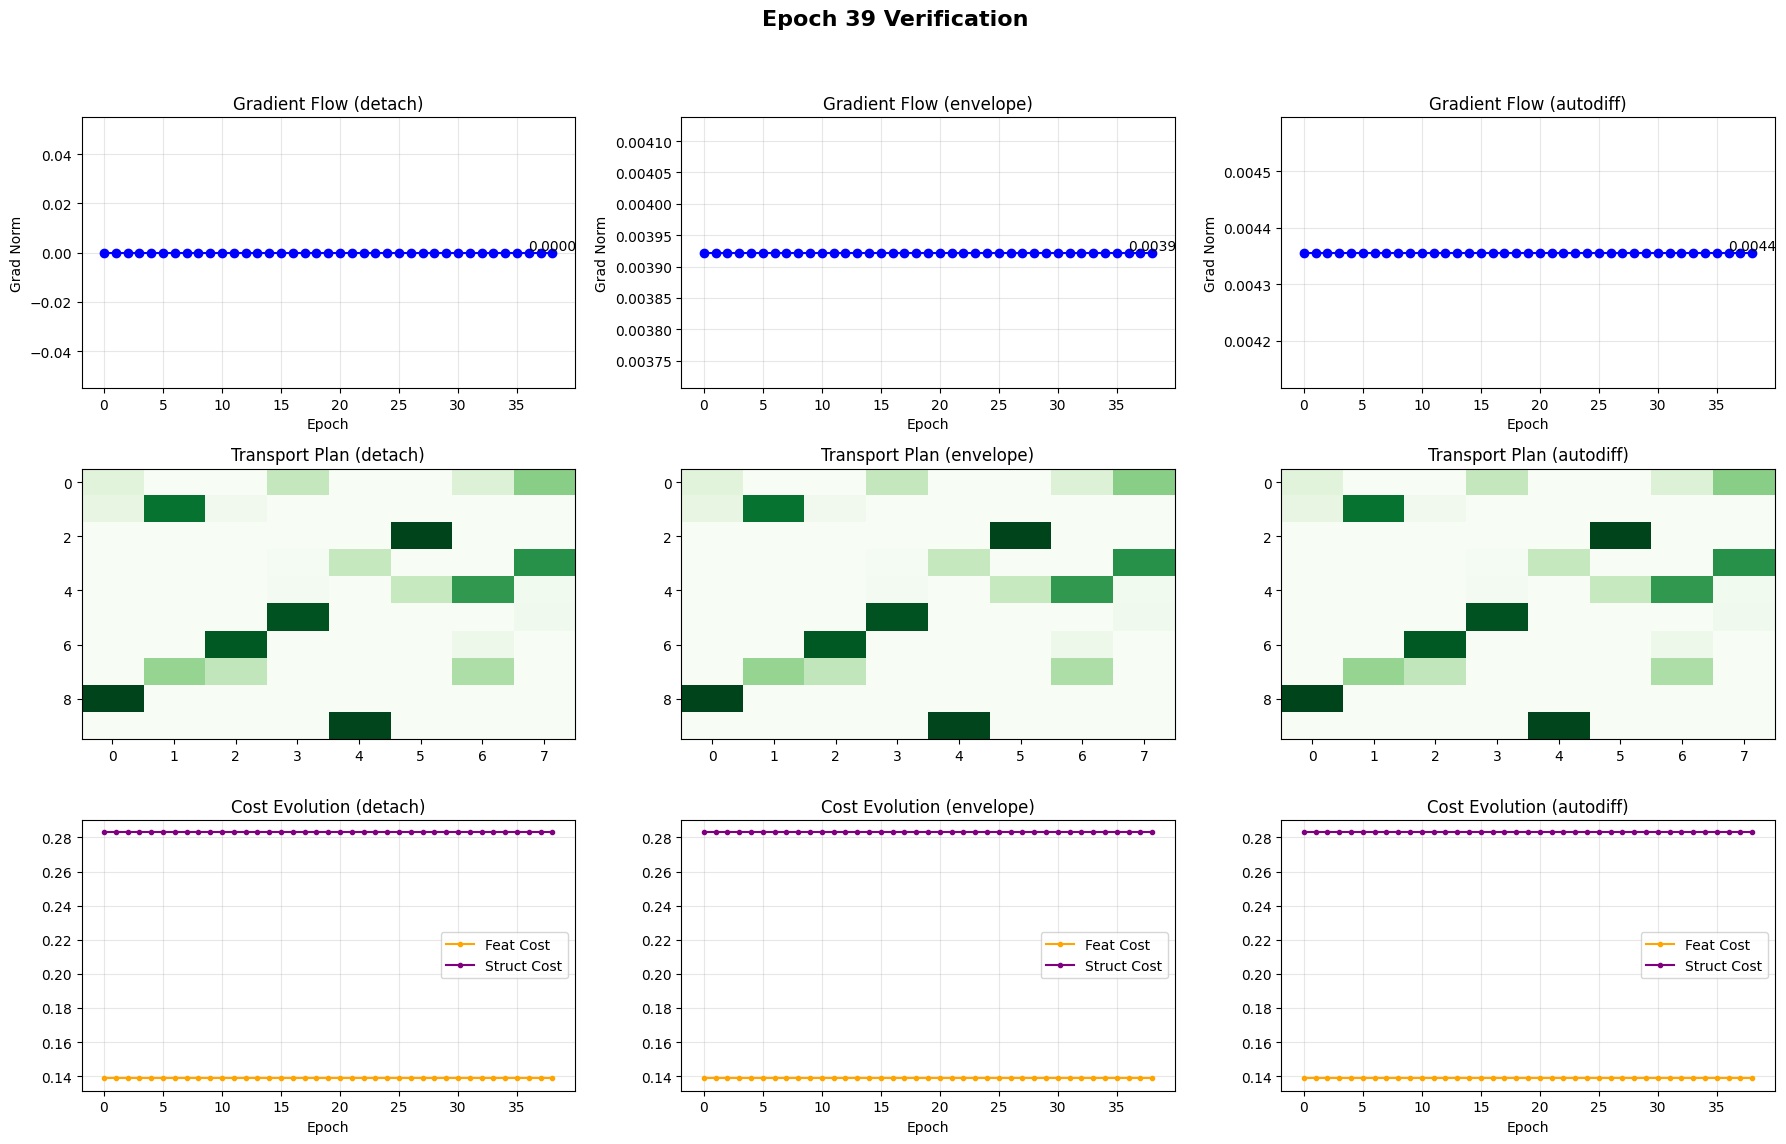

Epoch 39 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


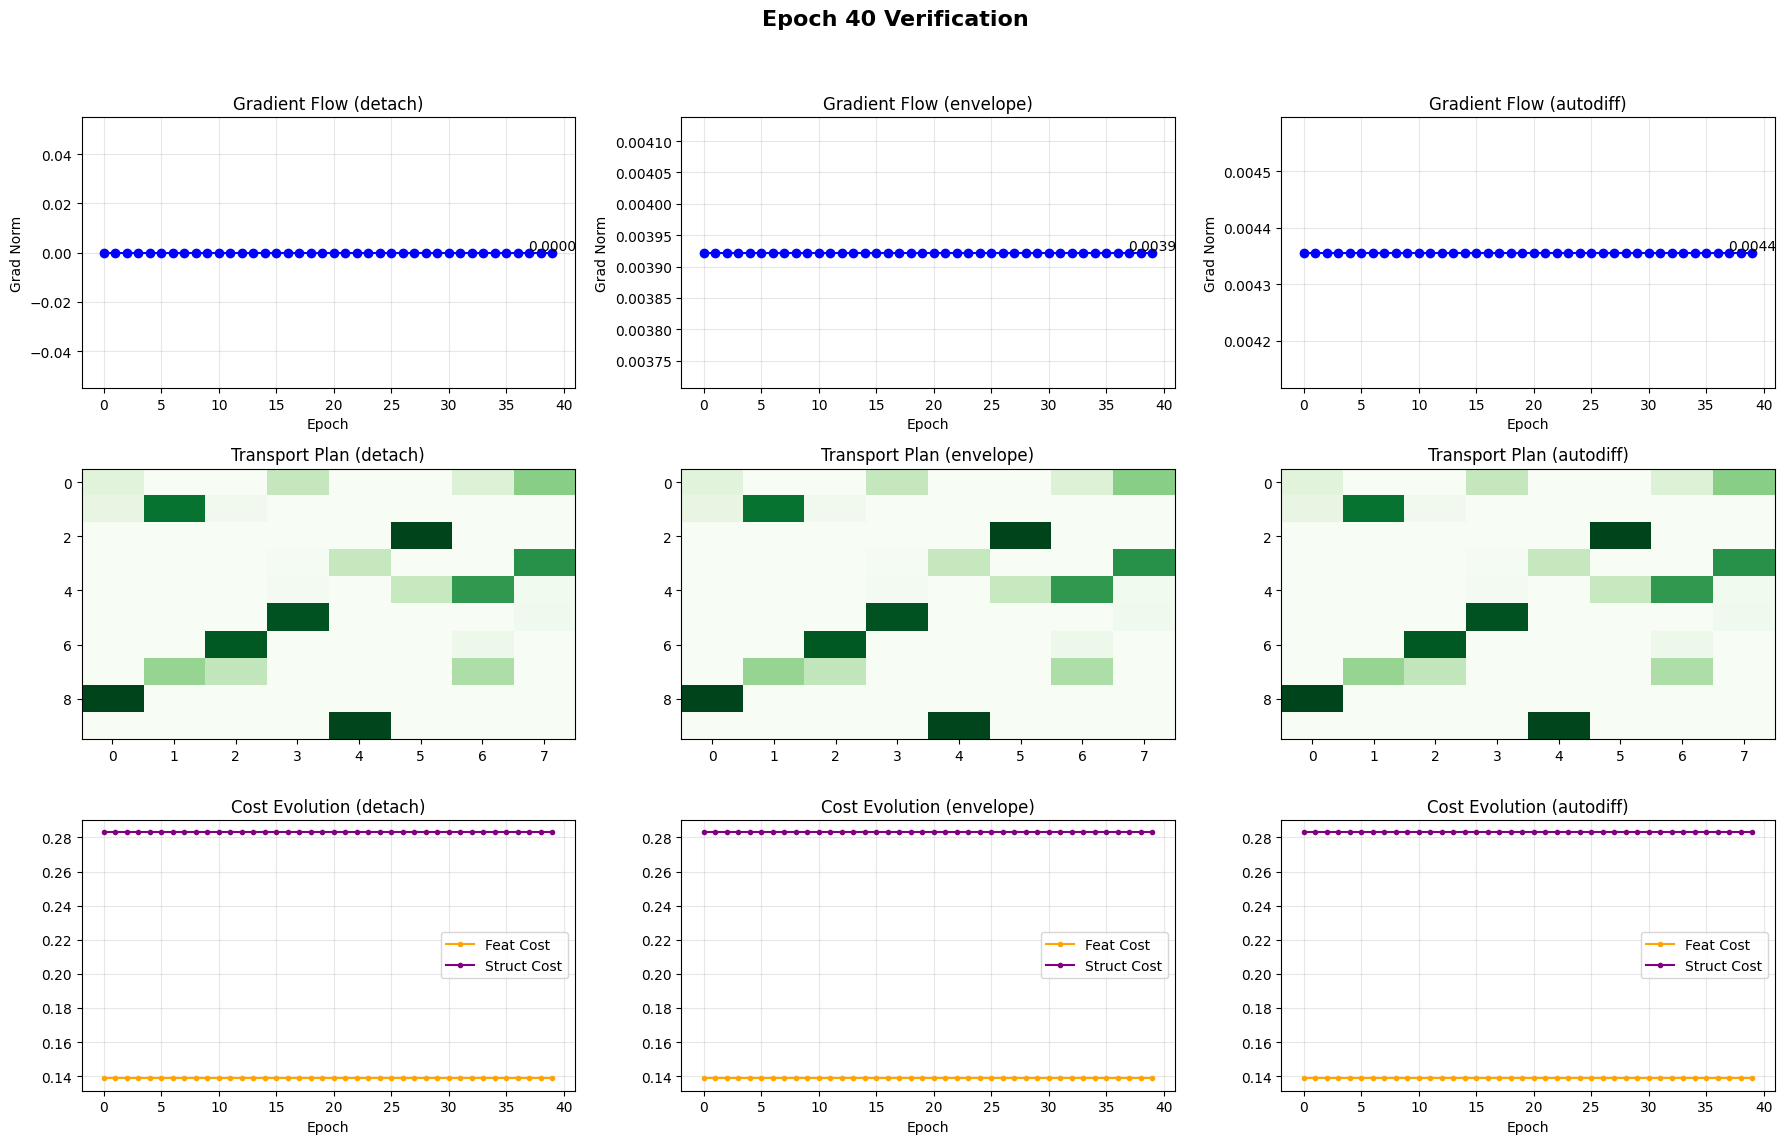

Epoch 40 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


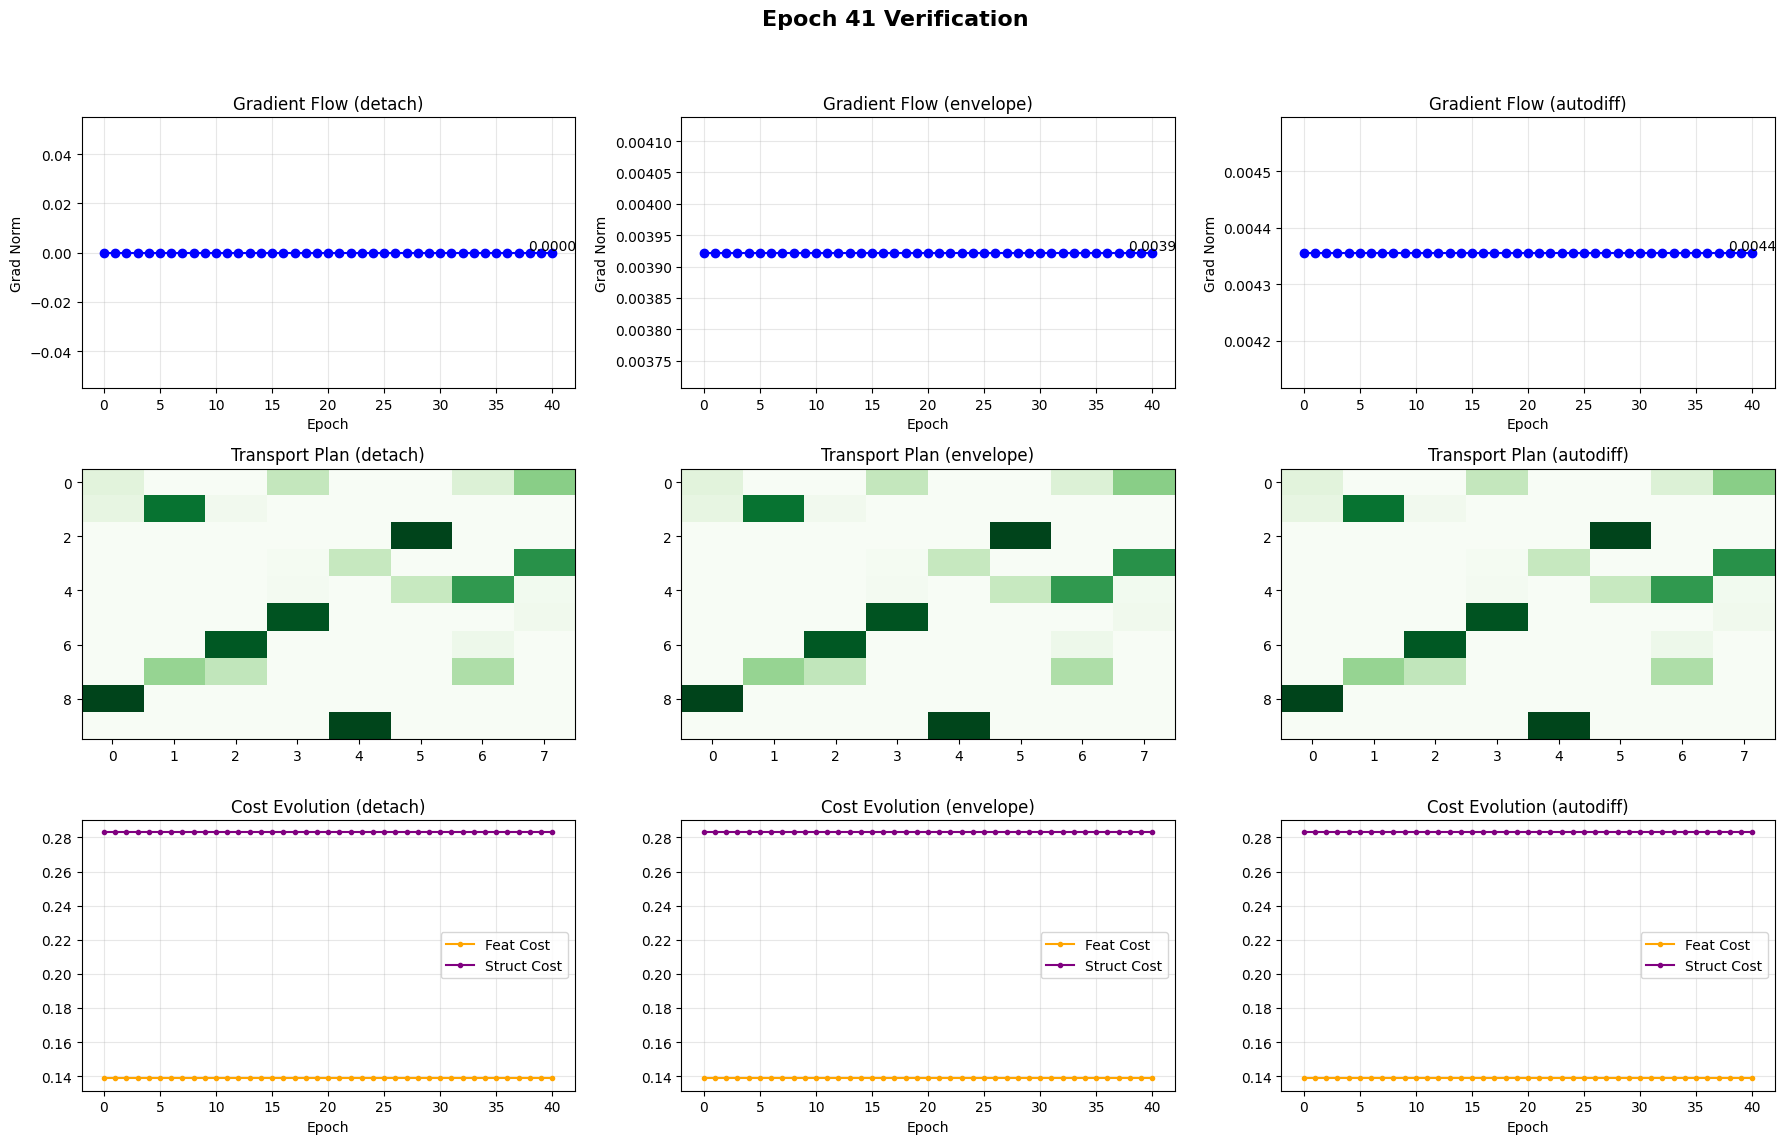

Epoch 41 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


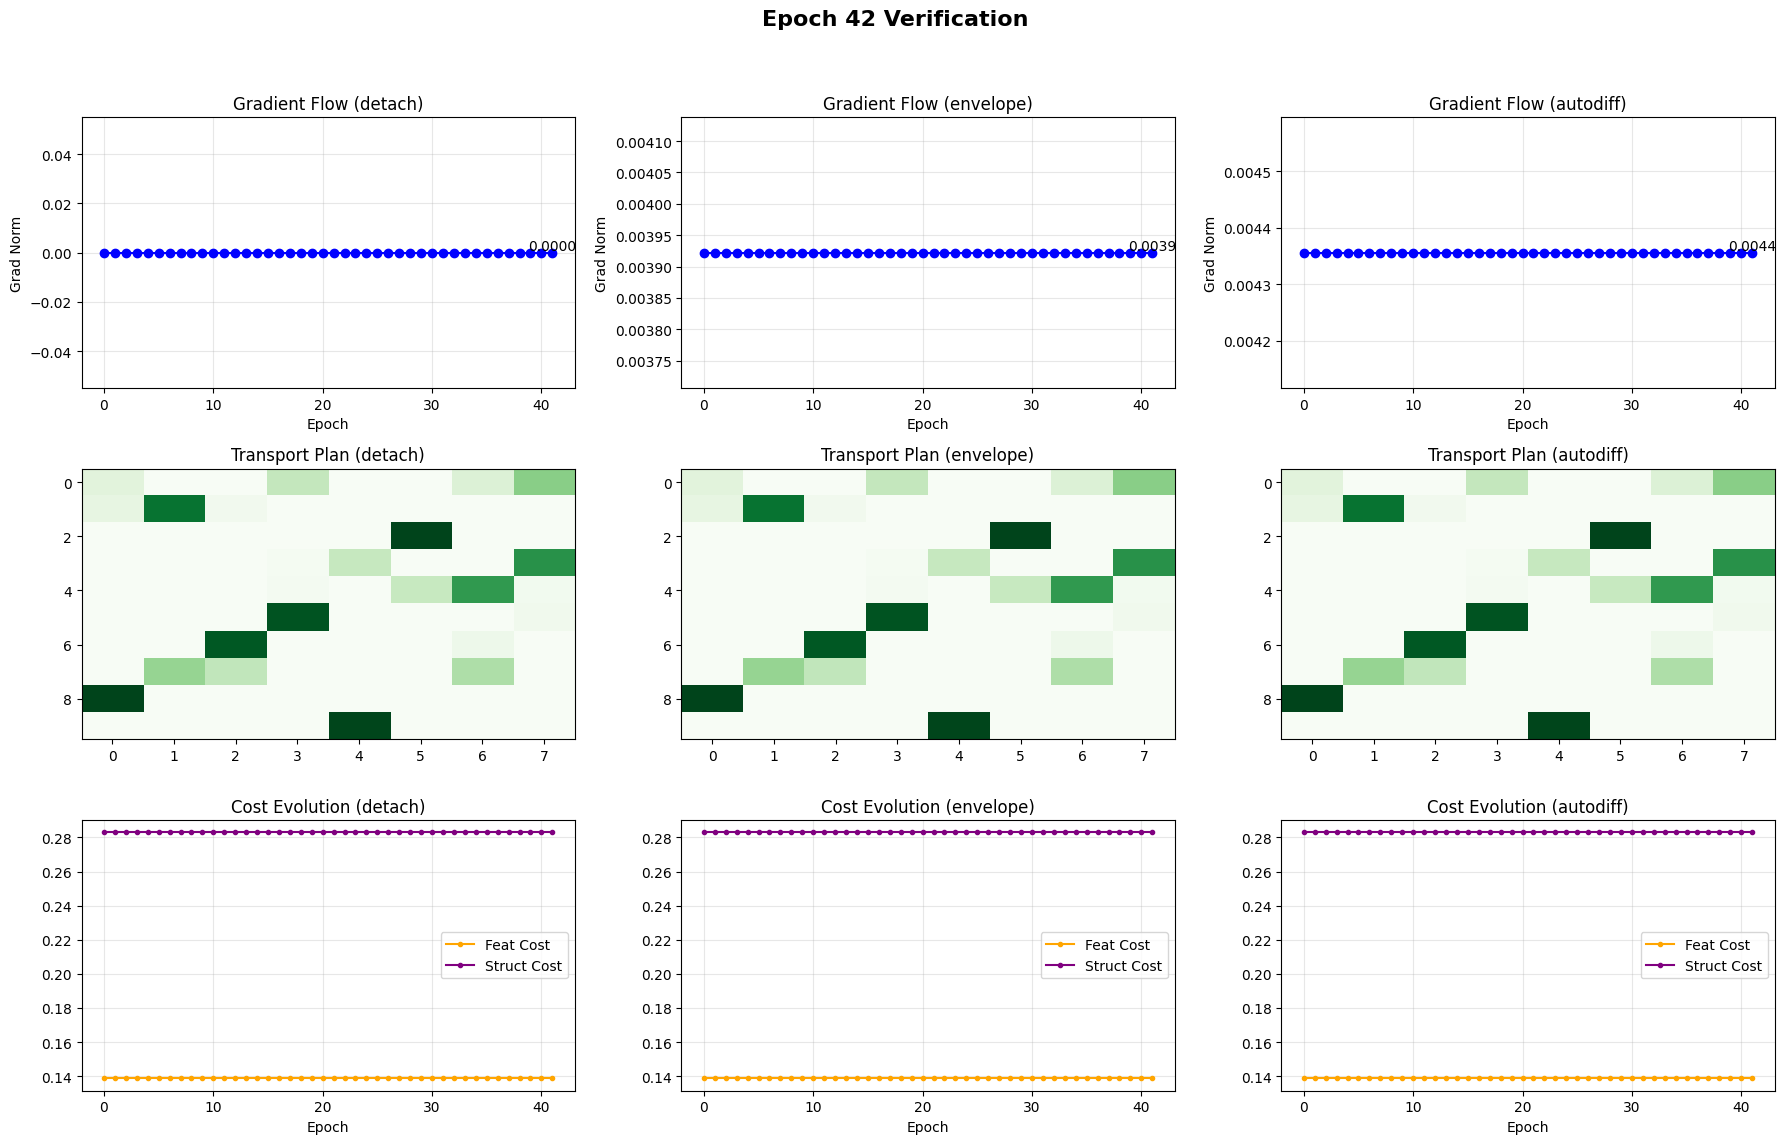

Epoch 42 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


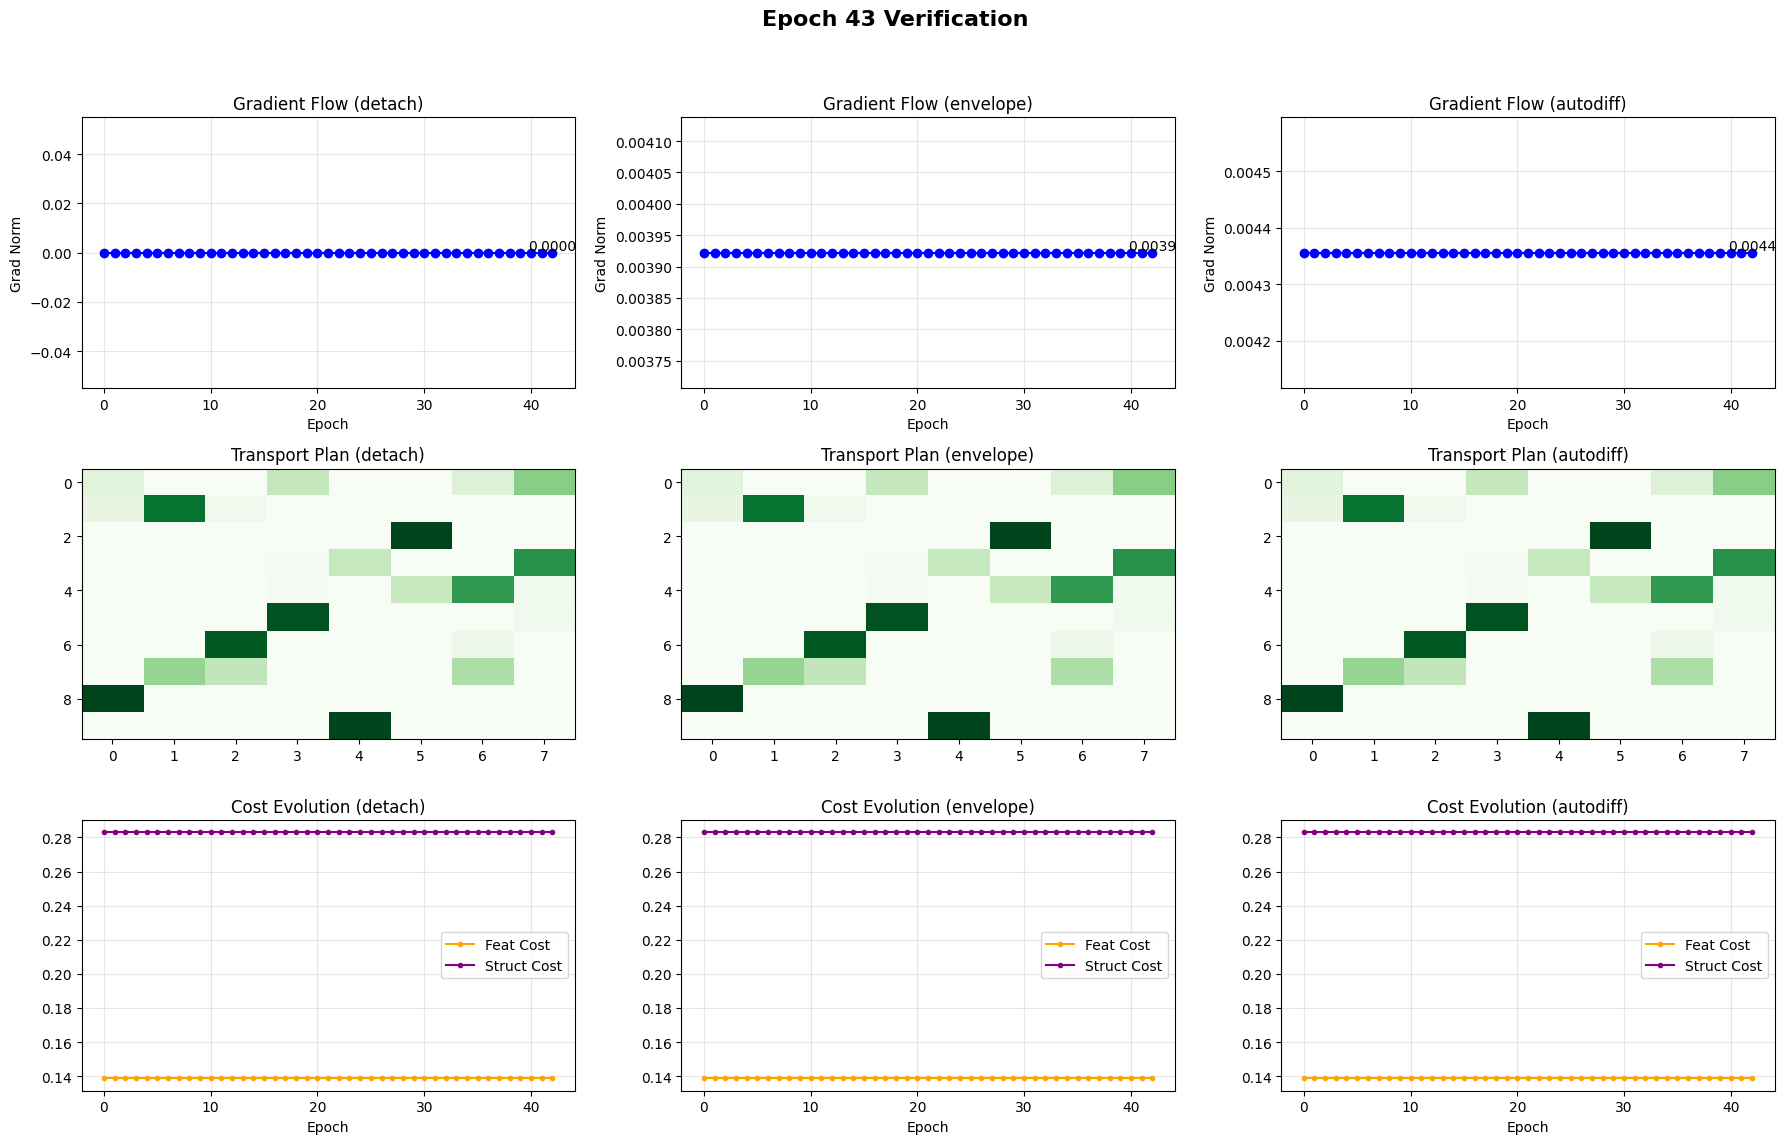

Epoch 43 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


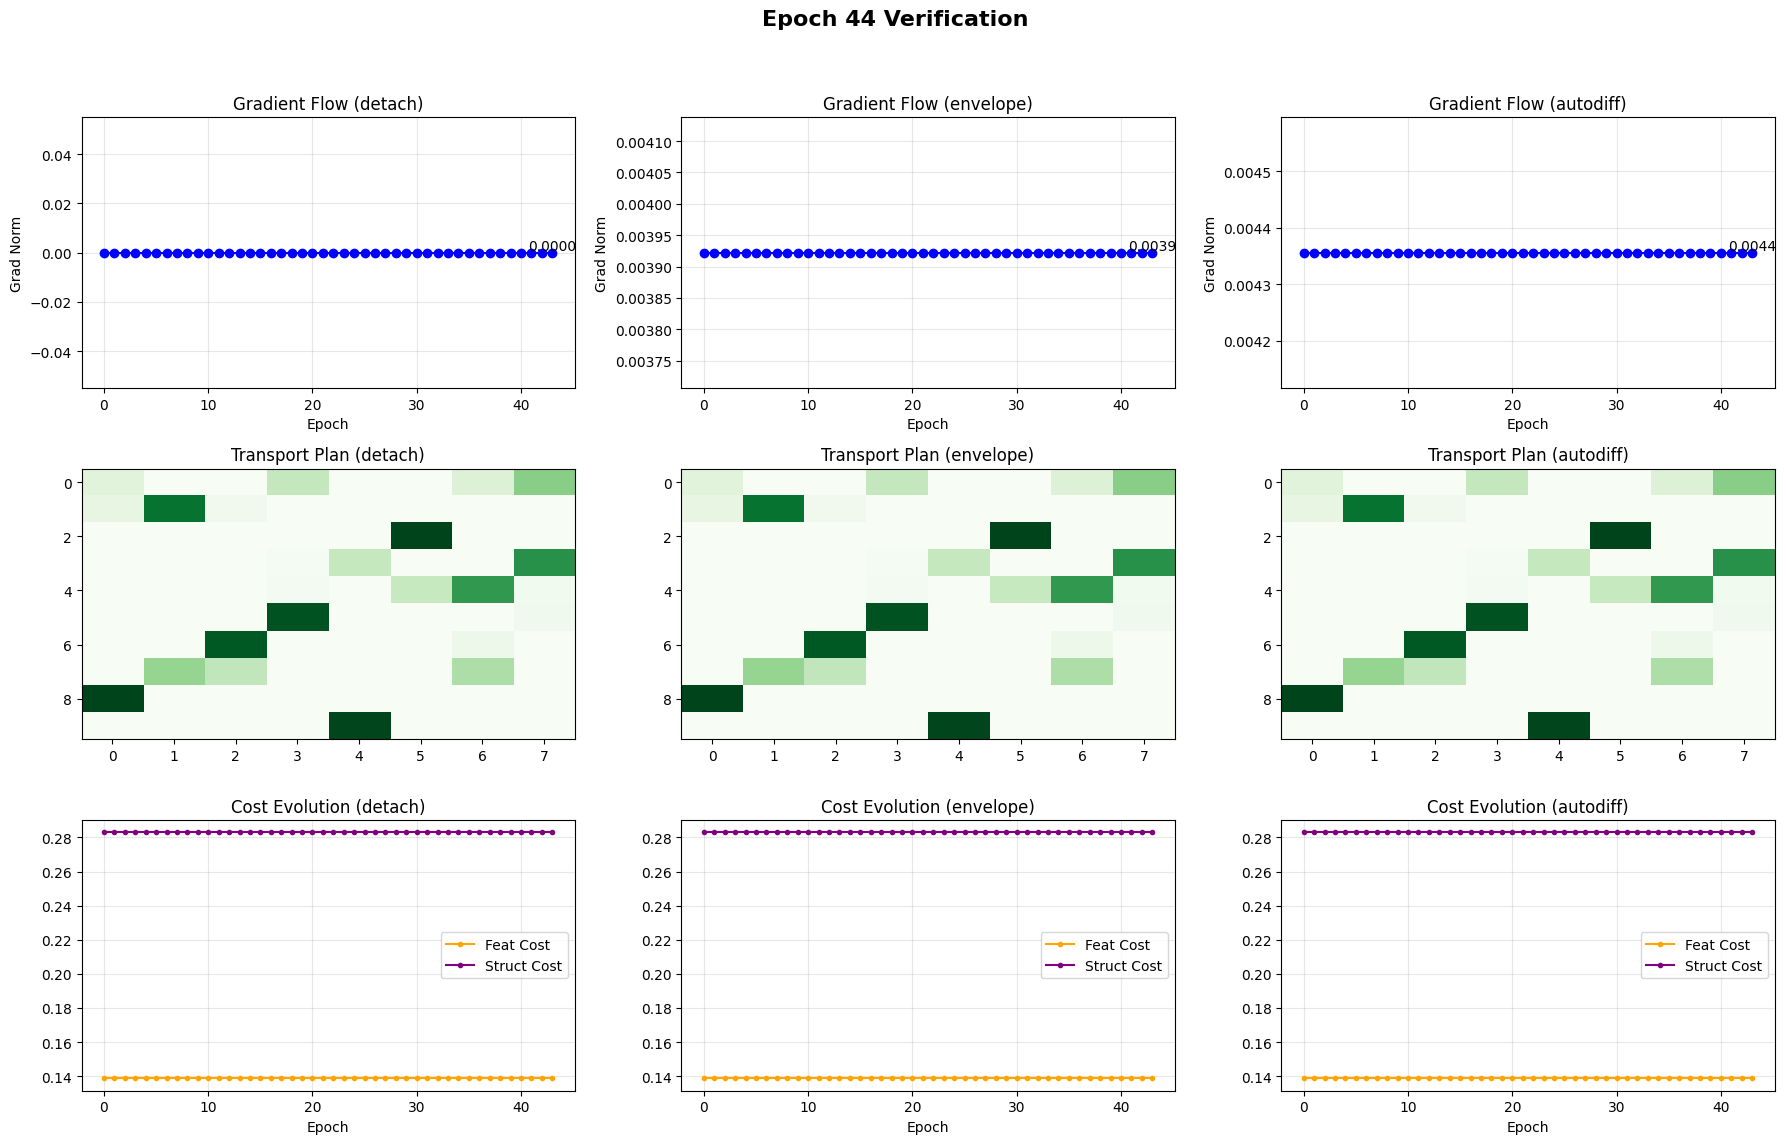

Epoch 44 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


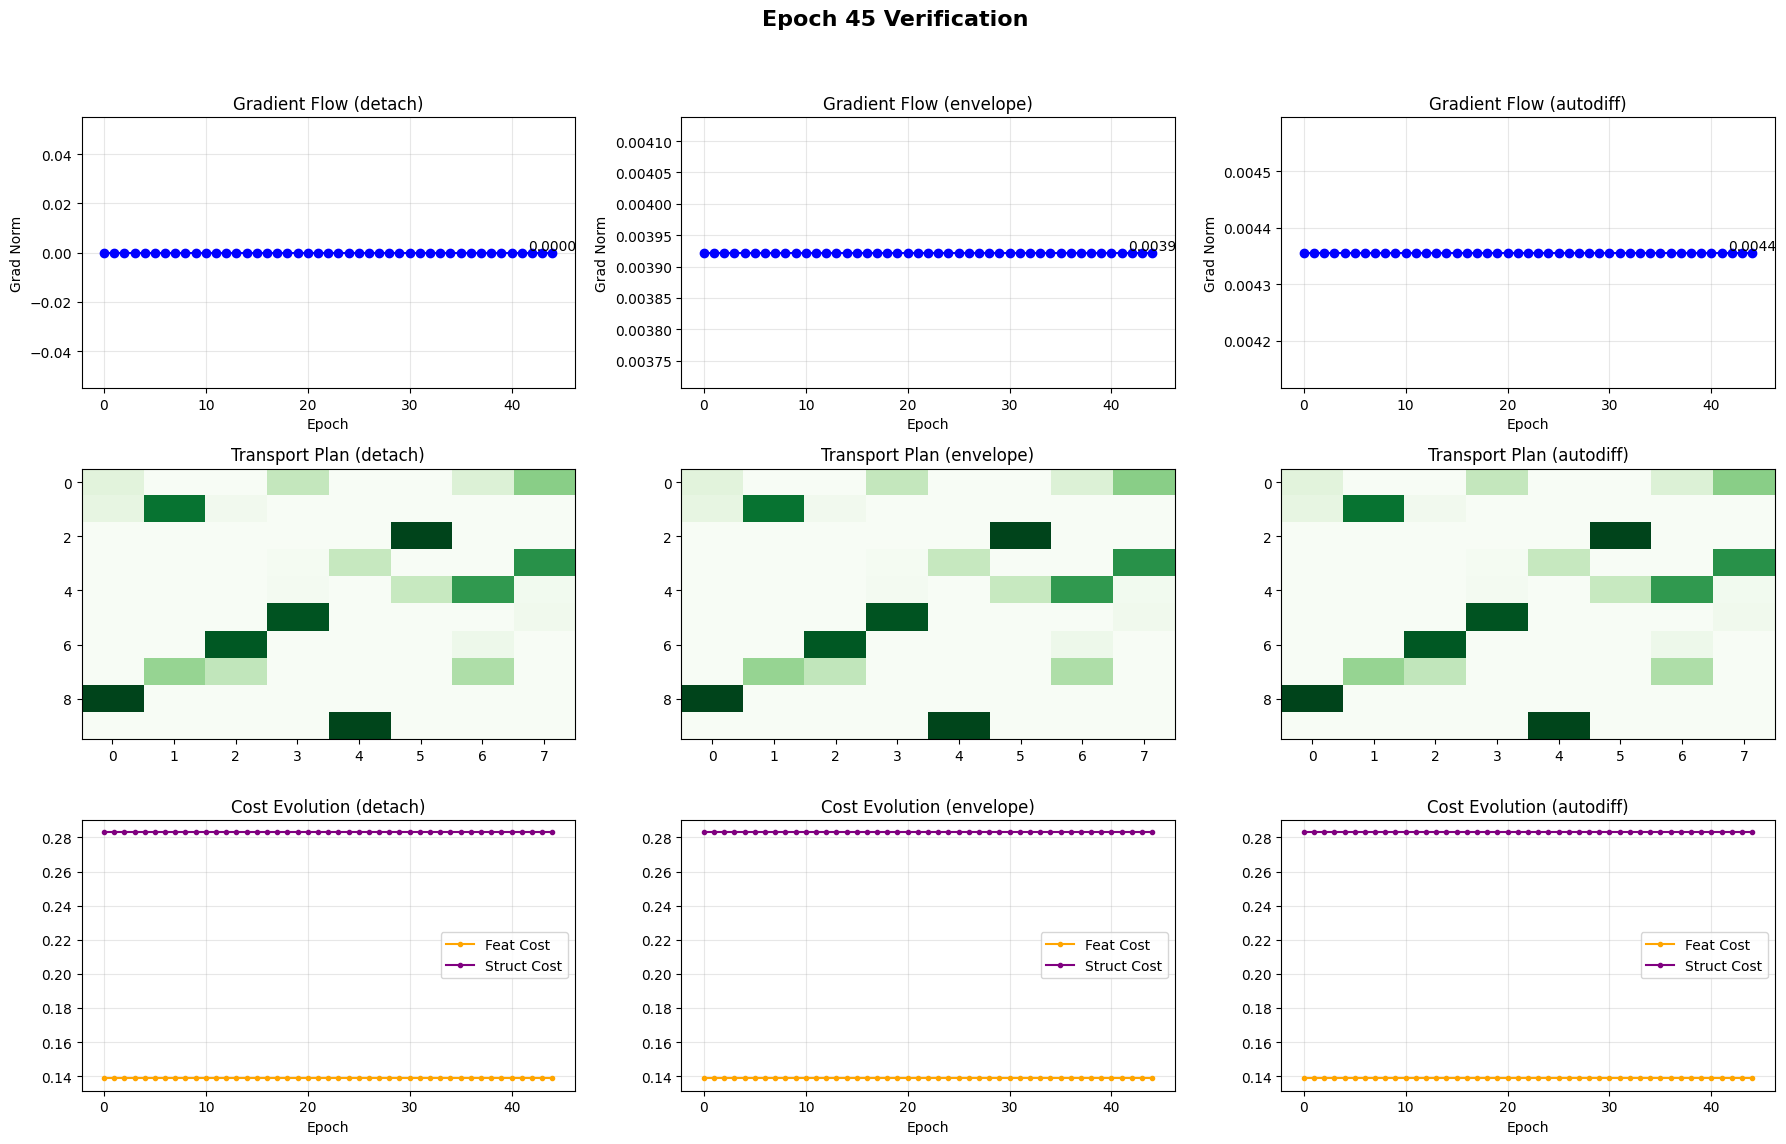

Epoch 45 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


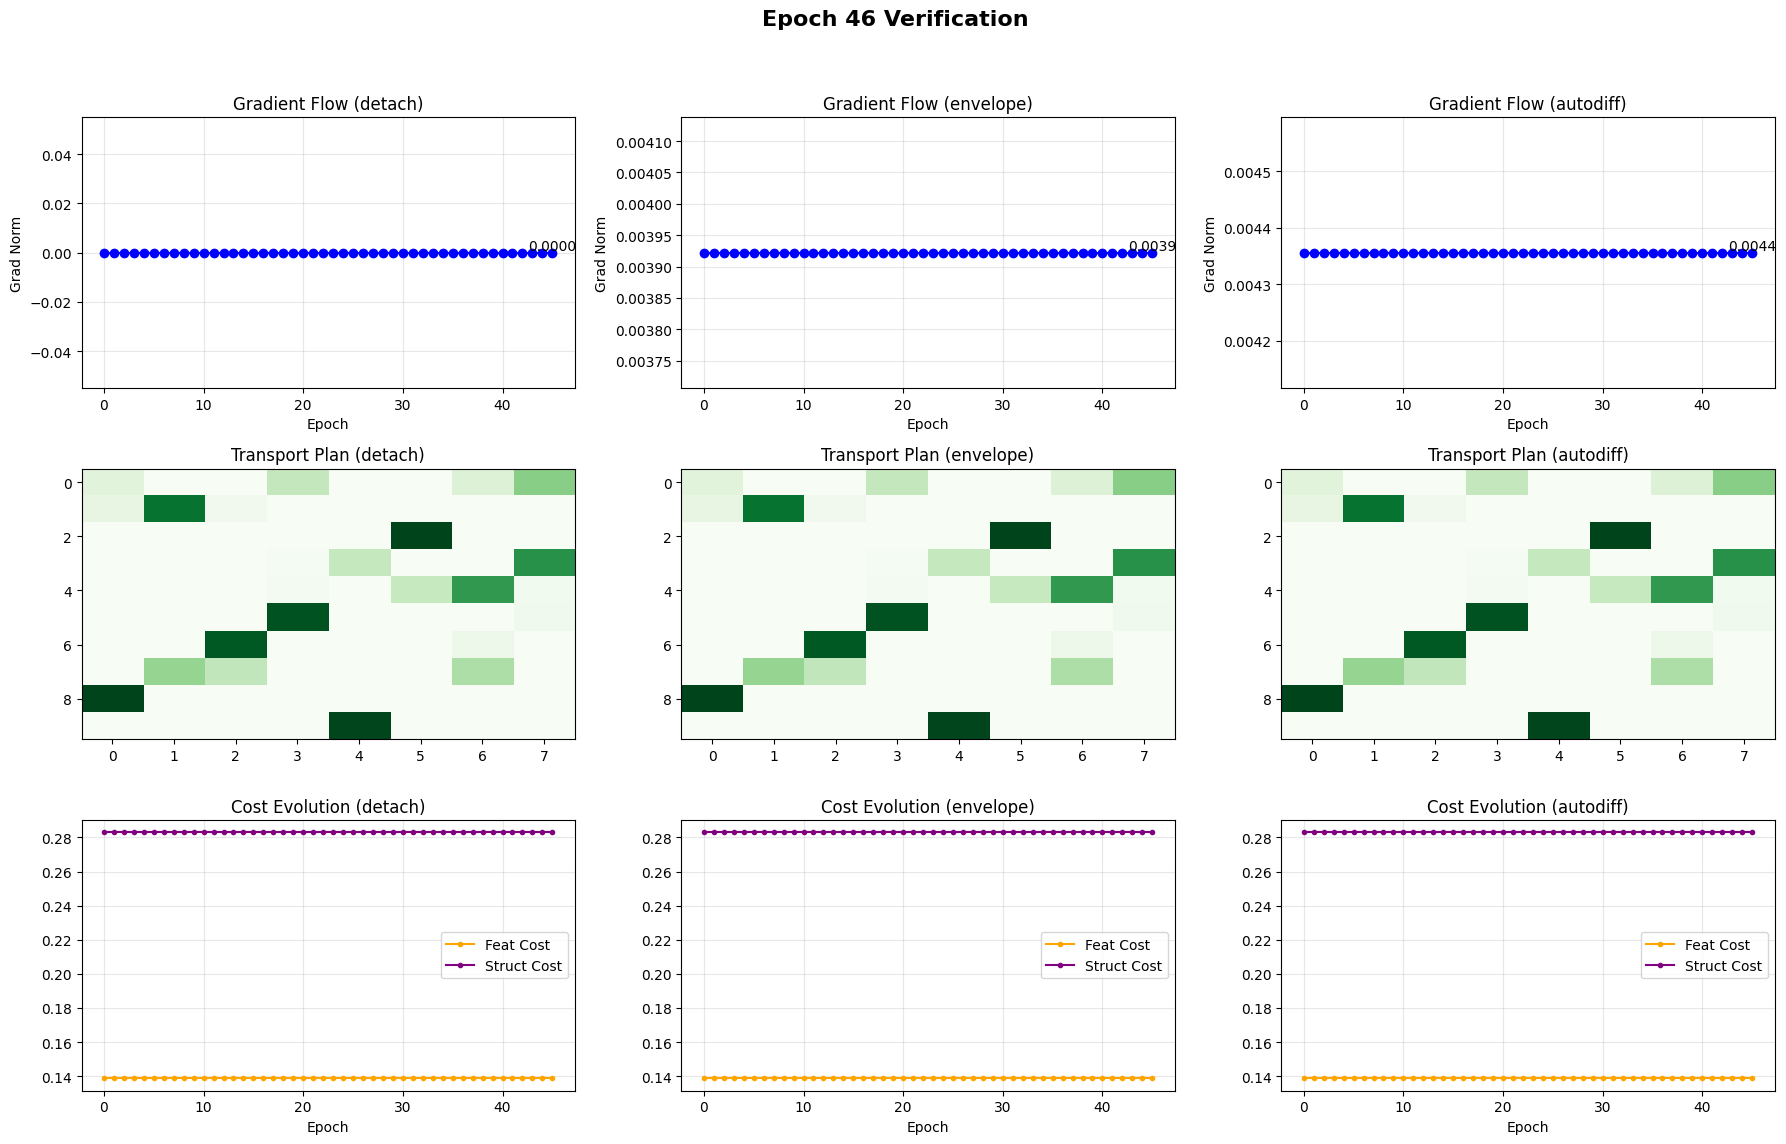

Epoch 46 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


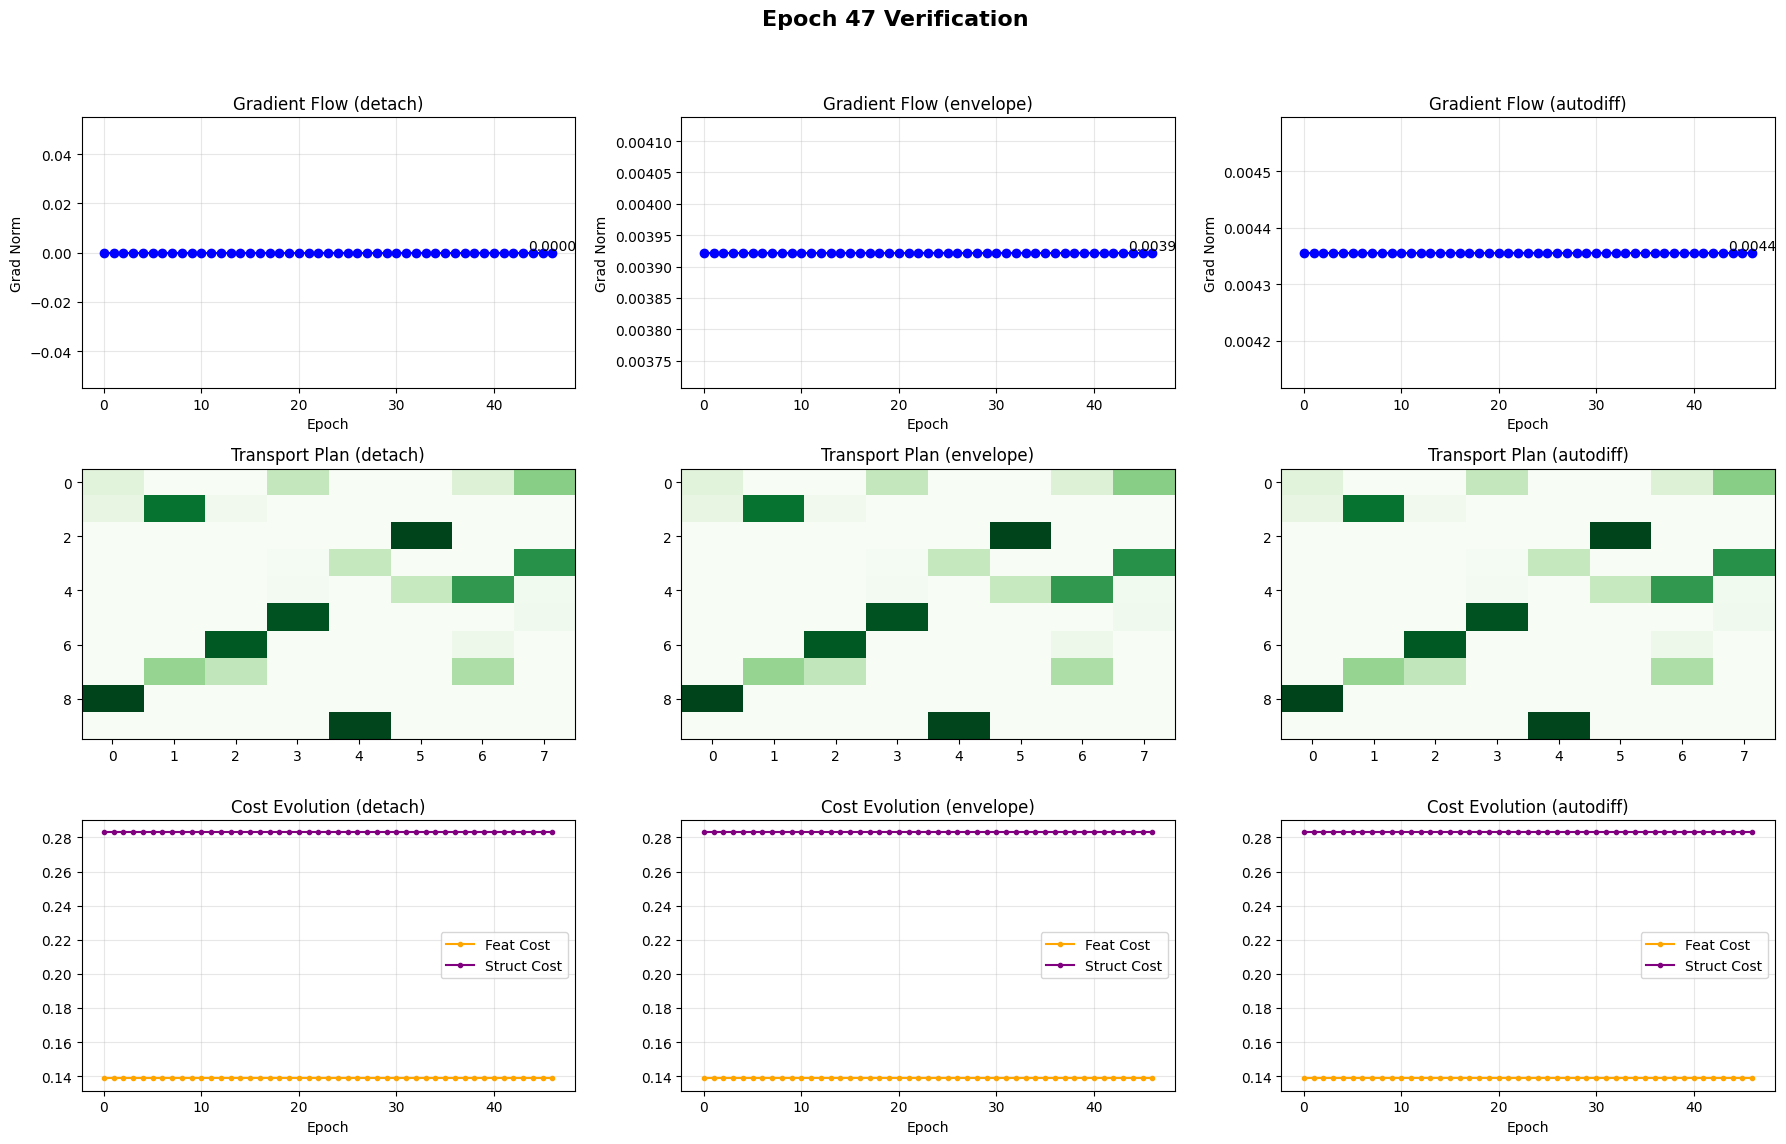

Epoch 47 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


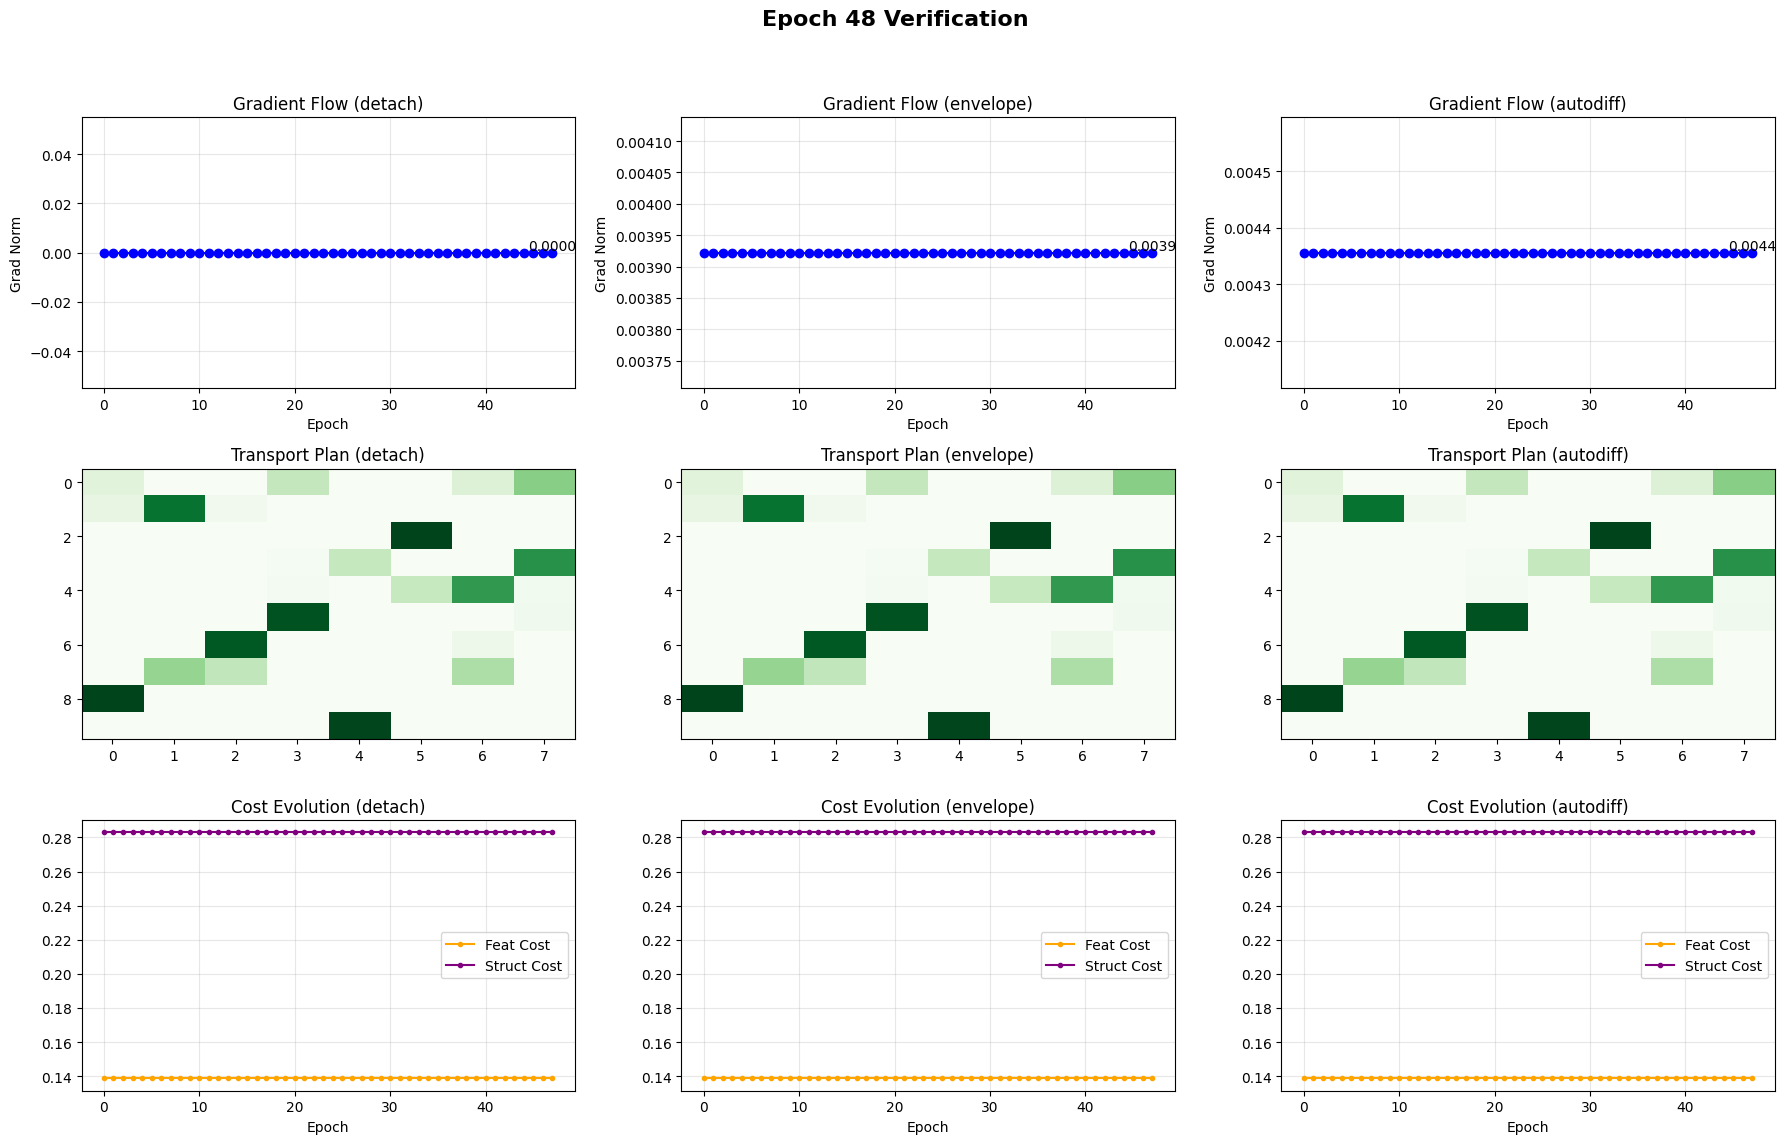

Epoch 48 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


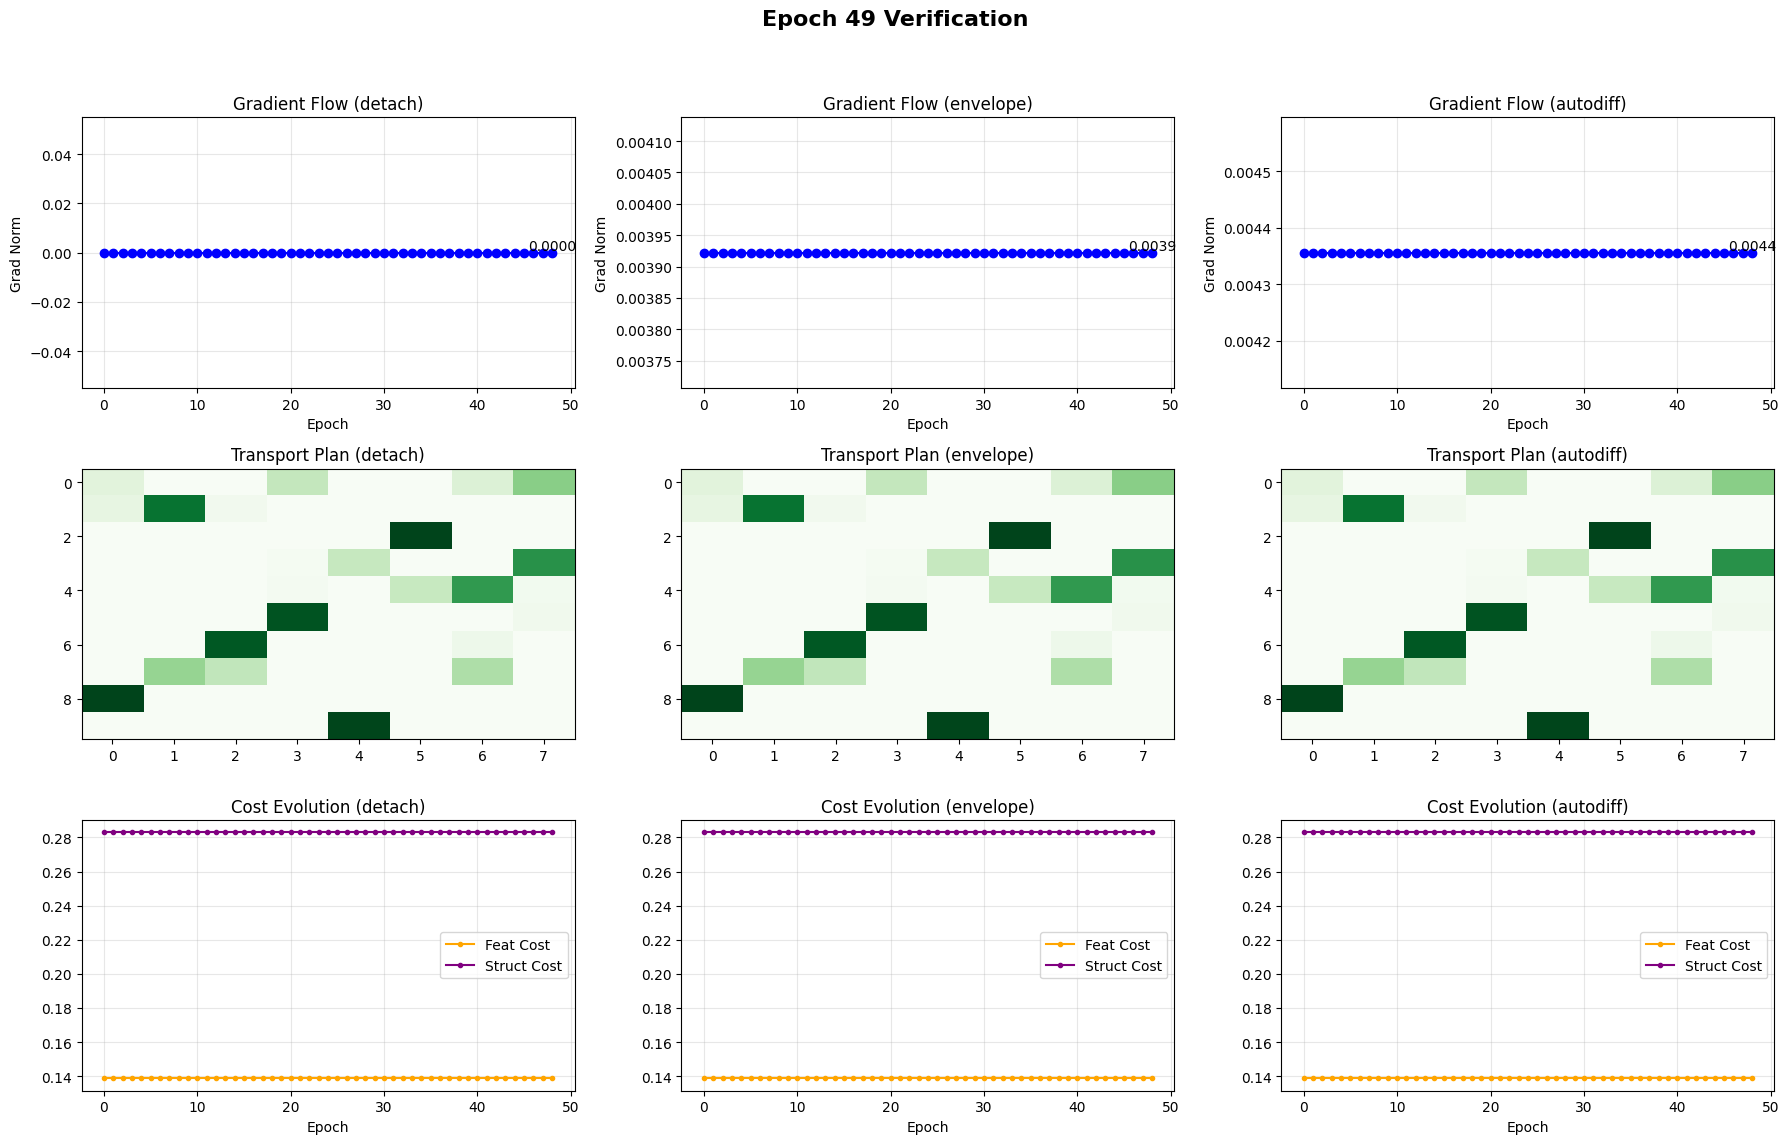

Epoch 49 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------
[detach] Backward Error: element 0 of tensors does not require grad and does not have a grad_fn


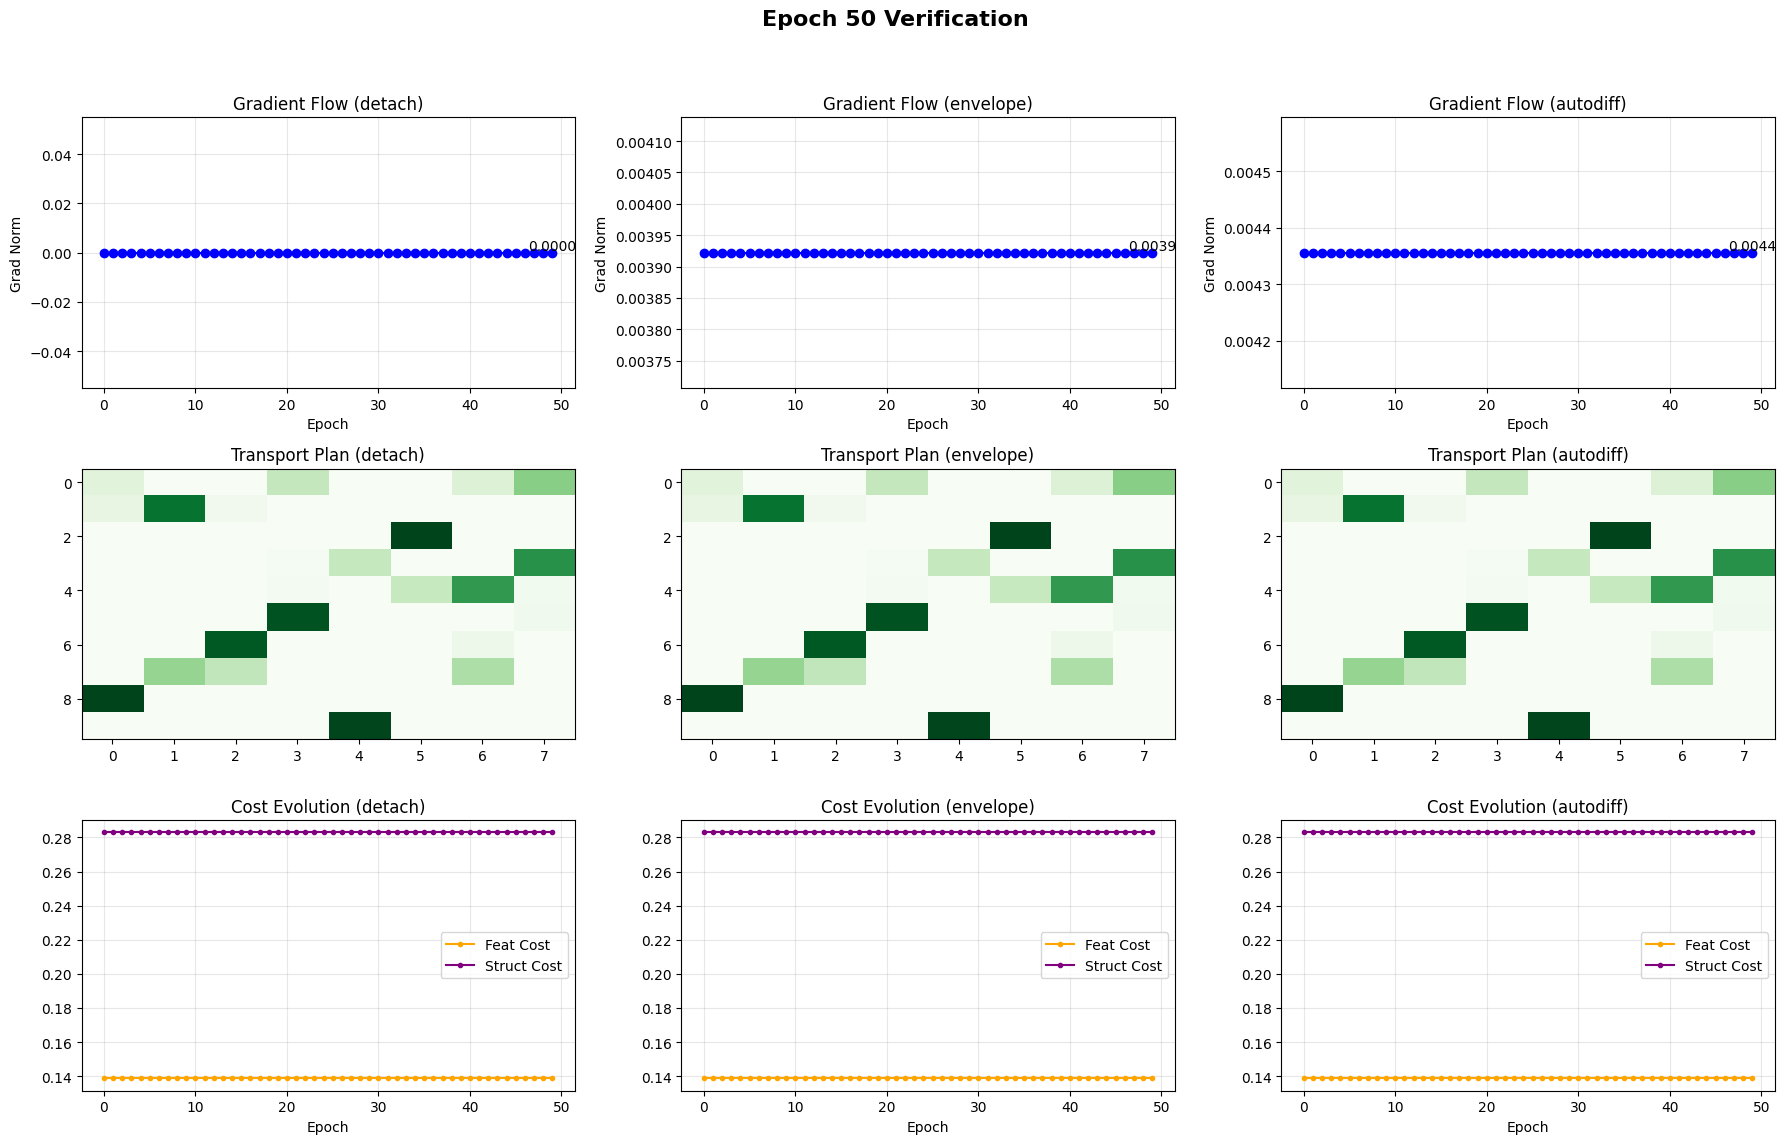

Epoch 50 Summary:
  > Detach Grad: 0.000000
  > Envelope Grad: 0.003922
  > Autodiff Grad: 0.004356
--------------------------------------------------


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import ot
from ot.batch import solve_gromov_batch

# ==========================================
# 1. Helper Function: FGW Calculation
# ==========================================
def run_fgw_check(src_feat, src_str, lcg_feat, lcg_str, grad_mode, alpha=0.5, reg=0.01):
    """
    사용자님의 로직을 그대로 가져와서 검증용으로 포장한 함수
    """
    B, N, D = src_feat.shape
    M, K, _ = lcg_feat.shape
    
    # 1. Expand (User's Logic)
    # Source: [B, N, D] -> [B*M, N, D]
    src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
    src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    
    # LCG: [M, K, D] -> [B*M, K, D]
    lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
    lcg_str_exp = lcg_str.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # 2. Weights (Batch Dimension Matching)
    a = torch.ones(B*M, N, device=src_feat.device) / N
    b = torch.ones(B*M, K, device=src_feat.device) / K
    
    # 3. Cost Matrix
    tau = 10.0
    dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp) ** 2
    M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
    
    # 4. Solve OT
    # grad_mode: 'detach' | 'envelope' | 'autodiff'
    result = solve_gromov_batch(
        src_str_exp, lcg_str_exp, 
        M=M_cost, 
        reg=reg, alpha=alpha, 
        a=a, b=b, 
        loss='sqeuclidean', 
        grad=grad_mode 
    )
    
    # 5. Result Parsing
    if isinstance(result, torch.Tensor):
        # detach 모드: 텐서만 반환됨
        loss_val = result.mean()
        plan = None # detach 모드는 Plan을 제공하지 않음
    else:
        # envelope/autodiff 모드: 객체 반환
        loss_val = result.value.mean()
        if hasattr(result, 'plan') and result.plan is not None:
            # 첫 번째 배치의 첫 번째 LCG에 대한 Plan 추출 [N, K]
            plan = result.plan[0].detach() 
        else:
            plan = None
            
    # 6. Decompose Costs (for Visualization)
    # Feature Cost = <M_cost, T>
    # Struct Cost = Total - (1-alpha)*Feat
    feat_cost_val = 0.0
    struct_cost_val = 0.0
    
    if plan is not None:
        # 정확한 계산을 위해 해당 샘플의 M_cost 가져오기
        m_sample = M_cost[0].detach()
        t_sample = plan
        
        fc = (m_sample * t_sample).sum().item()
        total = result.value[0].item()
        
        feat_cost_val = fc
        # FGW Loss = (1-alpha)*Feat + alpha*Struct
        # Struct = (Total - (1-alpha)*Feat) / alpha
        struct_cost_val = (total - (1-alpha)*fc) / (alpha + 1e-9)
    else:
        # Plan이 없으면 M_cost의 평균으로 대략적 스케일만 확인
        feat_cost_val = M_cost.mean().item()
        struct_cost_val = 0.0
        
    return loss_val, plan, feat_cost_val, struct_cost_val


# ==========================================
# 2. Data Preparation (Fixed Input)
# ==========================================
# (이전 단계의 src_feat, src_str, centroids가 있다고 가정)
# 없다면 랜덤으로 생성
if 'centroids' not in locals():
    print("Initialize Random Data...")
    M, K, D = 4, 8, 16
    N = 10
    B = 2
    centroids = np.random.randn(M, K, D)
    # Source Dummy
    src_feat_fixed = torch.randn(B, N, D, device=device)
    src_str_fixed = torch.rand(B, N, N, device=device)
else:
    # 기존 데이터 활용
    M, K, D = centroids.shape
    B, N, _ = src_feat.shape # 위 코드에서 정의된 변수 사용
    # Gradient Flow 확인을 위해 매번 새로 만들 것이므로 여기선 형상만 참조

# LCG Parameters (Trainable)
lcg_feat_param = nn.Parameter(torch.tensor(centroids, dtype=torch.float32, device=device))
lcg_str_param = nn.Parameter(torch.tensor(1.0 - np.eye(K)[None,:,:].repeat(M,0), dtype=torch.float32, device=device))


# ==========================================
# 3. Main Verification Loop
# ==========================================
modes = ['detach', 'envelope', 'autodiff']
num_epochs = 50 # 시각화를 위해 짧게 설정

# History Storage
history = {m: {'grad': [], 'feat_cost': [], 'struct_cost': []} for m in modes}

print(f"\n{'='*10} STARTING FGW VERIFICATION (Epoch-wise Viz) {'='*10}")

for epoch in range(1, num_epochs + 1):
    
    # 시각화를 위한 Figure 생성 (Epoch 마다 생성)
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    plt.suptitle(f"Epoch {epoch} Verification", fontsize=16, fontweight='bold')
    
    # Columns: Modes [Detach, Envelope, Autodiff]
    # Rows: [Gradient, Plan, Costs]
    
    for idx, mode in enumerate(modes):
        # ----------------------------------------
        # A. Forward & Backward
        # ----------------------------------------
        
        # 1. Input Source (Gradient Start Point)
        # 매번 같은 데이터를 사용하되, Gradient Graph는 새로 생성
        if 'src_feat' in locals():
             x_curr = src_feat.detach().clone().requires_grad_(True) # 기존 GAT Output 활용
        else:
             x_curr = src_feat_fixed.detach().clone().requires_grad_(True)
             
        # Source Struct (Affinity)
        if 'src_str' in locals():
            s_curr = src_str.detach().clone()
        else:
            s_curr = src_str_fixed.detach().clone()
        
        # 2. Compute FGW
        loss, plan, fc, sc = run_fgw_check(
            x_curr, s_curr, lcg_feat_param, lcg_str_param, 
            grad_mode=mode, alpha=0.5
        )
        
        # 3. Backward
        if x_curr.grad is not None: x_curr.grad.zero_()
        
        grad_norm = 0.0
        try:
            loss.backward()
            if x_curr.grad is not None:
                grad_norm = x_curr.grad.norm().item()
        except RuntimeError as e:
            print(f"[{mode}] Backward Error: {e}")
            
        # 4. Save Stats
        history[mode]['grad'].append(grad_norm)
        history[mode]['feat_cost'].append(fc)
        history[mode]['struct_cost'].append(sc)
        
        # ----------------------------------------
        # B. Visualization (Subplots)
        # ----------------------------------------
        col = idx
        
        # Row 1: Gradient Flow (History Line Plot)
        ax_grad = axes[0, col]
        ax_grad.plot(history[mode]['grad'], marker='o', color='blue')
        ax_grad.set_title(f"Gradient Flow ({mode})")
        ax_grad.set_xlabel("Epoch")
        ax_grad.set_ylabel("Grad Norm")
        ax_grad.grid(True, alpha=0.3)
        # 현재 값 표시
        ax_grad.text(epoch-1, grad_norm, f"{grad_norm:.4f}", ha='center', va='bottom')
        
        # Row 2: Optimal Plan T (Heatmap)
        ax_plan = axes[1, col]
        if plan is not None:
            im = ax_plan.imshow(plan.cpu().numpy(), cmap='Greens', aspect='auto')
            ax_plan.set_title(f"Transport Plan ({mode})")
            # plt.colorbar(im, ax=ax_plan) # 공간 부족 시 생략 가능
        else:
            ax_plan.text(0.5, 0.5, "No Plan Available\n(Detach Mode)", ha='center', va='center')
            ax_plan.set_title(f"Transport Plan ({mode})")
            ax_plan.axis('off')

        # Row 3: Feature vs Struct Cost (Line Plot)
        ax_cost = axes[2, col]
        ax_cost.plot(history[mode]['feat_cost'], label='Feat Cost', color='orange', marker='.')
        ax_cost.plot(history[mode]['struct_cost'], label='Struct Cost', color='purple', marker='.')
        ax_cost.set_title(f"Cost Evolution ({mode})")
        ax_cost.set_xlabel("Epoch")
        ax_cost.legend()
        ax_cost.grid(True, alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Title 공간 확보
    plt.show()
    
    # ----------------------------------------------------
    # 간단한 로그 출력
    print(f"Epoch {epoch} Summary:")
    print(f"  > Detach Grad: {history['detach']['grad'][-1]:.6f}")
    print(f"  > Envelope Grad: {history['envelope']['grad'][-1]:.6f}")
    print(f"  > Autodiff Grad: {history['autodiff']['grad'][-1]:.6f}")
    print("-" * 50)